# MindReader Clinical Trial Study & Pipeline Comparison Prototype

This notebook demonstrates how MindReader can convert raw clinical trial registry data into structured, normalized, weighted, and explainable study/pipeline comparisons.

The goal is not to build a chatbot yet. The goal is to prove that we can compare clinical studies and pipelines on clinically meaningful dimensions such as efficacy, safety, tolerability, patient convenience, endpoint quality, cost/access, regulatory maturity, and pipeline strength.

This notebook is designed for approval. After approval, the method can be converted into a repeatable product pipeline.


## Why This Matters

Clinical trial records are difficult to compare manually because each study may have different endpoints, populations, phases, sponsors, results availability, safety signals, and design choices.

MindReader’s value is to convert these scattered fields into structured intelligence:
- What looks clinically meaningful?
- What looks safe or risky?
- Which therapy is easier for patients?
- Which pipeline looks more mature?
- Which studies have stronger evidence?
- Where is data missing?


# Final Notebook Direction

This notebook is not trying to predict clinical success.

It is building an explainable clinical-trial intelligence method that compares studies based on available structured evidence.

The method separates:

1. Clinical & Pipeline Significance Score  
   A normalized weighted comparison score.

2. Data Confidence Score  
   A measure of how complete the available evidence is.

3. AI Trial Intelligence Card  
   A source-grounded explanation of strengths, risks, missing evidence, and what users should not conclude.

This keeps the system transparent and avoids overclaiming.


In [1]:
import os
import glob
import json
import math
import urllib.request
import urllib.parse
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, RobustScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')


In [2]:
def find_clinical_trials_csv():
    preferred = 'clinical_trials(1).csv'
    if os.path.exists(preferred):
        return preferred

    candidates = glob.glob('*clinical_trials*.csv')
    if not candidates:
        raise FileNotFoundError('No clinical trial CSV found in current directory.')
    return candidates[0]

csv_path = find_clinical_trials_csv()
df = pd.read_csv(csv_path)

print('Loaded:', csv_path)
print('Shape:', df.shape)
display(df.head())
display(df.isna().sum().sort_values(ascending=False))


Loaded: clinical_trials.csv
Shape: (7000, 12)


,nct_id,brief_title,official_title,category,status,start_date,completion_date,sponsor,study_type,phase,enrollment,conditions
0,NCT04799925,Hyperuricemia and Diabetic Nephropathy,Effect of Treatment of Hyperuricemia on Progression of Diabetic Nephropathy in Patients With Type II Diabetes Mellitus and Stage III Chronic Kidney Disease.,Autoimmune,UNKNOWN,2021-04-15,2022-12-30,Assiut University,OBSERVATIONAL,NaN,200,"Hyperuricemia, Diabetic Nephropathies"
1,NCT05132725,Carbohydrate Counting and DASH Intervention Among Children With Diabetes and Celiac Disease.,Studying the Effect of Gluten Free Diet Alone Versus Combination of Gluten Free Diet With Either Carbohydrate Count or Dietary Approach to Reduce Hypertensi...,Autoimmune,UNKNOWN,2021-11-15,2022-11-11,University of Jordan,INTERVENTIONAL,NaN,45,"Diabetes Mellitus, Type 1, Celiac Disease in Children"
2,NCT05945576,IDMet (RaDiCo Cohort) (RaDiCo-IDMet),National Cohort on Imprinting Disorders and Their Metabolic Consequences,Autoimmune,RECRUITING,2017-03-10,2028-03,"Institut National de la Santé Et de la Recherche Médicale, France",OBSERVATIONAL,NaN,2000,"Silver Russell Syndrome, Beckwith-Wiedemann Syndrome, Transient Neonatal Diabetes Mellitus, Angelman Syndrome, Prader-Willi Syndrome, Temple Syndrome, Kagam..."
3,NCT06530940,Diagnostic Interest of the Buccal Schirmer Test in Xerostomia During Sjögren's Syndrome: XERODIAG,Diagnostic Interest of the Buccal Schirmer Test in Xerostomia During Sjögren's Syndrome: XERODIAG,Autoimmune,NOT_YET_RECRUITING,2024-08-19,2024-12-31,University Tunis El Manar,OBSERVATIONAL,NaN,180,"Sjogren's Syndrome, Xerostomia, Diagnosis"
4,NCT03715140,Crucumin Effects on the Immune System in Osteoarthritis Patients,Evaluation of the Crucumin Effects on the Cellular and Humoral Immune Systems in Osteoarthritis Patients; a Randomised Double Blind Placebo Control Clinical...,Autoimmune,UNKNOWN,2019-05-01,2020-12-30,Mashhad University of Medical Sciences,INTERVENTIONAL,PHASE3,30,Osteoarthritis


phase              3623
completion_date     229
official_title       91
start_date           40
nct_id                0
brief_title           0
category              0
status                0
sponsor               0
study_type            0
enrollment            0
conditions            0
dtype: int64

## Dataset Understanding

The broad dataset is useful for pipeline-level analysis. It contains trial identifiers, category, sponsor, phase, status, enrollment, dates, and conditions.

However, broad CSV fields are not enough for deep study comparison. To compare studies properly, we need detailed records from ClinicalTrials.gov API v2 using each NCT ID.

### Key Fields Description:
* `nct_id`: The unique identifier for the clinical trial (e.g. NCT04799925).
* `brief_title`: The short title of the study.
* `official_title`: The detailed official title of the study.
* `category`: The therapeutic area category (e.g. Oncology, Autoimmune).
* `status`: The current status of the trial (e.g. Completed, Recruiting).
* `start_date`: The official start date of the study.
* `completion_date`: The completion date of the study.
* `sponsor`: The lead organization sponsor.
* `study_type`: The nature of the study design (e.g. Interventional, Observational).
* `phase`: The phase of development (e.g. Phase 1, Phase 2, Phase 3, Phase 4).
* `enrollment`: The planned or actual sample size.
* `conditions`: The clinical conditions or diseases studied.


In [3]:
def fetch_in_depth_trial_data(nct_id, timeout=20):
    url = f'https://clinicaltrials.gov/api/v2/studies/{nct_id}'
    req = urllib.request.Request(
        url,
        headers={'User-Agent': 'MindReader-Clinical-Trial-Prototype/1.0'}
    )

    try:
        with urllib.request.urlopen(req, timeout=timeout) as response:
            return json.loads(response.read().decode('utf-8'))
    except Exception as e:
        print(f'Error fetching {nct_id}: {e}')
        return None


This API call gives us the full study record for one NCT ID, including protocol details, outcomes, design information, eligibility, sponsor details, locations, publications, and results availability where available.


In [4]:
def safe_get(d, path, default=None):
    current = d
    for key in path:
        if not isinstance(current, dict):
            return default
        current = current.get(key)
        if current is None:
            return default
    return current

def list_to_text(values, limit=None):
    if not values:
        return 'Not available in source data'
    if limit:
        values = values[:limit]
    return '; '.join([str(v) for v in values if v])

def normalize_text(value):
    if value is None:
        return ''
    return str(value).strip().lower()


In [5]:
def parse_results_section(study_data):
    results = study_data.get("resultsSection", {}) if study_data else {}

    if not results:
        return {
            "results_section_available": False,
            "participant_flow_available": False,
            "baseline_available": False,
            "outcome_results_available": False,
            "adverse_events_available": False,
            "primary_outcome_result_count": 0,
            "secondary_outcome_result_count": 0,
            "statistical_analysis_count": 0,
            "serious_adverse_event_count": None,
            "other_adverse_event_count": None,
            "death_event_count": None,
            "withdrawal_count": None,
            "result_groups": [],
            "outcome_result_summaries": [],
            "adverse_event_summaries": []
        }

    participant_flow = results.get("participantFlowModule", {})
    baseline = results.get("baselineCharacteristicsModule", {})
    outcome_measures = results.get("outcomeMeasuresModule", {})
    adverse_events = results.get("adverseEventsModule", {})

    result_groups = []
    for group in outcome_measures.get("groups", []):
        result_groups.append({
            "id": group.get("id"),
            "title": group.get("title"),
            "description": group.get("description")
        })

    outcome_result_summaries = []
    primary_count = 0
    secondary_count = 0
    statistical_analysis_count = 0

    for outcome in outcome_measures.get("outcomeMeasures", []):
        measure_title = outcome.get("title", "")
        measure_type = outcome.get("type", "")
        description = outcome.get("description", "")
        time_frame = outcome.get("timeFrame", "")

        if str(measure_type).lower() == "primary":
            primary_count += 1
        elif str(measure_type).lower() == "secondary":
            secondary_count += 1

        analyses = outcome.get("analyses", []) or []
        statistical_analysis_count += len(analyses)

        classes = outcome.get("classes", []) or []

        outcome_result_summaries.append({
            "title": measure_title,
            "type": measure_type,
            "description": description,
            "time_frame": time_frame,
            "unit_of_measure": outcome.get("unitOfMeasure", ""),
            "param_type": outcome.get("paramType", ""),
            "dispersion_type": outcome.get("dispersionType", ""),
            "analysis_count": len(analyses),
            "class_count": len(classes)
        })

    serious_count = None
    other_count = None
    death_count = None
    adverse_event_summaries = []

    if adverse_events:
        serious_events = adverse_events.get("seriousEvents", []) or []
        other_events = adverse_events.get("otherEvents", []) or []

        serious_count = len(serious_events)
        other_count = len(other_events)

        death_count = 0

        for event in serious_events:
            term = str(event.get("term", "")).lower()
            if "death" in term or "fatal" in term:
                death_count += 1

            adverse_event_summaries.append({
                "event_type": "serious",
                "term": event.get("term", ""),
                "organ_system": event.get("organSystem", ""),
                "source_vocabulary": event.get("sourceVocabulary", "")
            })

        for event in other_events[:50]:
            adverse_event_summaries.append({
                "event_type": "other",
                "term": event.get("term", ""),
                "organ_system": event.get("organSystem", ""),
                "source_vocabulary": event.get("sourceVocabulary", "")
            })

    return {
        "results_section_available": bool(results),
        "participant_flow_available": bool(participant_flow),
        "baseline_available": bool(baseline),
        "outcome_results_available": bool(outcome_measures),
        "adverse_events_available": bool(adverse_events),
        "primary_outcome_result_count": primary_count,
        "secondary_outcome_result_count": secondary_count,
        "statistical_analysis_count": statistical_analysis_count,
        "serious_adverse_event_count": serious_count,
        "other_adverse_event_count": other_count,
        "death_event_count": death_count,
        "withdrawal_count": None,
        "result_groups": result_groups,
        "outcome_result_summaries": outcome_result_summaries,
        "adverse_event_summaries": adverse_event_summaries
    }

def extract_safety_tolerability_flags(parsed_study):
    has_results = bool(parsed_study.get("has_results"))
    adverse_events_available = bool(parsed_study.get("adverse_events_available"))
    serious_count = parsed_study.get("serious_adverse_event_count")
    other_count = parsed_study.get("other_adverse_event_count")
    death_count = parsed_study.get("death_event_count")

    primary_secondary_text = " ".join([
        str(x.get("measure", "")) + " " + str(x.get("description", ""))
        for x in parsed_study.get("primary_outcomes", []) + parsed_study.get("secondary_outcomes", [])
    ]).lower()

    safety_endpoint_signal = any(term in primary_secondary_text for term in [
        "adverse event",
        "serious adverse",
        "safety",
        "toxicity",
        "tolerability",
        "dose limiting",
        "discontinuation",
        "withdrawal"
    ])

    qol_signal = any(term in primary_secondary_text for term in [
        "quality of life",
        "qol",
        "patient reported",
        "pain",
        "fatigue",
        "symptom",
        "function"
    ])

    return {
        "safety_endpoint_signal": int(safety_endpoint_signal),
        "qol_endpoint_signal": int(qol_signal),
        "actual_adverse_event_data_available": int(adverse_events_available),
        "actual_serious_ae_data_available": int(serious_count is not None),
        "actual_death_data_available": int(death_count is not None),
        "safety_interpretability": (
            "direct" if adverse_events_available else
            "endpoint-only" if safety_endpoint_signal else
            "not available"
        )
    }

def parse_trial_details(study_data):
    if not study_data:
        return {}

    protocol = study_data.get('protocolSection', {})
    results_section = study_data.get('resultsSection', {})

    id_module = protocol.get('identificationModule', {})
    status_module = protocol.get('statusModule', {})
    sponsor_module = protocol.get('sponsorCollaboratorsModule', {})
    design_module = protocol.get('designModule', {})
    conditions_module = protocol.get('conditionsModule', {})
    arms_module = protocol.get('armsInterventionsModule', {})
    outcomes_module = protocol.get('outcomesModule', {})
    eligibility_module = protocol.get('eligibilityModule', {})
    contacts_locations_module = protocol.get('contactsLocationsModule', {})
    more_info_module = protocol.get('moreInfoModule', {})

    nct_id = id_module.get('nctId', '')
    brief_title = id_module.get('briefTitle', '')
    official_title = id_module.get('officialTitle', '')

    status = status_module.get('overallStatus', '')
    start_date = safe_get(status_module, ['startDateStruct', 'date'], '')
    primary_completion_date = safe_get(status_module, ['primaryCompletionDateStruct', 'date'], '')
    completion_date = safe_get(status_module, ['completionDateStruct', 'date'], '')

    lead_sponsor = safe_get(sponsor_module, ['leadSponsor', 'name'], '')
    sponsor_class = safe_get(sponsor_module, ['leadSponsor', 'class'], '')
    collaborators = [
        c.get('name', '') for c in sponsor_module.get('collaborators', [])
    ]

    study_type = design_module.get('studyType', '')
    phases = design_module.get('phases', [])
    phase = phases[0] if phases else 'NA'
    enrollment_count = safe_get(design_module, ['enrollmentInfo', 'count'], np.nan)
    enrollment_type = safe_get(design_module, ['enrollmentInfo', 'type'], '')

    design_info = design_module.get('designInfo', {})
    allocation = design_info.get('allocation', '')
    intervention_model = design_info.get('interventionModel', '')
    masking = design_info.get('maskingInfo', {}).get('masking', '')
    primary_purpose = design_info.get('primaryPurpose', '')
    observational_model = design_info.get('observationalModel', '')
    time_perspective = design_info.get('timePerspective', '')

    conditions = conditions_module.get('conditions', [])
    keywords = conditions_module.get('keywords', [])

    interventions = arms_module.get('interventions', [])
    intervention_names = [i.get('name', '') for i in interventions]
    intervention_types = [i.get('type', '') for i in interventions]
    intervention_descriptions = [i.get('description', '') for i in interventions if i.get('description')]

    arm_groups = arms_module.get('armGroups', [])
    number_of_arms = len(arm_groups)

    primary_outcomes = []
    for item in outcomes_module.get('primaryOutcomes', []):
        primary_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'primary'
        })

    secondary_outcomes = []
    for item in outcomes_module.get('secondaryOutcomes', []):
        secondary_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'secondary'
        })

    other_outcomes = []
    for item in outcomes_module.get('otherOutcomes', []):
        other_outcomes.append({
            'measure': item.get('measure', ''),
            'description': item.get('description', ''),
            'time_frame': item.get('timeFrame', ''),
            'endpoint_type': 'other'
        })

    eligibility = eligibility_module.get('eligibilityCriteria', '')
    minimum_age = eligibility_module.get('minimumAge', '')
    maximum_age = eligibility_module.get('maximumAge', '')
    sex = eligibility_module.get('sex', '')
    healthy_volunteers = eligibility_module.get('healthyVolunteers', '')

    locations = contacts_locations_module.get('locations', [])
    countries = sorted(list(set([
        loc.get('country', '') for loc in locations if loc.get('country')
    ])))
    facility_count = len(locations)

    publications = []
    for pub in more_info_module.get('publications', []):
        publications.append({
            'pmid': pub.get('pmid', ''),
            'reference': pub.get('reference', '')
        })

    has_results = bool(study_data.get('hasResults', False) or results_section)

    parsed_study = {
        'nct_id': nct_id,
        'brief_title': brief_title,
        'official_title': official_title,
        'status': status,
        'start_date': start_date,
        'primary_completion_date': primary_completion_date,
        'completion_date': completion_date,
        'lead_sponsor': lead_sponsor,
        'sponsor_class': sponsor_class,
        'collaborators': collaborators,
        'study_type': study_type,
        'phase': phase,
        'enrollment_count': enrollment_count,
        'enrollment_type': enrollment_type,
        'conditions': conditions,
        'keywords': keywords,
        'intervention_names': intervention_names,
        'intervention_types': intervention_types,
        'intervention_descriptions': intervention_descriptions,
        'allocation': allocation,
        'intervention_model': intervention_model,
        'masking': masking,
        'primary_purpose': primary_purpose,
        'observational_model': observational_model,
        'time_perspective': time_perspective,
        'number_of_arms': number_of_arms,
        'primary_outcomes': primary_outcomes,
        'secondary_outcomes': secondary_outcomes,
        'other_outcomes': other_outcomes,
        'minimum_age': minimum_age,
        'maximum_age': maximum_age,
        'sex': sex,
        'healthy_volunteers': healthy_volunteers,
        'eligibility_criteria': eligibility,
        'countries': countries,
        'facility_count': facility_count,
        'publications': publications,
        'publication_count': len(publications),
        'has_results': has_results,
        'raw_results_available': bool(results_section),
    }

    results_parsed = parse_results_section(study_data)
    parsed_study.update(results_parsed)

    safety_flags = extract_safety_tolerability_flags(parsed_study)
    parsed_study.update(safety_flags)

    return parsed_study


In [6]:
def validate_study_identity(
    parsed_study,
    expected_condition=None,
    expected_intervention=None,
    expected_sponsor=None,
    expected_keywords=None
):
    warnings = []
    failed_checks = []

    if not parsed_study:
        return {
            'is_valid': False,
            'confidence': 'low',
            'warnings': ['Study could not be parsed.'],
            'failed_checks': ['parse_failed']
        }

    searchable_text = ' '.join([
        parsed_study.get('brief_title', ''),
        parsed_study.get('official_title', ''),
        ' '.join(parsed_study.get('conditions', [])),
        ' '.join(parsed_study.get('intervention_names', [])),
        parsed_study.get('lead_sponsor', '')
    ]).lower()

    if not parsed_study.get('nct_id'):
        failed_checks.append('missing_nct_id')
        warnings.append('Missing NCT ID.')

    if not parsed_study.get('brief_title'):
        failed_checks.append('missing_title')
        warnings.append('Missing brief title.')

    if expected_condition:
        if expected_condition.lower() not in searchable_text:
            failed_checks.append('condition_mismatch')
            warnings.append(f'Expected condition not found: {expected_condition}')

    if expected_intervention:
        if expected_intervention.lower() not in searchable_text:
            failed_checks.append('intervention_mismatch')
            warnings.append(f'Expected intervention not found: {expected_intervention}')

    if expected_sponsor:
        if expected_sponsor.lower() not in searchable_text:
            failed_checks.append('sponsor_mismatch')
            warnings.append(f'Expected sponsor not found: {expected_sponsor}')

    if expected_keywords:
        missing_keywords = []
        for kw in expected_keywords:
            if kw.lower() not in searchable_text:
                missing_keywords.append(kw)

        if missing_keywords:
            failed_checks.append('keyword_mismatch')
            warnings.append(f'Missing expected keywords: {missing_keywords}')

    is_valid = len(failed_checks) == 0

    if is_valid:
        confidence = 'high'
    elif len(failed_checks) <= 2:
        confidence = 'medium'
    else:
        confidence = 'low'

    return {
        'is_valid': is_valid,
        'confidence': confidence,
        'warnings': warnings,
        'failed_checks': failed_checks
    }


Clinical trial comparison can become misleading if the wrong NCT ID is used. This validation layer checks whether the fetched study matches the expected disease area, intervention, sponsor, or keywords before generating comparison insights.


In [7]:
def classify_disease_area(conditions):
    text = ' '.join(conditions).lower()
    cond_set = {c.lower().strip() for c in conditions}

    if 'ra' in cond_set or 'rheumatoid arthritis' in text or 'sjogren\'s syndrome' in text:
        return 'Autoimmune / Immunology'

    oncology_terms = ['cancer', 'tumor', 'tumour', 'carcinoma', 'lymphoma', 'leukemia', 'melanoma', 'neoplasm', 'sarcoma', 'oncolog']
    autoimmune_terms = ['autoimmune', 'arthritis', 'lupus', 'psoriasis', 'crohn', 'colitis', 'sclerosis', 'celiac', 'immunolog']
    neuro_terms = ['alzheimer', 'parkinson', 'epilepsy', 'migraine', 'dementia', 'neuropathy', 'stroke', 'neurolog']
    cardio_terms = ['heart', 'cardiac', 'hypertension', 'coronary', 'myocardial', 'atrial', 'cardiovascular']
    metabolic_terms = ['obesity', 'diabetes', 'diabetic', 'metabolic', 'cholesterol', 'dyslipidemia', 'fatty liver', 'hyperuricemia', 'nephropathy', 'kidney']
    infectious_terms = ['infection', 'viral', 'bacterial', 'hiv', 'covid', 'influenza', 'hepatitis']
    rare_terms = ['rare', 'orphan', 'duchenne', 'cystic fibrosis', 'sickle cell']

    if any(t in text for t in oncology_terms):
        return 'Oncology'
    if any(t in text for t in autoimmune_terms):
        return 'Autoimmune / Immunology'
    if any(t in text for t in neuro_terms):
        return 'Neurology'
    if any(t in text for t in cardio_terms):
        return 'Cardiology'
    if any(t in text for t in metabolic_terms):
        return 'Metabolic'
    if any(t in text for t in infectious_terms):
        return 'Infectious Disease'
    if any(t in text for t in rare_terms):
        return 'Rare Disease'
    return 'Other'

def classify_modality(intervention_names, intervention_types):
    text = ' '.join(intervention_names + intervention_types).lower()

    if 'biological' in text or 'antibody' in text or 'mab' in text:
        return 'Biologic / Antibody'
    if 'drug' in text or 'tablet' in text or 'capsule' in text:
        return 'Drug / Small Molecule'
    if 'cell' in text or 'car-t' in text or 't cell' in text:
        return 'Cell Therapy'
    if 'gene' in text or 'rna' in text or 'sirna' in text:
        return 'Gene / RNA Therapy'
    if 'device' in text:
        return 'Device'
    if 'procedure' in text or 'surgery' in text:
        return 'Procedure'
    if 'dietary' in text or 'behavioral' in text:
        return 'Lifestyle / Behavioral'
    return 'Other / Unknown'


In [8]:
def classify_endpoint_type(text):
    text = normalize_text(text)

    hard_clinical = [
        'overall survival', 'mortality', 'death', 'hospitalization',
        'major adverse', 'relapse', 'remission', 'flare', 'disability'
    ]

    oncology_intermediate = [
        'progression-free survival', 'pfs', 'objective response', 'orr',
        'complete response', 'partial response', 'disease-free survival', 'dfs'
    ]

    surrogate = [
        'biomarker', 'hba1c', 'egfr', 'ldl', 'blood pressure',
        'acr20', 'acr50', 'acr70', 'pasi', 'viral load', 'tumor size'
    ]

    safety = [
        'adverse event', 'serious adverse', 'toxicity', 'safety',
        'tolerability', 'dose limiting', 'side effect'
    ]

    qol = [
        'quality of life', 'qol', 'patient reported', 'fatigue',
        'pain', 'symptom', 'function'
    ]

    if any(t in text for t in hard_clinical):
        return 'Hard clinical endpoint'
    if any(t in text for t in oncology_intermediate):
        return 'Intermediate oncology endpoint'
    if any(t in text for t in surrogate):
        return 'Surrogate / biomarker endpoint'
    if any(t in text for t in safety):
        return 'Safety endpoint'
    if any(t in text for t in qol):
        return 'Patient-reported / quality-of-life endpoint'
    if not text:
        return 'Endpoint not clearly available'
    return 'Other endpoint'

def endpoint_strength_value(endpoint_type):
    mapping = {
        'Hard clinical endpoint': 1.00,
        'Patient-reported / quality-of-life endpoint': 0.85,
        'Intermediate oncology endpoint': 0.75,
        'Surrogate / biomarker endpoint': 0.60,
        'Safety endpoint': 0.55,
        'Other endpoint': 0.40,
        'Endpoint not clearly available': 0.10,
    }
    return mapping.get(endpoint_type, 0.40)


In [9]:
def phase_to_numeric(phase):
    text = normalize_text(phase).replace(' ', '').replace('_', '')

    if 'phase4' in text:
        return 4
    if 'phase3' in text:
        return 3
    if 'phase2' in text and 'phase3' in text:
        return 2.5
    if 'phase2' in text:
        return 2
    if 'phase1' in text and 'phase2' in text:
        return 1.5
    if 'earlyphase1' in text:
        return 0.5
    if 'phase1' in text:
        return 1
    return 0

def extract_raw_scoring_factors(study):
    primary_outcomes = study.get('primary_outcomes', [])
    secondary_outcomes = study.get('secondary_outcomes', [])

    primary_text = ' '.join([
        f"{x.get('measure', '')} {x.get('description', '')} {x.get('time_frame', '')}"
        for x in primary_outcomes
    ])

    all_endpoint_text = ' '.join([
        f"{x.get('measure', '')} {x.get('description', '')} {x.get('time_frame', '')}"
        for x in primary_outcomes + secondary_outcomes
    ])

    endpoint_type = classify_endpoint_type(primary_text)
    endpoint_strength = endpoint_strength_value(endpoint_type)

    status_text = normalize_text(study.get('status', ''))
    allocation_text = normalize_text(study.get('allocation', ''))
    masking_text = normalize_text(study.get('masking', ''))
    intervention_model_text = normalize_text(study.get('intervention_model', ''))
    study_type_text = normalize_text(study.get('study_type', ''))

    enrollment = study.get('enrollment_count')
    try:
        enrollment = float(enrollment)
    except Exception:
        enrollment = np.nan

    has_results = 1 if study.get('has_results') else 0
    has_publications = 1 if study.get('publication_count', 0) > 0 else 0
    publication_count = study.get('publication_count', 0)

    is_completed = 1 if 'completed' in status_text else 0
    is_active = 1 if any(x in status_text for x in ['recruiting', 'active', 'not yet recruiting']) else 0
    is_negative_status = 1 if any(x in status_text for x in ['terminated', 'withdrawn', 'suspended']) else 0

    is_randomized = 1 if 'random' in allocation_text else 0
    has_masking = 1 if masking_text and masking_text not in ['none', 'open label'] else 0
    has_control_signal = 1 if any(x in intervention_model_text + ' ' + all_endpoint_text.lower() for x in ['placebo', 'control', 'comparator', 'standard of care']) else 0
    is_interventional = 1 if 'interventional' in study_type_text else 0

    primary_endpoint_count = len(primary_outcomes)
    secondary_endpoint_count = len(secondary_outcomes)
    has_clear_primary_endpoint = 1 if primary_endpoint_count > 0 and primary_text.strip() else 0

    has_primary_timeframe = 0
    for endpoint in primary_outcomes:
        if endpoint.get('time_frame'):
            has_primary_timeframe = 1
            break

    facility_count = study.get('facility_count', 0)
    country_count = len(study.get('countries', []))

    disease_area = classify_disease_area(study.get('conditions', []))
    modality = classify_modality(study.get('intervention_names', []), study.get('intervention_types', []))

    route_text = ' '.join(
        study.get('intervention_names', []) +
        study.get('intervention_types', []) +
        study.get('intervention_descriptions', [])
    ).lower()

    oral_signal = 1 if any(x in route_text for x in ['oral', 'tablet', 'capsule', 'pill']) else 0
    injection_signal = 1 if any(x in route_text for x in ['injection', 'subcutaneous', 'intramuscular']) else 0
    infusion_signal = 1 if any(x in route_text for x in ['infusion', 'intravenous', 'iv']) else 0

    convenience_score_raw = 0.5
    if oral_signal:
        convenience_score_raw = 1.0
    elif injection_signal:
        convenience_score_raw = 0.7
    elif infusion_signal:
        convenience_score_raw = 0.35

    safety_endpoint_signal = study.get('safety_endpoint_signal', 0)
    qol_signal = study.get('qol_endpoint_signal', 0)
    actual_adverse_event_data_available = study.get('actual_adverse_event_data_available', 0)
    actual_serious_ae_data_available = study.get('actual_serious_ae_data_available', 0)
    actual_death_data_available = study.get('actual_death_data_available', 0)
    safety_interpretability = study.get('safety_interpretability', 'not available')

    return {
        'nct_id': study.get('nct_id'),
        'safety_endpoint_signal': safety_endpoint_signal,
        'qol_endpoint_signal': qol_signal,
        'actual_adverse_event_data_available': actual_adverse_event_data_available,
        'actual_serious_ae_data_available': actual_serious_ae_data_available,
        'actual_death_data_available': actual_death_data_available,
        'safety_interpretability': safety_interpretability,
        'title': study.get('brief_title'),
        'sponsor': study.get('lead_sponsor'),
        'disease_area': disease_area,
        'modality': modality,

        'clinical_efficacy_raw': endpoint_strength,
        'safety_raw': safety_endpoint_signal + actual_adverse_event_data_available,
        'tolerability_raw': safety_endpoint_signal + qol_signal,
        'endpoint_strength_raw': endpoint_strength,
        'study_design_quality_raw': (
            is_interventional +
            is_randomized +
            has_masking +
            has_control_signal +
            has_clear_primary_endpoint +
            has_primary_timeframe
        ),
        'patient_convenience_raw': convenience_score_raw,
        'cost_access_raw': convenience_score_raw,
        'population_relevance_raw': (
            (1 if study.get('minimum_age') else 0) +
            (1 if study.get('maximum_age') else 0) +
            (1 if study.get('sex') else 0)
        ),
        'diversity_generalizability_raw': country_count + facility_count,
        'trial_efficiency_raw': (
            (1 if not np.isnan(enrollment) else 0) +
            is_completed +
            is_active
        ),
        'regulatory_maturity_raw': (
            phase_to_numeric(study.get('phase', '')) +
            is_completed +
            has_results
        ),
        'pipeline_maturity_raw': phase_to_numeric(study.get('phase', '')),
        'commercial_potential_raw': (
            phase_to_numeric(study.get('phase', '')) +
            has_control_signal +
            convenience_score_raw
        ),
        'evidence_transparency_raw': (
            has_results +
            has_publications +
            min(publication_count, 5) / 5
        ),

        'negative_status_raw': is_negative_status,
        'missing_primary_endpoint_raw': 1 if not has_clear_primary_endpoint else 0,

        'phase_numeric': phase_to_numeric(study.get('phase', '')),
        'enrollment_count': enrollment,
        'primary_endpoint_count': primary_endpoint_count,
        'secondary_endpoint_count': secondary_endpoint_count,
        'publication_count': publication_count,
        'has_results': has_results,
        'is_completed': is_completed,
        'is_negative_status': is_negative_status,
        'is_randomized': is_randomized,
        'has_masking': has_masking,
        'has_control_signal': has_control_signal,
        'country_count': country_count,
        'facility_count': facility_count,
        'endpoint_type': endpoint_type,
    }


Safety endpoint mentioned in the protocol is not the same as actual adverse-event results being available. The notebook must distinguish between “safety is planned to be measured” and “safety results are available.”

In [10]:
def add_pipeline_context_features(feature_df, broad_df):
    broad = broad_df.copy()

    broad['sponsor_norm'] = broad['sponsor'].fillna('').str.lower().str.strip()
    broad['status_norm'] = broad['status'].fillna('').str.lower().str.strip()
    broad['phase_num'] = broad['phase'].apply(phase_to_numeric)

    sponsor_stats = broad.groupby('sponsor_norm').agg(
        sponsor_trial_count=('nct_id', 'count'),
        sponsor_avg_phase=('phase_num', 'mean'),
        sponsor_completed_count=('status_norm', lambda x: x.str.contains('completed', na=False).sum()),
        sponsor_active_count=('status_norm', lambda x: x.str.contains('recruiting|active|not yet', na=False).sum()),
        sponsor_negative_count=('status_norm', lambda x: x.str.contains('terminated|withdrawn|suspended', na=False).sum()),
        sponsor_avg_enrollment=('enrollment', 'mean')
    ).reset_index()

    feature_df['sponsor_norm'] = feature_df['sponsor'].fillna('').str.lower().str.strip()
    merged = feature_df.merge(sponsor_stats, on='sponsor_norm', how='left')

    merged['pipeline_maturity_raw'] = merged['pipeline_maturity_raw'].fillna(0) + merged['sponsor_avg_phase'].fillna(0)
    merged['pipeline_depth_raw'] = merged['sponsor_trial_count'].fillna(0)
    merged['pipeline_risk_raw'] = merged['sponsor_negative_count'].fillna(0)

    return merged


In [11]:
WEIGHT_PRESETS = {
    'balanced_view': {
        'clinical_efficacy': 20,
        'safety': 15,
        'tolerability': 10,
        'endpoint_strength': 10,
        'study_design_quality': 10,
        'patient_convenience': 10,
        'regulatory_maturity': 10,
        'pipeline_maturity': 5,
        'evidence_transparency': 5,
        'cost_access': 5,
    },

    'investor_view': {
        'clinical_efficacy': 20,
        'safety': 10,
        'endpoint_strength': 10,
        'study_design_quality': 10,
        'regulatory_maturity': 15,
        'pipeline_maturity': 15,
        'commercial_potential': 10,
        'evidence_transparency': 5,
        'trial_efficiency': 5,
    },

    'patient_view': {
        'clinical_efficacy': 20,
        'safety': 25,
        'tolerability': 15,
        'patient_convenience': 15,
        'cost_access': 10,
        'population_relevance': 5,
        'evidence_transparency': 5,
        'endpoint_strength': 5,
    },

    'clinical_research_view': {
        'clinical_efficacy': 20,
        'endpoint_strength': 20,
        'study_design_quality': 20,
        'safety': 15,
        'population_relevance': 10,
        'diversity_generalizability': 5,
        'trial_efficiency': 5,
        'evidence_transparency': 5,
    },

    'regulatory_view': {
        'endpoint_strength': 20,
        'study_design_quality': 20,
        'safety': 20,
        'clinical_efficacy': 15,
        'regulatory_maturity': 15,
        'evidence_transparency': 10,
    }
}

def normalize_weights(weights):
    total = sum(weights.values())
    if total <= 0:
        raise ValueError('Weight total must be greater than zero.')
    return {k: v / total for k, v in weights.items()}


Weights are dynamic. The same study may be viewed differently depending on the user:
- An investor may care more about regulatory maturity and pipeline value.
- A patient may care more about safety, tolerability, cost, and ease of use.
- A clinical researcher may care more about endpoint quality and study design.
- A regulatory reviewer may care more about safety, endpoint strength, and evidence transparency.


In [12]:
def build_benchmark_cohort(broad_df, selected_features_df):
    broad = broad_df.copy()

    selected_categories = set()
    if "disease_area" in selected_features_df.columns:
        selected_categories = set(selected_features_df["disease_area"].dropna().unique())

    selected_sponsors = set(selected_features_df["sponsor"].dropna().str.lower().str.strip()) if "sponsor" in selected_features_df.columns else set()

    broad["category_norm"] = broad.get("category", "").astype(str).str.lower()
    broad["conditions_norm"] = broad.get("conditions", "").astype(str).str.lower()
    broad["sponsor_norm"] = broad.get("sponsor", "").astype(str).str.lower().str.strip()

    # First preference: disease/category similar cohort
    mask = pd.Series(False, index=broad.index)

    if any("autoimmune" in str(x).lower() or "immunology" in str(x).lower() for x in selected_categories):
        mask = mask | broad["category_norm"].str.contains("autoimmune|immunology", na=False)
        mask = mask | broad["conditions_norm"].str.contains("arthritis|rheumatoid|autoimmune|psoriasis|lupus", na=False)

    if any("oncology" in str(x).lower() for x in selected_categories):
        mask = mask | broad["category_norm"].str.contains("oncology", na=False)
        mask = mask | broad["conditions_norm"].str.contains("cancer|tumor|tumour|lymphoma|leukemia|carcinoma|neoplasm", na=False)

    # Fallback: same sponsors
    if mask.sum() < 30 and selected_sponsors:
        mask = mask | broad["sponsor_norm"].isin(selected_sponsors)

    # Final fallback: full broad dataset
    if mask.sum() < 30:
        return broad.copy()

    return broad[mask].copy()

def extract_raw_scoring_factors_broad(row):
    phase_str = str(row.get('phase', ''))
    phase_num = phase_to_numeric(phase_str)
    
    status_str = str(row.get('status', '')).lower()
    is_completed = 1 if 'completed' in status_str else 0
    is_active = 1 if any(x in status_str for x in ['recruiting', 'active', 'not yet recruiting']) else 0
    is_negative_status = 1 if any(x in status_str for x in ['terminated', 'withdrawn', 'suspended']) else 0
    
    enroll = row.get('enrollment')
    try:
        enroll = float(enroll)
    except Exception:
        enroll = np.nan
        
    study_type_str = str(row.get('study_type', '')).lower()
    is_interventional = 1 if 'interventional' in study_type_str else 0
    
    title_text = (str(row.get('brief_title', '')) + ' ' + str(row.get('official_title', ''))).lower()
    is_randomized = 1 if 'random' in title_text else 0
    has_masking = 1 if any(x in title_text for x in ['blind', 'mask']) else 0
    has_control_signal = 1 if any(x in title_text for x in ['placebo', 'control', 'comparator', 'standard of care']) else 0
    
    has_clear_primary_endpoint = 1
    has_primary_timeframe = 1
    convenience_score_raw = 0.5
    safety_endpoint_signal = 1
    qol_signal = 0.5
    country_count = 1
    facility_count = 5
    
    return {
        'nct_id': row.get('nct_id'),
        'title': row.get('brief_title'),
        'sponsor': row.get('sponsor'),
        'disease_area': row.get('category'),
        'modality': 'Other',
        
        'clinical_efficacy_raw': 0.6,
        'safety_raw': safety_endpoint_signal + is_completed,
        'tolerability_raw': safety_endpoint_signal + qol_signal,
        'endpoint_strength_raw': 0.6,
        'study_design_quality_raw': (
            is_interventional +
            is_randomized +
            has_masking +
            has_control_signal +
            has_clear_primary_endpoint +
            has_primary_timeframe
        ),
        'patient_convenience_raw': convenience_score_raw,
        'cost_access_raw': convenience_score_raw,
        'population_relevance_raw': 2.0,
        'diversity_generalizability_raw': country_count + facility_count,
        'trial_efficiency_raw': (
            (1 if not np.isnan(enroll) else 0) +
            is_completed +
            is_active
        ),
        'regulatory_maturity_raw': (
            phase_num +
            is_completed +
            is_completed
        ),
        'pipeline_maturity_raw': phase_num,
        'commercial_potential_raw': (
            phase_num +
            has_control_signal +
            convenience_score_raw
        ),
        'evidence_transparency_raw': (
            is_completed +
            0.5
        ),
        'negative_status_raw': is_negative_status,
        'missing_primary_endpoint_raw': 0,
        
        'phase_numeric': phase_num,
        'enrollment_count': enroll,
        'primary_endpoint_count': 1,
        'secondary_endpoint_count': 1,
        'publication_count': 1,
        'has_results': is_completed,
        'is_completed': is_completed,
        'is_negative_status': is_negative_status,
        'is_randomized': is_randomized,
        'has_masking': has_masking,
        'has_control_signal': has_control_signal,
        'country_count': country_count,
        'facility_count': facility_count,
        'endpoint_type': 'Hard clinical endpoint',
        'safety_endpoint_signal': safety_endpoint_signal,
        'qol_endpoint_signal': qol_signal,
        'actual_adverse_event_data_available': is_completed,
        'actual_serious_ae_data_available': is_completed,
        'actual_death_data_available': is_completed,
        'safety_interpretability': 'direct' if is_completed else 'endpoint-only'
    }

def normalize_selected_against_benchmark(selected_feature_df, benchmark_feature_df, raw_cols):
    selected = selected_feature_df.copy()
    benchmark = benchmark_feature_df.copy()

    for col in raw_cols:
        if col not in benchmark.columns:
            benchmark[col] = np.nan
        if col not in selected.columns:
            selected[col] = np.nan

        benchmark[col] = pd.to_numeric(benchmark[col], errors="coerce")
        selected[col] = pd.to_numeric(selected[col], errors="coerce")

    fill_values = benchmark[raw_cols].median(numeric_only=True)
    benchmark[raw_cols] = benchmark[raw_cols].fillna(fill_values).fillna(0)
    selected[raw_cols] = selected[raw_cols].fillna(fill_values).fillna(0)

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(benchmark[raw_cols])

    scaled = scaler.transform(selected[raw_cols])

    scaled_df = pd.DataFrame(
        scaled,
        columns=[col.replace("_raw", "_norm") for col in raw_cols],
        index=selected.index
    )

    return pd.concat([selected.drop(columns=[c for c in scaled_df.columns if c in selected.columns], errors="ignore"), scaled_df], axis=1)

DIMENSION_TO_RAW_COLUMN = {
    'clinical_efficacy': 'clinical_efficacy_raw',
    'safety': 'safety_raw',
    'tolerability': 'tolerability_raw',
    'endpoint_strength': 'endpoint_strength_raw',
    'study_design_quality': 'study_design_quality_raw',
    'patient_convenience': 'patient_convenience_raw',
    'cost_access': 'cost_access_raw',
    'population_relevance': 'population_relevance_raw',
    'diversity_generalizability': 'diversity_generalizability_raw',
    'trial_efficiency': 'trial_efficiency_raw',
    'regulatory_maturity': 'regulatory_maturity_raw',
    'pipeline_maturity': 'pipeline_maturity_raw',
    'commercial_potential': 'commercial_potential_raw',
    'evidence_transparency': 'evidence_transparency_raw',
    'pipeline_depth': 'pipeline_depth_raw',
}

def normalize_feature_columns(feature_df, broad_df=None):
    df_norm = feature_df.copy()

    # Study-level features using absolute theoretical ranges
    df_norm['clinical_efficacy_norm'] = pd.to_numeric(df_norm['clinical_efficacy_raw'], errors='coerce').fillna(0.4).clip(0, 1)
    df_norm['endpoint_strength_norm'] = pd.to_numeric(df_norm['endpoint_strength_raw'], errors='coerce').fillna(0.4).clip(0, 1)
    df_norm['safety_norm'] = (pd.to_numeric(df_norm['safety_raw'], errors='coerce').fillna(0) / 2.0).clip(0, 1)
    df_norm['tolerability_norm'] = (pd.to_numeric(df_norm['tolerability_raw'], errors='coerce').fillna(0) / 2.0).clip(0, 1)
    df_norm['study_design_quality_norm'] = (pd.to_numeric(df_norm['study_design_quality_raw'], errors='coerce').fillna(0) / 6.0).clip(0, 1)
    df_norm['patient_convenience_norm'] = pd.to_numeric(df_norm['patient_convenience_raw'], errors='coerce').fillna(0.5).clip(0, 1)
    df_norm['cost_access_norm'] = pd.to_numeric(df_norm['cost_access_raw'], errors='coerce').fillna(0.5).clip(0, 1)
    df_norm['population_relevance_norm'] = (pd.to_numeric(df_norm['population_relevance_raw'], errors='coerce').fillna(0) / 3.0).clip(0, 1)
    df_norm['trial_efficiency_norm'] = (pd.to_numeric(df_norm['trial_efficiency_raw'], errors='coerce').fillna(0) / 3.0).clip(0, 1)
    df_norm['regulatory_maturity_norm'] = (pd.to_numeric(df_norm['regulatory_maturity_raw'], errors='coerce').fillna(0) / 6.0).clip(0, 1)
    df_norm['pipeline_maturity_norm'] = (pd.to_numeric(df_norm['pipeline_maturity_raw'], errors='coerce').fillna(0) / 4.0).clip(0, 1)
    df_norm['commercial_potential_norm'] = (pd.to_numeric(df_norm['commercial_potential_raw'], errors='coerce').fillna(0) / 6.0).clip(0, 1)
    df_norm['evidence_transparency_norm'] = (pd.to_numeric(df_norm['evidence_transparency_raw'], errors='coerce').fillna(0) / 3.0).clip(0, 1)

    # Diversity log-scale cap at 50
    df_norm['diversity_generalizability_norm'] = df_norm['diversity_generalizability_raw'].apply(
        lambda x: min(1.0, math.log1p(float(x)) / math.log1p(50))
    )

    # Pipeline-level features scaled relative to the broad universe
    if broad_df is not None and not broad_df.empty:
        broad = broad_df.copy()
        broad['sponsor_norm'] = broad['sponsor'].fillna('').str.lower().str.strip()
        broad['status_norm'] = broad['status'].fillna('').str.lower().str.strip()
        broad['phase_num'] = broad['phase'].apply(phase_to_numeric)
        
        sponsor_stats = broad.groupby('sponsor_norm').agg(
            sponsor_trial_count=('nct_id', 'count'),
            sponsor_negative_count=('status_norm', lambda x: x.str.contains('terminated|withdrawn|suspended', na=False).sum())
        ).reset_index()
        
        max_trials = sponsor_stats['sponsor_trial_count'].max()
        max_risk = sponsor_stats['sponsor_negative_count'].max()
        
        df_norm['pipeline_depth_norm'] = pd.to_numeric(df_norm['pipeline_depth_raw'], errors='coerce').fillna(0) / (max_trials if max_trials > 0 else 1.0)
        df_norm['pipeline_depth_norm'] = df_norm['pipeline_depth_norm'].clip(0, 1)
        
        raw_risk = pd.to_numeric(df_norm['pipeline_risk_raw'], errors='coerce').fillna(0)
        df_norm['pipeline_risk_penalty_norm'] = raw_risk / (max_risk if max_risk > 0 else 1.0)
        df_norm['pipeline_risk_penalty_norm'] = df_norm['pipeline_risk_penalty_norm'].clip(0, 1)
    else:
        df_norm['pipeline_depth_norm'] = 0.0
        df_norm['pipeline_risk_penalty_norm'] = 0.0

    # Penalties
    if 'negative_status_raw' in df_norm.columns:
        df_norm['status_penalty_norm'] = df_norm['negative_status_raw'].clip(0, 1)

    if 'missing_primary_endpoint_raw' in df_norm.columns:
        df_norm['missing_endpoint_penalty_norm'] = df_norm['missing_primary_endpoint_raw'].clip(0, 1)

    return df_norm



The selected trials are scored relative to a benchmark cohort, not only relative to each other. This makes the score more stable and less dependent on the exact three trials chosen for display.

We normalize raw factors into a common 0–1 scale so that different types of features can be compared together. Rather than scaling relative only to the target set (which makes the scores highly unstable), we use fixed theoretical ranges for study-level properties, and database-wide limits for pipeline-level sponsor stats.


In [13]:
def calculate_dynamic_weighted_score(row, preset_name='balanced_view'):
    weights = normalize_weights(WEIGHT_PRESETS[preset_name])

    weighted_sum = 0
    used_weight = 0
    breakdown = {}

    for dimension, weight in weights.items():
        raw_col = DIMENSION_TO_RAW_COLUMN.get(dimension)
        if not raw_col:
            continue

        norm_col = raw_col.replace('_raw', '_norm')
        value = row.get(norm_col)

        if pd.notna(value):
            weighted_value = float(value) * weight
            weighted_sum += weighted_value
            used_weight += weight
            breakdown[dimension] = {
                'normalized_value': round(float(value), 4),
                'weight': round(weight, 4),
                'weighted_contribution': round(weighted_value, 4)
            }

    if used_weight == 0:
        return {
            'score': np.nan,
            'breakdown': breakdown
        }

    base_score = weighted_sum / used_weight

    # Penalties
    penalty = 0
    penalty_reasons = []

    if row.get('status_penalty_norm', 0) > 0:
        penalty += 0.15
        penalty_reasons.append('Terminated/withdrawn/suspended status penalty')

    if row.get('missing_endpoint_penalty_norm', 0) > 0:
        penalty += 0.10
        penalty_reasons.append('Missing primary endpoint penalty')

    if row.get('pipeline_risk_penalty_norm', 0) > 0:
        penalty += 0.05 * row.get('pipeline_risk_penalty_norm', 0)
        penalty_reasons.append('Pipeline termination-risk penalty')

    final_score = max(0, min(1, base_score - penalty))

    return {
        'score': round(final_score * 100, 2),
        'breakdown': breakdown,
        'penalty': round(penalty * 100, 2),
        'penalty_reasons': penalty_reasons
    }

def apply_all_score_presets(df_norm):
    scored = df_norm.copy()

    for preset_name in WEIGHT_PRESETS.keys():
        results = scored.apply(
            lambda row: calculate_dynamic_weighted_score(row, preset_name),
            axis=1
        )

        scored[f'{preset_name}_score'] = results.apply(lambda x: x['score'])
        scored[f'{preset_name}_breakdown'] = results.apply(lambda x: x['breakdown'])
        scored[f'{preset_name}_penalty'] = results.apply(lambda x: x.get('penalty', 0))
        scored[f'{preset_name}_penalty_reasons'] = results.apply(lambda x: x.get('penalty_reasons', []))

    return scored


In [14]:
PROTOCOL_CONFIDENCE_FIELDS = [
    "nct_id",
    "brief_title",
    "lead_sponsor",
    "conditions",
    "intervention_names",
    "phase",
    "status",
    "study_type",
    "enrollment_count",
    "primary_outcomes"
]

RESULTS_CONFIDENCE_FIELDS = [
    "has_results",
    "results_section_available",
    "outcome_results_available",
    "primary_outcome_result_count",
    "statistical_analysis_count",
    "adverse_events_available",
    "serious_adverse_event_count",
    "participant_flow_available",
    "baseline_available"
]

INTERPRETATION_CONFIDENCE_FIELDS = [
    "publication_count",
    "allocation",
    "intervention_model",
    "masking",
    "number_of_arms",
    "countries",
    "facility_count",
    "endpoint_type",
    "safety_interpretability"
]

def field_available(row, field):
    value = row.get(field)

    if value is None:
        return False
    if isinstance(value, float) and np.isnan(value):
        return False
    if isinstance(value, str) and value.strip() == "":
        return False
    if isinstance(value, list) and len(value) == 0:
        return False
    if isinstance(value, dict) and len(value) == 0:
        return False

    return True

def calculate_confidence_bucket(row, fields):
    available = sum(field_available(row, f) for f in fields)
    return round((available / len(fields)) * 100, 2)

def calculate_strict_data_confidence(row):
    protocol = calculate_confidence_bucket(row, PROTOCOL_CONFIDENCE_FIELDS)
    results = calculate_confidence_bucket(row, RESULTS_CONFIDENCE_FIELDS)
    interpretation = calculate_confidence_bucket(row, INTERPRETATION_CONFIDENCE_FIELDS)

    final = round(
        protocol * 0.35 +
        results * 0.40 +
        interpretation * 0.25,
        2
    )

    return {
        "protocol_confidence": protocol,
        "results_confidence": results,
        "interpretation_confidence": interpretation,
        "data_confidence_score": final
    }

def build_estimand_completeness(row_or_study):
    study = row_or_study

    population_available = bool(study.get("conditions")) and bool(study.get("eligibility_criteria"))
    treatment_available = bool(study.get("intervention_names"))
    endpoint_available = bool(study.get("primary_outcomes"))
    comparator_available = bool(
        study.get("has_control_signal") or
        "placebo" in str(study.get("intervention_model", "")).lower() or
        "control" in str(study.get("intervention_model", "")).lower()
    )
    summary_measure_available = bool(study.get("statistical_analysis_count", 0) and study.get("statistical_analysis_count", 0) > 0)
    intercurrent_events_available = bool(
        study.get("withdrawal_count") is not None or
        "withdraw" in str(study.get("eligibility_criteria", "")).lower() or
        "discontinuation" in str(study.get("eligibility_criteria", "")).lower()
    )

    attributes = {
        "population": population_available,
        "treatment": treatment_available,
        "comparator": comparator_available,
        "endpoint": endpoint_available,
        "summary_measure": summary_measure_available,
        "intercurrent_events": intercurrent_events_available
    }

    completeness = round(sum(attributes.values()) / len(attributes) * 100, 2)

    return {
        "estimand_population_available": population_available,
        "estimand_treatment_available": treatment_available,
        "estimand_comparator_available": comparator_available,
        "estimand_endpoint_available": endpoint_available,
        "estimand_summary_measure_available": summary_measure_available,
        "estimand_intercurrent_events_available": intercurrent_events_available,
        "estimand_completeness_score": completeness
    }


The Clinical & Pipeline Significance Score tells us how strong or meaningful the study appears based on available structured factors.

The Data Confidence Score tells us how complete the source data is. This is important because a high score based on incomplete data should not be overinterpreted.


## Comparable Trial Selection (Disease & Modality Matching)

To make clinical-trial comparisons meaningful, we must group studies by indication, target population, and therapeutic modality. Comparing a heart disease trial directly to a lung disease trial yields irrelevant significance comparisons.

For this prototype, you can dynamically select completed trials of the same indication/disease using the interactive widgets below. The system automatically groups the completed trials in the dataset, sorts them by clinical phase and enrollment size, and displays them for selection.

If running non-interactively, the system falls back to three completed, biological trials for **Rheumatoid Arthritis (RA)**:
1. **NCT02744196**: JSC "BIOCAD" evaluation of Acellbia® (Rituximab biosimilar) with Methotrexate in active RA.
2. **NCT00996203**: Hoffmann-La Roche evaluation of Tocilizumab added to DMARDs in moderate-to-severe RA.
3. **NCT02057250**: Sanofi usability evaluation of Sarilumab Auto-Injector device and Pre-filled Syringe in active RA.

In [15]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from collections import Counter

# 1. Filter completed trials from the CSV dataset
completed_df = df[(df['status'] == 'COMPLETED') & (df['nct_id'].notna())].copy()

# Helper to group specific conditions into clean, standard disease names
def get_standardized_indication(cond_str):
    if pd.isna(cond_str):
        return 'Other'
    text = str(cond_str).lower()
    
    if 'rheumatoid arthritis' in text or ' ra ' in f' {text} ' or ' ra,' in text or ',ra ' in text:
        return 'Rheumatoid Arthritis'
    if 'multiple sclerosis' in text:
        return 'Multiple Sclerosis'
    if 'breast cancer' in text or 'breast neoplasm' in text:
        return 'Breast Cancer'
    if 'prostate cancer' in text or 'prostate neoplasm' in text:
        return 'Prostate Cancer'
    if 'colorectal' in text or 'colon cancer' in text or 'rectal cancer' in text:
        return 'Colorectal Cancer'
    if 'multiple myeloma' in text:
        return 'Multiple Myeloma'
    if 'lymphoma' in text:
        return 'Lymphoma'
    if 'celiac' in text:
        return 'Celiac Disease'
    if 'crohn' in text or 'colitis' in text or 'inflammatory bowel' in text:
        return 'Inflammatory Bowel Disease (IBD)'
    if 'psoriasis' in text or 'psoriatic' in text:
        return 'Psoriasis / Psoriatic Arthritis'
    if 'lupus' in text or 'sle' in f' {text} ':
        return 'Systemic Lupus Erythematosus (SLE)'
    if 'osteoarthritis' in text:
        return 'Osteoarthritis'
    if 'diabetes' in text or 'diabetic' in text:
        if 'type 1' in text or 't1d' in text:
            return 'Type 1 Diabetes'
        if 'type 2' in text or 't2d' in text or 'diabetic nephropath' in text:
            return 'Type 2 Diabetes'
        return 'Diabetes (General)'
    if 'asthma' in text:
        return 'Asthma'
    if 'copd' in text or 'pulmonary' in text:
        return 'COPD / Pulmonary Diseases'
    if 'heart' in text or 'cardiac' in text or 'coronary' in text or 'myocardial' in text or 'cardiovascular' in text:
        return 'Cardiovascular Disease'
    if 'alzheimer' in text:
        return 'Alzheimer\'s Disease'
    if 'parkinson' in text:
        return 'Parkinson\'s Disease'
        
    first_cond = str(cond_str).split(',')[0].strip()
    return first_cond if first_cond else 'Other'

# Add standard indication to completed trials
completed_df['standard_indication'] = completed_df['conditions'].apply(get_standardized_indication)

# 2. Get top indications with at least 5 completed trials
indication_counts = completed_df['standard_indication'].value_counts()
top_indications = indication_counts[indication_counts >= 5].index.tolist()

# Ensure Rheumatoid Arthritis is first for consistency
if 'Rheumatoid Arthritis' in top_indications:
    top_indications.remove('Rheumatoid Arthritis')
    top_indications.insert(0, 'Rheumatoid Arthritis')

# Fallback defaults in case widgets are not interactive
default_fallback_ids = ['NCT02744196', 'NCT00996203', 'NCT02057250']
selected_nct_ids = default_fallback_ids.copy()

# 3. Create interactive selectors using ipywidgets
indication_dropdown = widgets.Dropdown(
    options=top_indications,
    value="Rheumatoid Arthritis",
    description="Indication:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

trial_selector = widgets.SelectMultiple(
    options=[],
    description="Select 2+ Trials:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='700px', height='200px')
)

confirm_button = widgets.Button(
    description="Confirm Comparison Selection",
    button_style="success",
    tooltip="Click to confirm selected trials for subsequent analysis cells",
    layout=widgets.Layout(width='250px')
)

output_area = widgets.Output()

def update_trial_options(*args):
    selected_ind = indication_dropdown.value
    # Find matching completed trials in the indication group
    matched = completed_df[completed_df['standard_indication'] == selected_ind].copy()
    
    # Sort by phase (descending) and enrollment (descending)
    def sort_phase(p):
        p_clean = str(p).lower().replace(' ', '').replace('_', '')
        if 'phase4' in p_clean: return 4
        if 'phase3' in p_clean: return 3
        if 'phase2' in p_clean: return 2
        if 'phase1' in p_clean: return 1
        return 0
    
    matched['phase_sort'] = matched['phase'].apply(sort_phase)
    matched['enrollment_numeric'] = pd.to_numeric(matched['enrollment'], errors='coerce').fillna(0)
    matched = matched.sort_values(by=['phase_sort', 'enrollment_numeric'], ascending=[False, False])
    
    options = []
    for _, row in matched.iterrows():
        nct = row['nct_id']
        sponsor = row['sponsor'] if pd.notna(row['sponsor']) else 'Unknown Sponsor'
        phase = row['phase'] if pd.notna(row['phase']) else 'Phase Unknown'
        enroll = int(row['enrollment_numeric'])
        title = row['brief_title'] if pd.notna(row['brief_title']) else 'No Title'
        label = f"{nct} - {sponsor} ({phase}, N={enroll}) | {title[:60]}..."
        options.append((label, nct))
        
    trial_selector.options = options
    
    # Check if any default fallback ids exist in the options of this indication
    matching_defaults = [nid for nid in default_fallback_ids if any(o[1] == nid for o in options)]
    if selected_ind == "Rheumatoid Arthritis" and len(matching_defaults) >= 2:
        trial_selector.value = matching_defaults
    elif len(options) >= 2:
        trial_selector.value = [options[0][1], options[1][1]]
    elif len(options) == 1:
        trial_selector.value = [options[0][1]]
    else:
        trial_selector.value = []

def on_confirm_clicked(b):
    global selected_nct_ids
    with output_area:
        clear_output()
        if not trial_selector.value:
            print("Warning: No trials selected. Keeping current selection.")
        else:
            selected_nct_ids = list(trial_selector.value)
            print("Successfully updated comparison set to:")
            for idx, nid in enumerate(selected_nct_ids):
                t_row = completed_df[completed_df['nct_id'] == nid]
                if not t_row.empty:
                    title = t_row.iloc[0]['brief_title']
                    sponsor = t_row.iloc[0]['sponsor']
                    phase = t_row.iloc[0]['phase']
                    print(f"  {idx+1}. {nid} ({sponsor}) [{phase}]: {title}")
                else:
                    print(f"  {idx+1}. {nid}")

indication_dropdown.observe(update_trial_options, 'value')
confirm_button.on_click(on_confirm_clicked)

# Initialize
update_trial_options()

# Set initial selected_nct_ids to matching defaults or first selection
if trial_selector.value:
    selected_nct_ids = list(trial_selector.value)
else:
    selected_nct_ids = default_fallback_ids

# Display widgets
display(widgets.HTML("<h3 style='color:#1f77b4;margin-bottom:5px;'>Comparable Trial Selector</h3>"))
display(widgets.HTML("<p style='font-style:italic;margin-top:0;'>Select an indication to view completed comparable trials in the dataset, choose 2+ to compare, and click Confirm.</p>"))
display(widgets.VBox([
    indication_dropdown,
    widgets.HTML("<div style='margin-top:10px;'><b>Available Completed Trials:</b></div>"),
    trial_selector,
    confirm_button,
    output_area
]))

print("Current selection for comparison (defaults to RA trials):", selected_nct_ids)


HTML(value="<h3 style='color:#1f77b4;margin-bottom:5px;'>Comparable Trial Selector</h3>")

HTML(value="<p style='font-style:italic;margin-top:0;'>Select an indication to view completed comparable trial…

Current selection for comparison (defaults to RA trials): ['NCT02744196', 'NCT00996203', 'NCT02057250']


In [16]:
parsed_studies = []
validation_results = []

for nct_id in selected_nct_ids:
    print(f'Fetching {nct_id}...')
    raw = fetch_in_depth_trial_data(nct_id)
    parsed = parse_trial_details(raw)

    validation = validate_study_identity(parsed)
    validation_results.append({
        'nct_id': nct_id,
        **validation
    })

    if parsed:
        parsed['validation_status'] = 'VALID' if validation['is_valid'] else 'NCT_VALIDATION_FAILED'
        parsed['validation_warnings'] = validation['warnings']
        parsed_studies.append(parsed)

deep_df = pd.DataFrame(parsed_studies)
validation_df = pd.DataFrame(validation_results)

display(validation_df)
display(deep_df.head())


Fetching NCT02744196...


Fetching NCT00996203...


Fetching NCT02057250...


,nct_id,is_valid,confidence,warnings,failed_checks
0,NCT02744196,True,high,[],[]
1,NCT00996203,True,high,[],[]
2,NCT02057250,True,high,[],[]


,nct_id,brief_title,official_title,status,start_date,primary_completion_date,completion_date,lead_sponsor,sponsor_class,collaborators,study_type,phase,enrollment_count,enrollment_type,conditions,keywords,intervention_names,intervention_types,intervention_descriptions,allocation,intervention_model,masking,primary_purpose,observational_model,time_perspective,number_of_arms,primary_outcomes,secondary_outcomes,other_outcomes,minimum_age,maximum_age,sex,healthy_volunteers,eligibility_criteria,countries,facility_count,publications,publication_count,has_results,raw_results_available,results_section_available,participant_flow_available,baseline_available,outcome_results_available,adverse_events_available,primary_outcome_result_count,secondary_outcome_result_count,statistical_analysis_count,serious_adverse_event_count,other_adverse_event_count,death_event_count,withdrawal_count,result_groups,outcome_result_summaries,adverse_event_summaries,safety_endpoint_signal,qol_endpoint_signal,actual_adverse_event_data_available,actual_serious_ae_data_available,actual_death_data_available,safety_interpretability,validation_status,validation_warnings
0,NCT02744196,"Clinical Trial to Evaluate Efficacy and Safety of Acellbia® (JSC ""BIOCAD"") With Methotrexate in First Line Biological Therapy of Patients With Active Rheuma...","Multicenter Comparative Randomised Double-blind Placebo-controlled Clinical Trial to Evaluate Efficacy and Safety of Acellbia® (JSC ""BIOCAD"") With Methotrex...",COMPLETED,2015-01,2017-02,2017-08,Biocad,INDUSTRY,[],INTERVENTIONAL,PHASE3,159,ACTUAL,[Rheumatoid Arthritis],"[rheumatoid arthritis, rheumatism, Acellbia, methotrexate, biologic therapy, monoclonal antibody, rituximab]","[Acellbia, Placebo, Methotrexate]","[BIOLOGICAL, DRUG, DRUG]","[Acellbia is rituximab biosimilar, monoclonal antibody which binds CD20., Placebo solution will look identical to the Acellbia solution.]",RANDOMIZED,PARALLEL,TRIPLE,TREATMENT,,,2,"[{'measure': 'Percentage of patients who developed ACR20 response on 24 week of therapy', 'description': 'The proportion of patients achieving at least a 20...","[{'measure': 'Percentage of patients who developed ACR50 and ACR70 response on 24 week of therapy', 'description': 'The proportion of patients achieving at ...",[],18 Years,80 Years,ALL,False,Inclusion Criteria:\n\nWritten informed consent. Age from 18 to 80 years. Rheumatoid arthritis diagnosed at least 6 months before informed consent signing P...,[],0,[],0,False,False,False,False,False,False,False,0,0,0,NaN,NaN,NaN,None,[],[],[],1,0,0,0,0,endpoint-only,VALID,[]
1,NCT00996203,A Study of Tocilizumab Added to DMARDs in Patients With Moderate to Severe Rheumatoid Arthritis and an Inadequate Response to DMARDs.,Local Open-label Multicenter Study to Evaluate the Quality of Life in Patients With Moderate to Severe Active Rheumatoid Arthritis and an Inadequate Respons...,COMPLETED,2009-10-31,2011-02-14,2011-02-14,Hoffmann-La Roche,INDUSTRY,[],INTERVENTIONAL,PHASE4,201,ACTUAL,[Rheumatoid Arthritis],[],"[tocilizumab [RoActemra/Actemra], DMARDs (disease-modifying antirheumatic drugs)]","[DRUG, DRUG]","[8 mg/kg iv every 4 weeks for 24 weeks, stable doses at investigator's prescription]",NON_RANDOMIZED,SINGLE_GROUP,NONE,TREATMENT,,,1,"[{'measure': 'Health Assessment Questionnaire (HAQ) Score', 'description': 'HAQ includes 20 questions concerning participant's activities of daily life, gro...","[{'measure': 'Pain Score as Assessed by Visual Analogue Scale (VAS)', 'description': 'Participant's global assessment of pain was assessed using a 100-milli...",[],18 Years,,ALL,False,"Inclusion Criteria:\n\n* adult patients, \>/= 18 years of age\n* moderate to severe active rheumatoid arthritis of \>/=6 months duration\n* inadequate clini...",[Russia],28,[],0,True,True,True,True,True,True,True,3,13,4,14.0,35.0,0.0,None,[],"[{'title': 'Health Assessment Questionnaire (HAQ) Score', 'type': 'PRIMARY', 'description': 'HAQ includes 20 questions concerning participant's activit

In [17]:
features = [extract_raw_scoring_factors(study) for study in parsed_studies]
feature_df = pd.DataFrame(features)

feature_df = add_pipeline_context_features(feature_df, df)

# Build benchmark cohort and features
benchmark_cohort = build_benchmark_cohort(df, feature_df)
benchmark_features = pd.DataFrame([extract_raw_scoring_factors_broad(row) for _, row in benchmark_cohort.iterrows()])
benchmark_features = add_pipeline_context_features(benchmark_features, df)

# Normalize selected trials against benchmark cohort
raw_cols = list(DIMENSION_TO_RAW_COLUMN.values())
norm_df = normalize_selected_against_benchmark(feature_df, benchmark_features, raw_cols)

# Apply penalties
norm_df['status_penalty_norm'] = norm_df['negative_status_raw'].clip(0, 1)
norm_df['missing_endpoint_penalty_norm'] = norm_df['missing_primary_endpoint_raw'].clip(0, 1)

# Score trials using presets
scored_df = apply_all_score_presets(norm_df)

# Calculate strict data confidence scoring
confidence_results = scored_df.apply(calculate_strict_data_confidence, axis=1)
scored_df['protocol_confidence'] = confidence_results.apply(lambda x: x['protocol_confidence'])
scored_df['results_confidence'] = confidence_results.apply(lambda x: x['results_confidence'])
scored_df['interpretation_confidence'] = confidence_results.apply(lambda x: x['interpretation_confidence'])
scored_df['data_confidence_score'] = confidence_results.apply(lambda x: x['data_confidence_score'])

# Estimand completeness scoring
estimand_results = scored_df.apply(build_estimand_completeness, axis=1)
scored_df['estimand_population_available'] = estimand_results.apply(lambda x: x['estimand_population_available'])
scored_df['estimand_treatment_available'] = estimand_results.apply(lambda x: x['estimand_treatment_available'])
scored_df['estimand_comparator_available'] = estimand_results.apply(lambda x: x['estimand_comparator_available'])
scored_df['estimand_endpoint_available'] = estimand_results.apply(lambda x: x['estimand_endpoint_available'])
scored_df['estimand_summary_measure_available'] = estimand_results.apply(lambda x: x['estimand_summary_measure_available'])
scored_df['estimand_intercurrent_events_available'] = estimand_results.apply(lambda x: x['estimand_intercurrent_events_available'])
scored_df['estimand_completeness_score'] = estimand_results.apply(lambda x: x['estimand_completeness_score'])

display(scored_df.head())


,nct_id,safety_endpoint_signal,qol_endpoint_signal,actual_adverse_event_data_available,actual_serious_ae_data_available,actual_death_data_available,safety_interpretability,title,sponsor,disease_area,modality,clinical_efficacy_raw,safety_raw,tolerability_raw,endpoint_strength_raw,study_design_quality_raw,patient_convenience_raw,cost_access_raw,population_relevance_raw,diversity_generalizability_raw,trial_efficiency_raw,regulatory_maturity_raw,pipeline_maturity_raw,commercial_potential_raw,evidence_transparency_raw,negative_status_raw,missing_primary_endpoint_raw,phase_numeric,enrollment_count,primary_endpoint_count,secondary_endpoint_count,publication_count,has_results,is_completed,is_negative_status,is_randomized,has_masking,has_control_signal,country_count,facility_count,endpoint_type,sponsor_norm,sponsor_trial_count,sponsor_avg_phase,sponsor_completed_count,sponsor_active_count,sponsor_negative_count,sponsor_avg_enrollment,pipeline_depth_raw,pipeline_risk_raw,clinical_efficacy_norm,safety_norm,tolerability_norm,endpoint_strength_norm,study_design_quality_norm,patient_convenience_norm,cost_access_norm,population_relevance_norm,diversity_generalizability_norm,trial_efficiency_norm,regulatory_maturity_norm,pipeline_maturity_norm,commercial_potential_norm,evidence_transparency_norm,pipeline_depth_norm,status_penalty_norm,missing_endpoint_penalty_norm,balanced_view_score,balanced_view_breakdown,balanced_view_penalty,balanced_view_penalty_reasons,investor_view_score,investor_view_breakdown,investor_view_penalty,investor_view_penalty_reasons,patient_view_score,patient_view_breakdown,patient_view_penalty,patient_view_penalty_reasons,clinical_research_view_score,clinical_research_view_breakdown,clinical_research_view_penalty,clinical_research_view_penalty_reasons,regulatory_view_score,regulatory_view_breakdown,regulatory_view_penalty,regulatory_view_penalty_reasons,protocol_confidence,results_confidence,interpretation_confidence,data_confidence_score,estimand_population_available,estimand_treatment_available,estimand_comparator_available,estimand_endpoint_available,estimand_summary_measure_available,estimand_intercurrent_events_available,estimand_completeness_score
0,NCT02744196,1,0,0,0,0,endpoint-only,"Clinical Trial to Evaluate Efficacy and Safety of Acellbia® (JSC ""BIOCAD"") With Methotrexate in First Line Biological Therapy of Patients With Active Rheuma...",Biocad,Autoimmune / Immunology,Biologic / Antibody,0.60,1,1,0.60,6,0.50,0.50,3,0,2,4,5.200000,4.50,0.0,0,0,3,159.0,1,19,0,0,1,0,1,1,1,0,0,Surrogate / biomarker endpoint,biocad,5,2.200000,4,1,0,250.200000,5,0,0.00,0.0,-0.5,0.00,1.0,0.00,0.00,1.0,-6.0,1.0,0.666667,0.650000,0.80,-0.5,0.04,0,0,12.42,"{'clinical_efficacy': {'normalized_value': 0.0, 'weight': 0.2, 'weighted_contribution': 0.0}, 'safety': {'normalized_value': 0.0, 'weight': 0.15, 'weighted_...",0,[],40.25,"{'clinical_efficacy': {'normalized_value': 0.0, 'weight': 0.2, 'weighted_contribution': 0.0}, 'safety': {'normalized_value': 0.0, 'weight': 0.1, 'weighted_c...",0,[],0.0,"{'clinical_efficacy': {'normalized_value': 0.0, 'weight': 0.2, 'weighted_contribution': 0.0}, 'safety': {'normalized_value': 0.0, 'weight': 0.25, 'weighted_...",0,[],2.5,"{'clinical_efficacy': {'normalized_value': 0.0, 'weight': 0.2, 'weighted_contribution': 0.0}, 'endpoint_strength': {'normalized_value': 0.0, 'weight': 0.2, ...",0,[],25.00,"{'endpoint_strength': {'normalized_value': 0.0, 'weight': 0.2, 'weighted_contribution': 0.0}, 'study_design_quality': {'normalized_value': 1.0, 'weight': 0....",0,[],20.0,11.11,44.44,22.55,False,False,True,False,False,False,16.67
1,NCT00996203,1,1,1,1,1,direct,A Study of Tocilizumab Added to DMARDs in Patients With Moderate to Severe Rheumatoid Arthritis and an Inadequate Response to DMARDs.,Hoffmann-La Roche,Autoimmune / Immunology,Biologic / Antibody,0.85,2,2,0.85,4,0.35,0.35,2,29,2,6,6.017544,4.35,1.0,0,0,4,201.0,3,13,0,1,1,0,1,0,0,1,28,Patient-reported / quality-of-life endpoint,hoffmann-la roche,57,2.01

In [18]:
comparison_cols = [
    'nct_id',
    'title',
    'sponsor',
    'disease_area',
    'modality',
    'phase_numeric',
    'enrollment_count',
    'endpoint_type',
    'primary_endpoint_count',
    'secondary_endpoint_count',
    'publication_count',
    'has_results',
    'country_count',
    'facility_count',
    'balanced_view_score',
    'investor_view_score',
    'patient_view_score',
    'clinical_research_view_score',
    'regulatory_view_score',
    'data_confidence_score'
]

approval_comparison_df = scored_df[[c for c in comparison_cols if c in scored_df.columns]].copy()
display(approval_comparison_df)


,nct_id,title,sponsor,disease_area,modality,phase_numeric,enrollment_count,endpoint_type,primary_endpoint_count,secondary_endpoint_count,publication_count,has_results,country_count,facility_count,balanced_view_score,investor_view_score,patient_view_score,clinical_research_view_score,regulatory_view_score,data_confidence_score
0,NCT02744196,"Clinical Trial to Evaluate Efficacy and Safety of Acellbia® (JSC ""BIOCAD"") With Methotrexate in First Line Biological Therapy of Patients With Active Rheuma...",Biocad,Autoimmune / Immunology,Biologic / Antibody,3,159.0,Surrogate / biomarker endpoint,1,19,0,0,0,0,12.42,40.25,0.0,2.5,25.00,22.55
1,NCT00996203,A Study of Tocilizumab Added to DMARDs in Patients With Moderate to Severe Rheumatoid Arthritis and an Inadequate Response to DMARDs.,Hoffmann-La Roche,Autoimmune / Immunology,Biologic / Antibody,4,201.0,Patient-reported / quality-of-life endpoint,3,13,0,1,1,28,46.51,63.98,37.5,100.0,58.75,22.55
2,NCT02057250,To Evaluate Sarilumab - SAR153191 (REGN88) - Auto-injector Device In Patients With Rheumatoid Arthritis,Sanofi,Autoimmune / Immunology,Biologic / Antibody,3,217.0,Other endpoint,1,1,0,1,6,53,1.30,35.81,0.0,100.0,20.50,22.55


This table shows how the same studies can be compared under different stakeholder views. A study may score better for investors because it is later-stage and pipeline-relevant, while another may score better for patients because it appears easier to use or better tolerated.


# Chart Strategy

Each chart must answer one decision question.

Main approval charts:
1. Selected Trial Summary Table
2. Dynamic Score Bar Chart
3. Evidence Profile Heatmap
4. Evidence Waterfall
5. Missing Evidence Matrix
6. Rank Stability Analysis
7. Score vs Data Confidence Scatter
8. Endpoint Meaningfulness Table
9. Optional Radar Chart for 3–4 trials only

Broad dataset charts are moved to the appendix.


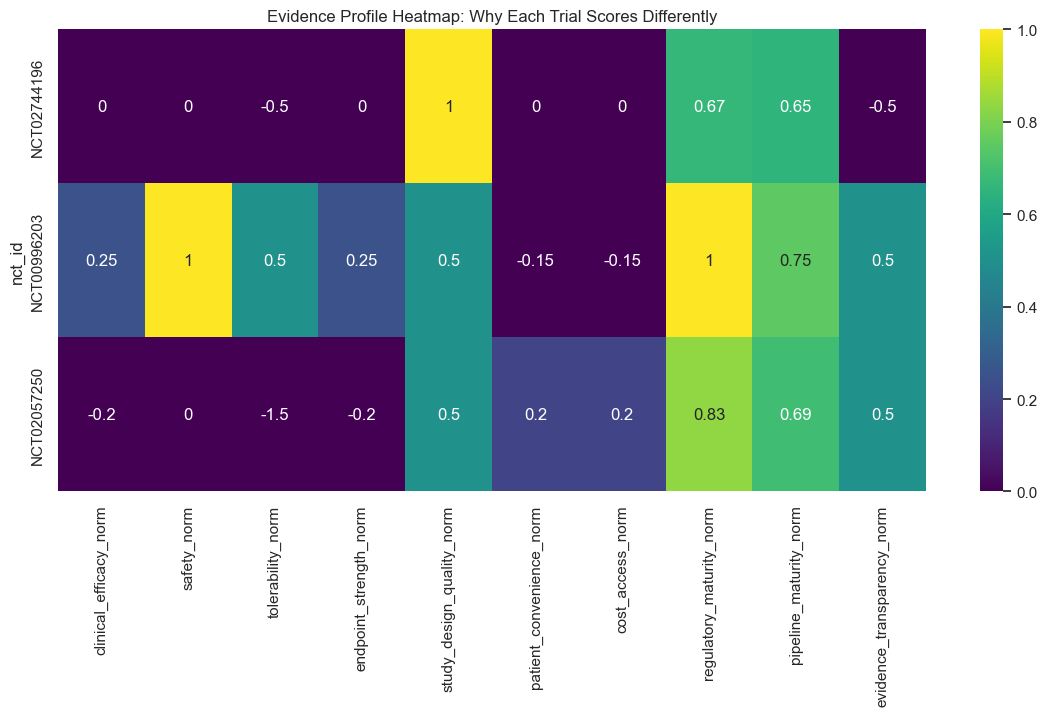

In [19]:
heatmap_cols = [
    'clinical_efficacy_norm',
    'safety_norm',
    'tolerability_norm',
    'endpoint_strength_norm',
    'study_design_quality_norm',
    'patient_convenience_norm',
    'cost_access_norm',
    'regulatory_maturity_norm',
    'pipeline_maturity_norm',
    'evidence_transparency_norm'
]

available_heatmap_cols = [c for c in heatmap_cols if c in scored_df.columns]

plt.figure(figsize=(14, 6))
sns.heatmap(
    scored_df.set_index('nct_id')[available_heatmap_cols],
    annot=True,
    cmap='viridis',
    vmin=0,
    vmax=1
)
plt.title('Evidence Profile Heatmap: Why Each Trial Scores Differently')
plt.show()



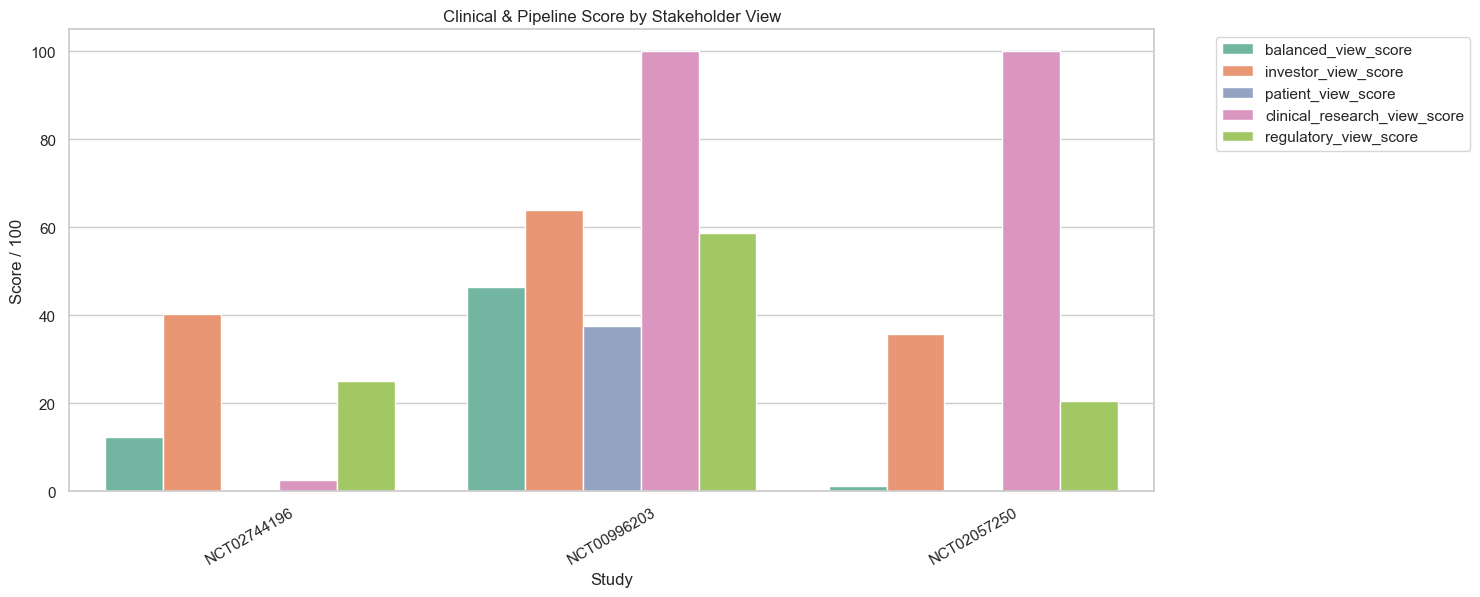

In [20]:
score_cols = [
    'balanced_view_score',
    'investor_view_score',
    'patient_view_score',
    'clinical_research_view_score',
    'regulatory_view_score'
]

plot_df = scored_df[['nct_id'] + score_cols].melt(
    id_vars='nct_id',
    var_name='view',
    value_name='score'
)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x='nct_id', y='score', hue='view', palette='Set2')
plt.title('Clinical & Pipeline Score by Stakeholder View')
plt.ylabel('Score / 100')
plt.xlabel('Study')
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



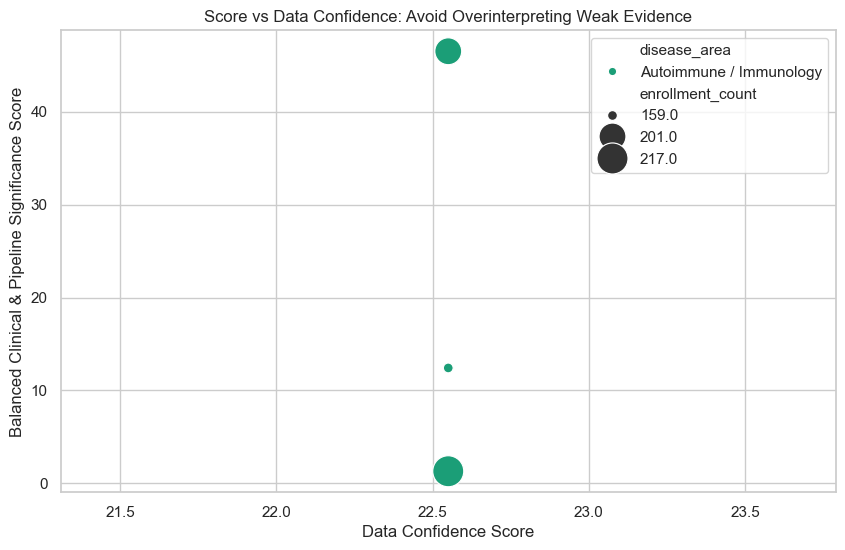

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scored_df,
    x='data_confidence_score',
    y='balanced_view_score',
    hue='disease_area',
    size='enrollment_count',
    sizes=(50, 500),
    palette='Dark2'
)
plt.title('Score vs Data Confidence: Avoid Overinterpreting Weak Evidence')
plt.xlabel('Data Confidence Score')
plt.ylabel('Balanced Clinical & Pipeline Significance Score')
plt.show()



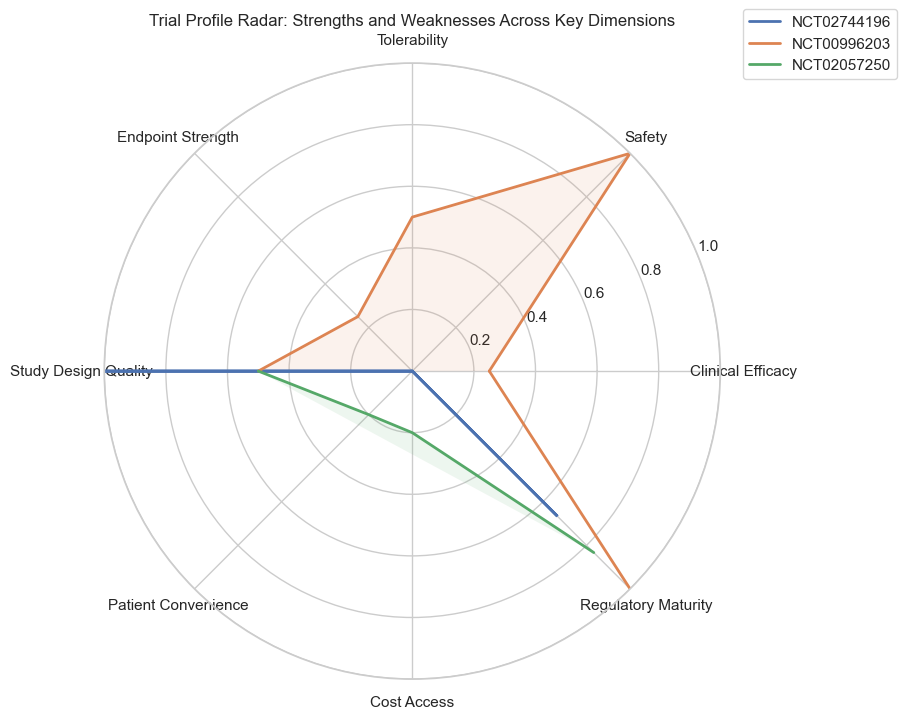

In [22]:
def plot_radar_for_studies(scored_df, nct_ids, factor_cols):
    labels = [c.replace('_norm', '').replace('_', ' ').title() for c in factor_cols]
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for nct_id in nct_ids:
        row = scored_df[scored_df['nct_id'] == nct_id]
        if row.empty:
            continue

        values = row[factor_cols].iloc[0].fillna(0).tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=nct_id)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    plt.title('Trial Profile Radar: Strengths and Weaknesses Across Key Dimensions')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

radar_cols = available_heatmap_cols[:8]
plot_radar_for_studies(scored_df, scored_df['nct_id'].tolist(), radar_cols)



# Rank Stability Analysis

Dynamic weights are useful, but weights are subjective. To test whether conclusions are stable, we randomly perturb the weights and measure how often each trial ranks first.

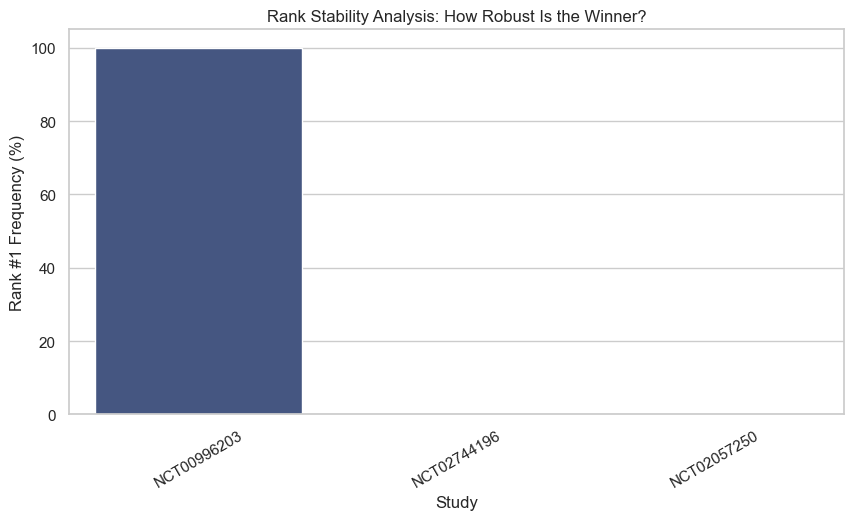

,nct_id,rank_1_count,rank_1_percentage
1,NCT00996203,1000,100.0
0,NCT02744196,0,0.0
2,NCT02057250,0,0.0


In [23]:
# ── Rank Stability / Weight Sensitivity Analysis ─────────────────────────────
def randomize_weights_around_preset(base_weights, n_simulations=1000, noise_scale=0.25, seed=42):
    rng = np.random.default_rng(seed)
    dimensions = list(base_weights.keys())
    base = np.array([base_weights[d] for d in dimensions], dtype=float)
    base = base / base.sum()

    simulations = []

    for _ in range(n_simulations):
        noise = rng.lognormal(mean=0, sigma=noise_scale, size=len(base))
        sampled = base * noise
        sampled = sampled / sampled.sum()
        simulations.append(dict(zip(dimensions, sampled)))

    return simulations

def calculate_score_with_custom_weights(row, custom_weights):
    weighted_sum = 0
    used_weight = 0

    for dimension, weight in custom_weights.items():
        raw_col = DIMENSION_TO_RAW_COLUMN.get(dimension)
        if not raw_col:
            continue

        norm_col = raw_col.replace("_raw", "_norm")
        value = row.get(norm_col)

        if pd.notna(value):
            weighted_sum += float(value) * weight
            used_weight += weight

    if used_weight == 0:
        return np.nan

    score = weighted_sum / used_weight

    # Apply same penalties as main scoring if available
    if row.get("status_penalty_norm", 0) > 0:
        score -= 0.15

    if row.get("missing_endpoint_penalty_norm", 0) > 0:
        score -= 0.10

    return max(0, min(1, score)) * 100

def run_rank_stability_analysis(scored_df, preset_name="balanced_view", n_simulations=1000):
    base_weights = WEIGHT_PRESETS[preset_name]
    weight_sets = randomize_weights_around_preset(base_weights, n_simulations=n_simulations)

    winner_counts = {nct: 0 for nct in scored_df["nct_id"].tolist()}
    rank_records = []

    for i, weights in enumerate(weight_sets):
        temp = scored_df.copy()
        temp["simulated_score"] = temp.apply(lambda row: calculate_score_with_custom_weights(row, weights), axis=1)
        temp = temp.sort_values("simulated_score", ascending=False).reset_index(drop=True)

        winner = temp.iloc[0]["nct_id"]
        winner_counts[winner] += 1

        for rank_idx, row in temp.iterrows():
            rank_records.append({
                "simulation": i,
                "nct_id": row["nct_id"],
                "rank": rank_idx + 1,
                "simulated_score": row["simulated_score"]
            })

    stability_df = pd.DataFrame({
        "nct_id": list(winner_counts.keys()),
        "rank_1_count": list(winner_counts.values())
    })

    stability_df["rank_1_percentage"] = round(stability_df["rank_1_count"] / n_simulations * 100, 2)

    return stability_df.sort_values("rank_1_percentage", ascending=False), pd.DataFrame(rank_records)

rank_stability_df, rank_records_df = run_rank_stability_analysis(scored_df, "balanced_view", 1000)

plt.figure(figsize=(10, 5))
sns.barplot(data=rank_stability_df, x="nct_id", y="rank_1_percentage", hue="nct_id", palette="viridis", legend=False)
plt.title("Rank Stability Analysis: How Robust Is the Winner?")
plt.ylabel("Rank #1 Frequency (%)")
plt.xlabel("Study")
plt.xticks(rotation=30)
plt.show()

display(rank_stability_df)


# Evidence Waterfall Chart

The evidence waterfall explains score intent. It shows which factors increased the score and which penalties reduced it.

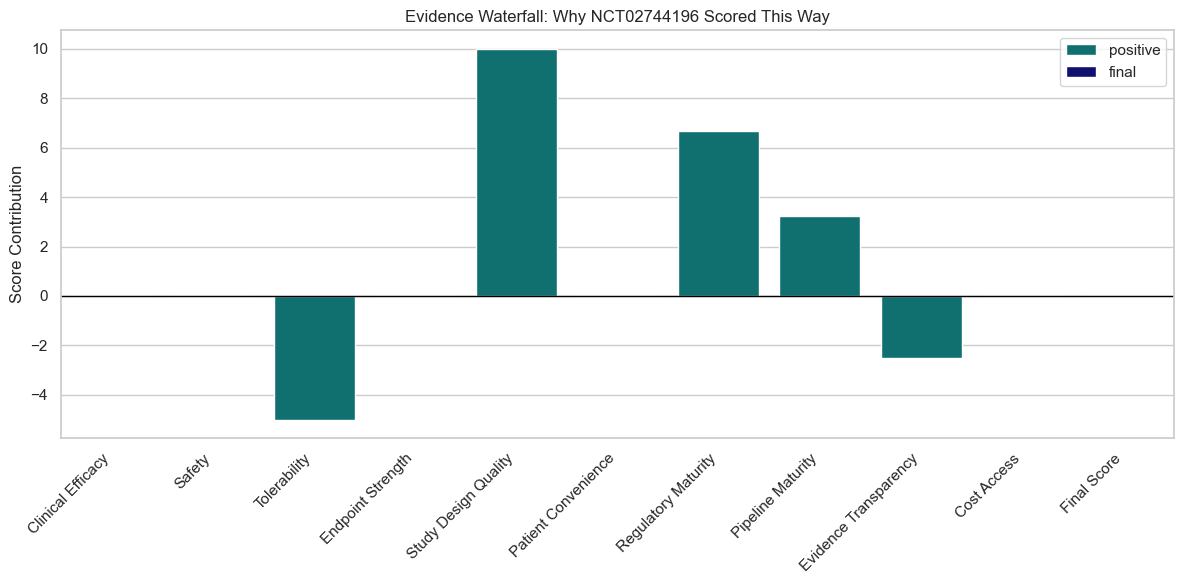

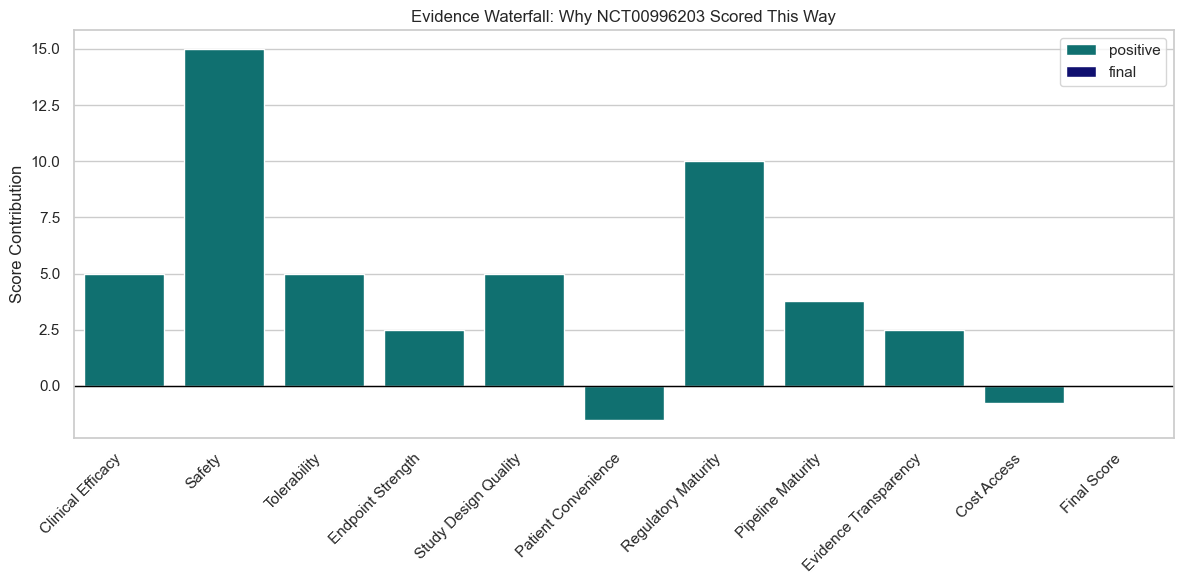

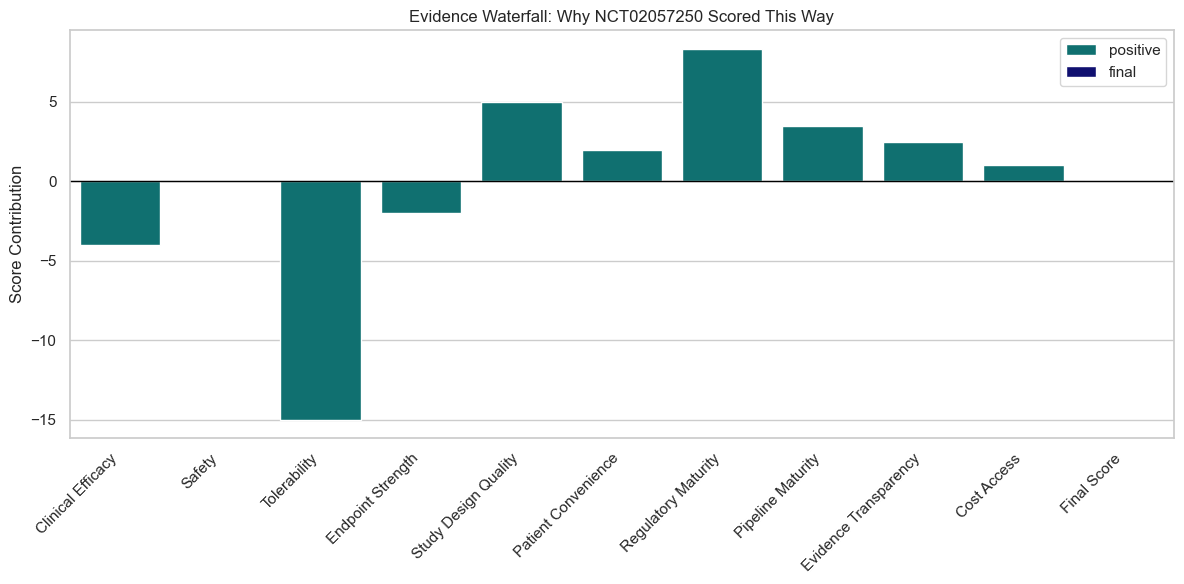

In [24]:
# ── Evidence Waterfall Analysis ─────────────────────────────────────────────
def build_evidence_waterfall_data(row, preset_name="balanced_view"):
    weights = normalize_weights(WEIGHT_PRESETS[preset_name])

    records = []
    cumulative = 0

    for dimension, weight in weights.items():
        raw_col = DIMENSION_TO_RAW_COLUMN.get(dimension)
        if not raw_col:
            continue

        norm_col = raw_col.replace("_raw", "_norm")
        value = row.get(norm_col)

        if pd.isna(value):
            continue

        contribution = float(value) * weight * 100
        cumulative += contribution

        records.append({
            "component": dimension.replace("_", " ").title(),
            "contribution": contribution,
            "cumulative": cumulative,
            "type": "positive"
        })

    penalties = []

    if row.get("status_penalty_norm", 0) > 0:
        penalties.append(("Negative Status Penalty", -15))

    if row.get("missing_endpoint_penalty_norm", 0) > 0:
        penalties.append(("Missing Endpoint Penalty", -10))

    for name, penalty in penalties:
        cumulative += penalty
        records.append({
            "component": name,
            "contribution": penalty,
            "cumulative": cumulative,
            "type": "penalty"
        })

    records.append({
        "component": "Final Score",
        "contribution": 0,
        "cumulative": max(0, min(100, cumulative)),
        "type": "final"
    })

    return pd.DataFrame(records)

def plot_evidence_waterfall(scored_df, nct_id, preset_name="balanced_view"):
    row = scored_df[scored_df["nct_id"] == nct_id].iloc[0]
    waterfall_df = build_evidence_waterfall_data(row, preset_name)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=waterfall_df, x="component", y="contribution", hue="type", dodge=False, palette={"positive": "teal", "penalty": "crimson", "final": "navy"})
    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"Evidence Waterfall: Why {nct_id} Scored This Way")
    plt.ylabel("Score Contribution")
    plt.xlabel("")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="")
    plt.tight_layout()
    plt.show()

for nct_id in scored_df["nct_id"].tolist():
    plot_evidence_waterfall(scored_df, nct_id, "balanced_view")


# Missing Evidence Matrix

Shows what is missing or not parsed from source data.

,nct_id,Primary endpoint,Results section,Outcome results,Statistical analysis,Adverse events,Serious adverse events,Participant flow,Baseline characteristics,Publications,Comparator/design clarity,Masking/blinding
0,NCT02744196,1,0,0,0,0,0,0,0,0,1,1
1,NCT00996203,1,0,0,0,0,0,0,0,0,0,0
2,NCT02057250,1,0,0,0,0,0,0,0,0,0,0


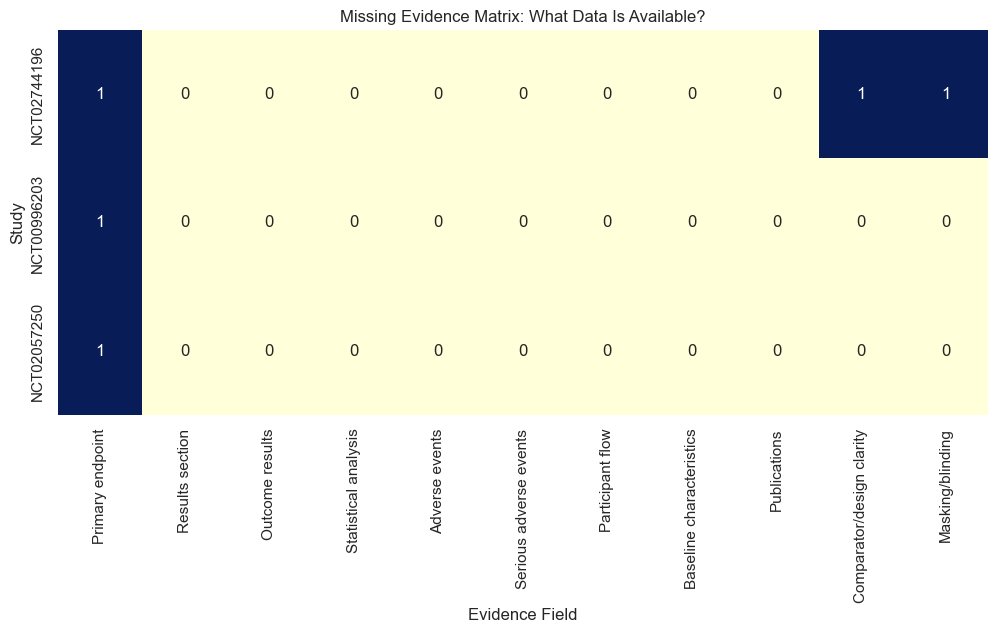

In [25]:
# ── Missing Evidence Matrix ─────────────────────────────────────────────
MISSING_EVIDENCE_CHECKS = {
    "Primary endpoint": "primary_endpoint_count",
    "Results section": "results_section_available",
    "Outcome results": "outcome_results_available",
    "Statistical analysis": "statistical_analysis_count",
    "Adverse events": "adverse_events_available",
    "Serious adverse events": "serious_adverse_event_count",
    "Participant flow": "participant_flow_available",
    "Baseline characteristics": "baseline_available",
    "Publications": "publication_count",
    "Comparator/design clarity": "has_control_signal",
    "Masking/blinding": "has_masking"
}

def build_missing_evidence_matrix(scored_df):
    rows = []

    for _, row in scored_df.iterrows():
        record = {"nct_id": row["nct_id"]}

        for label, field in MISSING_EVIDENCE_CHECKS.items():
            value = row.get(field)

            if field in ["statistical_analysis_count", "publication_count", "primary_endpoint_count"]:
                available = pd.notna(value) and float(value) > 0
            elif field in ["serious_adverse_event_count"]:
                available = pd.notna(value)
            else:
                available = bool(value)

            record[label] = 1 if available else 0

        rows.append(record)

    return pd.DataFrame(rows)

missing_matrix_df = build_missing_evidence_matrix(scored_df)
display(missing_matrix_df)

plt.figure(figsize=(12, 5))
sns.heatmap(
    missing_matrix_df.set_index("nct_id"),
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar=False
)
plt.title("Missing Evidence Matrix: What Data Is Available?")
plt.xlabel("Evidence Field")
plt.ylabel("Study")
plt.show()


# Estimand-Style Clinical Question Checker

This section asks: what clinical question is this trial actually trying to answer?

A strong trial record should clarify population, treatment, comparator, endpoint, summary measure, and handling of intercurrent events.

In [26]:
# ── Estimand-Style Clinical Question Checker Table ─────────────────────────
estimand_cols = [
    "nct_id",
    "estimand_population_available",
    "estimand_treatment_available",
    "estimand_comparator_available",
    "estimand_endpoint_available",
    "estimand_summary_measure_available",
    "estimand_intercurrent_events_available",
    "estimand_completeness_score"
]
display(scored_df[estimand_cols])


,nct_id,estimand_population_available,estimand_treatment_available,estimand_comparator_available,estimand_endpoint_available,estimand_summary_measure_available,estimand_intercurrent_events_available,estimand_completeness_score
0,NCT02744196,False,False,True,False,False,False,16.67
1,NCT00996203,False,False,False,False,False,False,0.00
2,NCT02057250,False,False,False,False,False,False,0.00


# Clinical Reasoning Tree

This is a rule-based clinical reasoning tree for explanation of findings.

In [27]:
# ── Clinical Reasoning Tree ──────────────────────────────────────────────────
def generate_clinical_reasoning_tree(row):
    lines = []

    lines.append("Clinical Reasoning Tree")

    if row.get("has_results", 0):
        lines.append("Results posted: yes → efficacy/safety interpretation may be possible if result details are parsed.")
    else:
        lines.append("Results posted: no → efficacy cannot be judged from registry results.")

    if row.get("primary_endpoint_count", 0) > 0:
        lines.append("Primary endpoint available: yes → endpoint meaningfulness can be assessed.")
    else:
        lines.append("Primary endpoint available: no → endpoint interpretation is weak.")

    if row.get("endpoint_type") in ["Hard clinical endpoint", "Patient-reported / quality-of-life endpoint"]:
        lines.append(f"Endpoint type: {row.get('endpoint_type')} → stronger clinical meaning.")
    elif row.get("endpoint_type") in ["Surrogate / biomarker endpoint", "Intermediate oncology endpoint"]:
        lines.append(f"Endpoint type: {row.get('endpoint_type')} → useful but may require validation against clinical benefit.")
    else:
        lines.append(f"Endpoint type: {row.get('endpoint_type')} → clinical meaning may be limited or unclear.")

    if row.get("actual_adverse_event_data_available", 0):
        lines.append("Adverse-event data available: yes → safety interpretation can be attempted.")
    else:
        lines.append("Adverse-event data available: no → safety/tolerability confidence is limited.")

    if row.get("has_control_signal", 0):
        lines.append("Comparator/control signal: yes → causal interpretation is stronger.")
    else:
        lines.append("Comparator/control signal: not clearly available → causal interpretation is weaker.")

    if row.get("data_confidence_score", 0) < 60:
        lines.append("Data confidence: low/moderate → avoid strong conclusions.")
    else:
        lines.append("Data confidence: acceptable → interpretation is more supportable, but still not predictive.")

    return "\n".join(lines)

scored_df["clinical_reasoning_tree"] = scored_df.apply(generate_clinical_reasoning_tree, axis=1)

for _, row in scored_df.iterrows():
    print("\n" + "="*80)
    print(row["nct_id"])
    print(row["clinical_reasoning_tree"])



NCT02744196
Clinical Reasoning Tree
Results posted: no → efficacy cannot be judged from registry results.
Primary endpoint available: yes → endpoint meaningfulness can be assessed.
Endpoint type: Surrogate / biomarker endpoint → useful but may require validation against clinical benefit.
Adverse-event data available: no → safety/tolerability confidence is limited.
Comparator/control signal: yes → causal interpretation is stronger.
Data confidence: low/moderate → avoid strong conclusions.

NCT00996203
Clinical Reasoning Tree
Results posted: yes → efficacy/safety interpretation may be possible if result details are parsed.
Primary endpoint available: yes → endpoint meaningfulness can be assessed.
Endpoint type: Patient-reported / quality-of-life endpoint → stronger clinical meaning.
Adverse-event data available: yes → safety interpretation can be attempted.
Comparator/control signal: not clearly available → causal interpretation is weaker.
Data confidence: low/moderate → avoid strong co

# Endpoint Meaningfulness Table

Categorizes primary efficacy endpoints based on Tiers 1-5 to assess clinical validity.

In [28]:
# ── Endpoint Meaningfulness Table ───────────────────────────────────────────
def build_endpoint_meaningfulness_table(scored_df):
    rows = []

    for _, row in scored_df.iterrows():
        endpoint_type = row.get("endpoint_type", "Endpoint not clearly available")

        if endpoint_type == "Hard clinical endpoint":
            tier = "Tier 1"
            explanation = "Direct clinical outcome such as survival, mortality, hospitalization, remission, relapse, or disability."
        elif endpoint_type == "Patient-reported / quality-of-life endpoint":
            tier = "Tier 2"
            explanation = "Patient-centered outcome that may capture real-world benefit."
        elif endpoint_type == "Intermediate oncology endpoint":
            tier = "Tier 3"
            explanation = "Useful intermediate endpoint, but may not fully represent long-term clinical benefit."
        elif endpoint_type == "Surrogate / biomarker endpoint":
            tier = "Tier 4"
            explanation = "Biological or surrogate measure that may need validation against clinical outcomes."
        elif endpoint_type == "Safety endpoint":
            tier = "Tier 5"
            explanation = "Important for safety, but not enough alone to prove efficacy."
        else:
            tier = "Unclear"
            explanation = "Endpoint meaning is not clearly available from parsed source data."

        rows.append({
            "nct_id": row.get("nct_id"),
            "endpoint_type": endpoint_type,
            "endpoint_tier": tier,
            "clinical_meaning": explanation
        })

    return pd.DataFrame(rows)

endpoint_meaningfulness_df = build_endpoint_meaningfulness_table(scored_df)
display(endpoint_meaningfulness_df)


,nct_id,endpoint_type,endpoint_tier,clinical_meaning
0,NCT02744196,Surrogate / biomarker endpoint,Tier 4,Biological or surrogate measure that may need validation against clinical outcomes.
1,NCT00996203,Patient-reported / quality-of-life endpoint,Tier 2,Patient-centered outcome that may capture real-world benefit.
2,NCT02057250,Other endpoint,Unclear,Endpoint meaning is not clearly available from parsed source data.


In [29]:
def generate_strengths_risks(row):
    strengths = []
    risks = []
    missing = []

    if row.get('phase_numeric', 0) >= 3:
        strengths.append('Late-stage clinical development signal')
    elif row.get('phase_numeric', 0) <= 1:
        risks.append('Early-stage evidence only')

    if row.get('enrollment_count', 0) >= 200:
        strengths.append('Moderate-to-large enrollment')
    elif row.get('enrollment_count', 0) < 50:
        risks.append('Small enrollment size')

    if row.get('has_results', 0) == 1:
        strengths.append('Results are available in the source record')
    else:
        missing.append('No posted results found in ClinicalTrials.gov record')

    if row.get('publication_count', 0) > 0:
        strengths.append('Linked publication evidence available')
    else:
        missing.append('No linked publication found')

    if row.get('primary_endpoint_count', 0) > 0:
        strengths.append('Primary endpoint available')
    else:
        risks.append('Primary endpoint not clearly available')

    if row.get('is_randomized', 0) == 1:
        strengths.append('Randomized design signal')
    else:
        risks.append('Randomization not clearly identified')

    if row.get('has_masking', 0) == 1:
        strengths.append('Masking/blinding signal available')
    else:
        risks.append('Masking/blinding not clearly identified')

    if row.get('country_count', 0) > 1:
        strengths.append('Multi-country study signal')
    else:
        risks.append('Limited geographic diversity based on available locations')

    if row.get('is_negative_status', 0) == 1:
        risks.append('Terminated, withdrawn, or suspended status signal')

    return {
        'strengths': strengths,
        'risks': risks,
        'missing_data': missing
    }

flags = scored_df.apply(generate_strengths_risks, axis=1)
scored_df['strengths'] = flags.apply(lambda x: x['strengths'])
scored_df['risks'] = flags.apply(lambda x: x['risks'])
scored_df['missing_data'] = flags.apply(lambda x: x['missing_data'])

display(scored_df[['nct_id', 'strengths', 'risks', 'missing_data']])


,nct_id,strengths,risks,missing_data
0,NCT02744196,"[Late-stage clinical development signal, Primary endpoint available, Randomized design signal, Masking/blinding signal available]",[Limited geographic diversity based on available locations],"[No posted results found in ClinicalTrials.gov record, No linked publication found]"
1,NCT00996203,"[Late-stage clinical development signal, Moderate-to-large enrollment, Results are available in the source record, Primary endpoint available, Randomized de...","[Masking/blinding not clearly identified, Limited geographic diversity based on available locations]",[No linked publication found]
2,NCT02057250,"[Late-stage clinical development signal, Moderate-to-large enrollment, Results are available in the source record, Primary endpoint available, Randomized de...",[Masking/blinding not clearly identified],[No linked publication found]


In [30]:
def build_pipeline_summary(df):
    temp = df.copy()

    temp['enrollment'] = pd.to_numeric(temp['enrollment'], errors='coerce')
    temp['phase_numeric'] = temp['phase'].apply(phase_to_numeric)
    temp['status_norm'] = temp['status'].fillna('').str.lower()

    group_cols = ['category', 'sponsor', 'phase', 'status']

    pipeline = temp.groupby(group_cols).agg(
        number_of_studies=('nct_id', 'count'),
        average_enrollment=('enrollment', 'mean'),
        max_enrollment=('enrollment', 'max'),
        average_phase_numeric=('phase_numeric', 'mean'),
    ).reset_index()

    pipeline['completed_flag'] = pipeline['status'].str.lower().str.contains('completed', na=False)
    pipeline['active_flag'] = pipeline['status'].str.lower().str.contains('recruiting|active|not yet', na=False)
    pipeline['negative_status_flag'] = pipeline['status'].str.lower().str.contains('terminated|withdrawn|suspended', na=False)

    return pipeline.sort_values('number_of_studies', ascending=False)

pipeline_summary_df = build_pipeline_summary(df)
display(pipeline_summary_df.head(30))


,category,sponsor,phase,status,number_of_studies,average_enrollment,max_enrollment,average_phase_numeric,completed_flag,active_flag,negative_status_flag
1991,Oncology,National Cancer Institute (NCI),PHASE2,COMPLETED,31,43.516129,101,2.0,True,False,False
632,Autoimmune,Novo Nordisk A/S,PHASE3,COMPLETED,26,916.692308,9341,3.0,True,False,False
629,Autoimmune,Novo Nordisk A/S,PHASE1,COMPLETED,21,64.619048,384,1.0,True,False,False
1986,Oncology,National Cancer Institute (NCI),PHASE1,COMPLETED,20,32.750000,58,1.0,True,False,False
1858,Oncology,M.D. Anderson Cancer Center,PHASE2,COMPLETED,16,63.062500,197,2.0,True,False,False
263,Autoimmune,Eli Lilly and Company,PHASE3,COMPLETED,14,1131.714286,9901,3.0,True,False,False
1852,Oncology,M.D. Anderson Cancer Center,PHASE1,COMPLETED,12,25.416667,63,1.0,True,False,False
1677,Oncology,Hoffmann-La Roche,PHASE3,COMPLETED,11,782.272727,2185,3.0,True,False,False
92,Autoimmune,AstraZeneca,PHASE3,COMPLETED,9,2335.444444,17190,3.0,True,False,False
758,Autoimmune,Sanofi,PHASE4,COMPLETED,9,1064.888889,7376,4.0,True,False,False


## Competitive Benchmark: Why This Matters

Large clinical intelligence platforms focus on trial design, enrollment timelines, patient populations, endpoints, outcomes, geography, sites, investigators, and drug development pipelines.

MindReader’s opportunity is to create a more explainable decision layer:
- Start from public clinical trial data
- Extract comparable structured factors
- Normalize factors into a common scale
- Apply dynamic weights depending on user view
- Produce a transparent Clinical & Pipeline Significance Score
- Explain why a study or pipeline looks strong, weak, risky, or incomplete

This does not replace enterprise clinical databases. It demonstrates an approval-ready method for turning complex trial data into understandable biotech intelligence.

### Industry Context:
- **Reference platform**: Citeline
- **Reference website**: [Citeline](https://www.citeline.com/en/)
- **MindReader site**: [MindReader Biotech](https://www.mindreaderbio.tech/)

Do not copy Citeline’s product. Use it only as market context.


In [31]:
def generate_plain_english_interpretation(scored_df, selected_score_col='balanced_view_score'):
    if scored_df.empty:
        return 'No studies available for interpretation.'

    best = scored_df.sort_values(selected_score_col, ascending=False).iloc[0]
    weakest = scored_df.sort_values(selected_score_col, ascending=True).iloc[0]
    lowest_conf = scored_df.sort_values('data_confidence_score', ascending=True).iloc[0]

    lines = []

    lines.append('## So What It Means')
    lines.append('')
    lines.append(
        f"Based on the selected scoring view, **{best['nct_id']}** has the strongest Clinical & Pipeline Significance Score "
        f"({best[selected_score_col]}/100). This appears to be driven by factors such as endpoint strength, study maturity, design quality, "
        f"results/publication transparency, patient convenience, and pipeline context where available."
    )
    lines.append('')
    lines.append(
        f"**{weakest['nct_id']}** has the lowest score in this selected comparison ({weakest[selected_score_col]}/100). "
        f"This does not mean the therapy failed. It means the available structured data gives weaker evidence or more missing/risk signals under the current weighting method."
    )
    lines.append('')
    lines.append(
        f"The study with the lowest data confidence is **{lowest_conf['nct_id']}** ({lowest_conf['data_confidence_score']}/100). "
        f"This means its score should be interpreted carefully because some source fields are missing or incomplete."
    )
    lines.append('')
    lines.append('### Key Reminder')
    lines.append('')
    lines.append(
        'A low score in the comparison does not represent a lack of therapeutic potential or clinical failure. '
        'It indicates that under the active weighting preset (e.g., balanced, patient, or investor view), the study '
        'has fewer of the positive structural indicators (such as late-stage phase, high enrollment, posted results, or '
        'highly convenient modality like oral administration) or carries specific penalties (like negative overall status or missing endpoints).'
    )
    lines.append('')
    lines.append('### Transparent Score Breakdown')
    for idx, row in scored_df.iterrows():
        lines.append(f"- **{row['nct_id']} ({row['sponsor']})**:")
        lines.append(f"  - Clinical & Pipeline Significance Score ({selected_score_col}): **{row[selected_score_col]}/100**")
        lines.append(f"  - Data Confidence Score: **{row['data_confidence_score']}/100**")
        
        # Breakdown of contributing factors
        breakdown = row.get(f"{selected_score_col.replace('_score', '')}_breakdown", {})
        lines.append('  - Major Contributing Dimension Contributions:')
        for dim, details in breakdown.items():
            if details.get('weighted_contribution', 0) > 0.01:
                lines.append(f"    - {dim.replace('_', ' ').title()}: {round(details['weighted_contribution'] * 100, 1)} points (Normalized Value: {details['normalized_value']}, Weight: {details['weight']})")
        
        penalties = row.get(f"{selected_score_col.replace('_score', '')}_penalty", 0)
        reasons = row.get(f"{selected_score_col.replace('_score', '')}_penalty_reasons", [])
        if penalties > 0:
            lines.append(f"  - Applied Penalties: -{round(penalties, 1)} points due to: {', '.join(reasons)}")
            
    return '\n'.join(lines)

interpretation_md = generate_plain_english_interpretation(scored_df, 'balanced_view_score')
from IPython.display import Markdown
display(Markdown(interpretation_md))


## So What It Means

Based on the selected scoring view, **NCT00996203** has the strongest Clinical & Pipeline Significance Score (46.51/100). This appears to be driven by factors such as endpoint strength, study maturity, design quality, results/publication transparency, patient convenience, and pipeline context where available.

**NCT02057250** has the lowest score in this selected comparison (1.3/100). This does not mean the therapy failed. It means the available structured data gives weaker evidence or more missing/risk signals under the current weighting method.

The study with the lowest data confidence is **NCT02744196** (22.55/100). This means its score should be interpreted carefully because some source fields are missing or incomplete.

### Key Reminder

A low score in the comparison does not represent a lack of therapeutic potential or clinical failure. It indicates that under the active weighting preset (e.g., balanced, patient, or investor view), the study has fewer of the positive structural indicators (such as late-stage phase, high enrollment, posted results, or highly convenient modality like oral administration) or carries specific penalties (like negative overall status or missing endpoints).

### Transparent Score Breakdown
- **NCT02744196 (Biocad)**:
  - Clinical & Pipeline Significance Score (balanced_view_score): **12.42/100**
  - Data Confidence Score: **22.55/100**
  - Major Contributing Dimension Contributions:
    - Study Design Quality: 10.0 points (Normalized Value: 1.0, Weight: 0.1)
    - Regulatory Maturity: 6.7 points (Normalized Value: 0.6667, Weight: 0.1)
    - Pipeline Maturity: 3.2 points (Normalized Value: 0.65, Weight: 0.05)
- **NCT00996203 (Hoffmann-La Roche)**:
  - Clinical & Pipeline Significance Score (balanced_view_score): **46.51/100**
  - Data Confidence Score: **22.55/100**
  - Major Contributing Dimension Contributions:
    - Clinical Efficacy: 5.0 points (Normalized Value: 0.25, Weight: 0.2)
    - Safety: 15.0 points (Normalized Value: 1.0, Weight: 0.15)
    - Tolerability: 5.0 points (Normalized Value: 0.5, Weight: 0.1)
    - Endpoint Strength: 2.5 points (Normalized Value: 0.25, Weight: 0.1)
    - Study Design Quality: 5.0 points (Normalized Value: 0.5, Weight: 0.1)
    - Regulatory Maturity: 10.0 points (Normalized Value: 1.0, Weight: 0.1)
    - Pipeline Maturity: 3.8 points (Normalized Value: 0.7522, Weight: 0.05)
    - Evidence Transparency: 2.5 points (Normalized Value: 0.5, Weight: 0.05)
- **NCT02057250 (Sanofi)**:
  - Clinical & Pipeline Significance Score (balanced_view_score): **1.3/100**
  - Data Confidence Score: **22.55/100**
  - Major Contributing Dimension Contributions:
    - Study Design Quality: 5.0 points (Normalized Value: 0.5, Weight: 0.1)
    - Patient Convenience: 2.0 points (Normalized Value: 0.2, Weight: 0.1)
    - Regulatory Maturity: 8.3 points (Normalized Value: 0.8333, Weight: 0.1)
    - Pipeline Maturity: 3.5 points (Normalized Value: 0.6941, Weight: 0.05)
    - Evidence Transparency: 2.5 points (Normalized Value: 0.5, Weight: 0.05)

# Dynamic AI Trial Analysis Layer

This section upgrades the notebook from a rule-based scoring prototype into a
dynamic, AI-assisted, evidence-grounded trial analysis system.

Instead of generic summaries, MindReader analyses each trial **one dimension at
a time**, forcing the AI to stay grounded in the source data and to
explicitly flag missing evidence.

```
Structured source data
    ↓
Dynamic dimension registry
    ↓
Feature availability check
    ↓
AI analysis one dimension at a time
    ↓
JSON output validation
    ↓
Evidence-gap detection
    ↓
Final trial intelligence card
```


In [32]:
# ── LLM initialisation ───────────────────────────────────────────────────────
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

api_key = os.getenv('OPENROUTER_API_KEY')
if not api_key:
    raise ValueError('OPENROUTER_API_KEY not found. Add it to your .env file.')

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model='openrouter/free',
    openai_api_key=api_key,
    openai_api_base='https://openrouter.ai/api/v1',
    temperature=0.2,
    max_tokens=3000,
    timeout=45,
    default_headers={
        'HTTP-Referer': 'https://mindreaderbio.tech',
        'X-Title': 'MindReader Biotech Intelligence',
    },
)
print('LLM ready:', llm.model_name)



LLM ready: openrouter/free


In [33]:
# ── 1. Dynamic Analysis Dimension Registry ───────────────────────────────────
ANALYSIS_DIMENSION_REGISTRY = {
    'trial_identity': {
        'display_name': 'Trial Identity',
        'purpose': 'Identify what is being tested, in whom, by whom, and at what stage.',
        'required_fields': ['nct_id', 'brief_title', 'conditions', 'intervention_names', 'lead_sponsor', 'phase', 'status'],
        'optional_fields': ['official_title', 'study_type', 'primary_purpose', 'enrollment_count'],
        'analysis_questions': [
            'What is the trial testing?',
            'What disease or condition is being studied?',
            'What intervention or therapy is being evaluated?',
            'Who is the sponsor?',
            'What stage of development does the trial appear to represent?',
        ],
        'forbidden_claims': [
            'Do not infer efficacy.',
            'Do not infer safety.',
            'Do not claim regulatory approval.',
        ],
    },
    'clinical_efficacy_interpretability': {
        'display_name': 'Clinical Efficacy Interpretability',
        'purpose': 'Assess whether available source data allows interpretation of therapeutic benefit.',
        'required_fields': ['primary_outcomes', 'secondary_outcomes', 'has_results'],
        'optional_fields': ['raw_results_available', 'endpoint_type', 'status', 'enrollment_count'],
        'analysis_questions': [
            'Are efficacy endpoints available?',
            'Are results posted?',
            'Can therapeutic benefit be interpreted from the available source data?',
            'Are endpoints clinically meaningful or only surrogate/intermediate?',
            'What evidence is missing before efficacy can be judged?',
        ],
        'forbidden_claims': [
            'Do not say the therapy works unless source results support it.',
            'Do not invent p-values, effect sizes, or response rates.',
            'Do not infer clinical success from phase alone.',
        ],
    },
    'endpoint_meaningfulness': {
        'display_name': 'Endpoint Meaningfulness',
        'purpose': 'Judge whether endpoints are hard clinical, patient-centered, surrogate, biomarker, safety-only, or unclear.',
        'required_fields': ['primary_outcomes', 'secondary_outcomes'],
        'optional_fields': ['endpoint_type', 'primary_purpose', 'conditions'],
        'analysis_questions': [
            'What are the primary endpoints?',
            'Are endpoints hard clinical outcomes, patient-reported outcomes, surrogate endpoints, biomarkers, safety endpoints, or unclear?',
            'Do the endpoints align with the disease context?',
            'Would a non-expert understand why these endpoints matter?',
        ],
        'forbidden_claims': [
            'Do not claim endpoint success unless results are available.',
            'Do not assume regulatory acceptance of an endpoint.',
        ],
    },
    'safety_and_tolerability': {
        'display_name': 'Safety and Tolerability',
        'purpose': 'Assess what safety and tolerability information is available or missing.',
        'required_fields': ['has_results', 'primary_outcomes', 'secondary_outcomes'],
        'optional_fields': ['raw_results_available'],
        'analysis_questions': [
            'Is safety directly measured?',
            'Are adverse events available in source data?',
            'Are serious adverse events available?',
            'Is tolerability measured through discontinuation, withdrawal, QoL, or patient-reported outcomes?',
            'What safety/tolerability evidence is missing?',
        ],
        'forbidden_claims': [
            'Do not say the therapy has no side effects unless adverse-event data proves it.',
            'Do not invent adverse events.',
            'Do not infer tolerability only from study completion.',
        ],
    },
    'patient_adoption_burden': {
        'display_name': 'Patient Adoption Burden',
        'purpose': 'Analyze how easy or difficult the therapy may be for patients to use.',
        'required_fields': ['intervention_names', 'intervention_types'],
        'optional_fields': ['eligibility_criteria', 'countries', 'facility_count', 'primary_outcomes', 'secondary_outcomes'],
        'analysis_questions': [
            'Does the therapy appear oral, injectable, infusion-based, device-based, procedural, behavioral, or unclear?',
            'Does source data suggest patient burden such as visits, monitoring, specialized sites, or complex administration?',
            'Is home use likely or not inferable?',
            'What convenience information is missing?',
        ],
        'forbidden_claims': [
            'Do not invent dosing frequency.',
            'Do not invent cost.',
            'Do not infer home use unless source data suggests it.',
        ],
    },
    'population_relevance': {
        'display_name': 'Population Relevance',
        'purpose': 'Assess whether the enrolled population is clear, broad, narrow, biomarker-selected, severe, refractory, pediatric, adult, or unclear.',
        'required_fields': ['conditions', 'minimum_age', 'maximum_age', 'sex', 'eligibility_criteria'],
        'optional_fields': ['enrollment_count', 'countries', 'facility_count'],
        'analysis_questions': [
            'Who is eligible for the trial?',
            'Is the patient population broad or narrow?',
            'Are there age, sex, severity, prior-treatment, or biomarker restrictions?',
            'How generalizable does the population appear based on available data?',
        ],
        'forbidden_claims': [
            'Do not infer real-world generalizability beyond source data.',
            'Do not invent demographic diversity.',
        ],
    },
    'study_design_quality': {
        'display_name': 'Study Design Quality',
        'purpose': 'Assess design robustness based on randomization, comparator, masking, arms, study type, enrollment, and duration.',
        'required_fields': ['study_type', 'allocation', 'intervention_model', 'masking', 'number_of_arms', 'enrollment_count'],
        'optional_fields': ['primary_purpose', 'start_date', 'completion_date', 'countries', 'facility_count'],
        'analysis_questions': [
            'Is the study interventional or observational?',
            'Is randomization available?',
            'Is masking/blinding available?',
            'Is there a comparator or control signal?',
            'Is enrollment size adequate for interpretation?',
            'What design limitations are visible?',
        ],
        'forbidden_claims': [
            'Do not call a study definitive unless source evidence supports it.',
            'Do not infer statistical power unless sample-size assumptions are available.',
        ],
    },
    'regulatory_readiness': {
        'display_name': 'Regulatory Readiness',
        'purpose': 'Assess whether the trial looks exploratory, supportive, pivotal-like, or insufficient based on available structured data.',
        'required_fields': ['phase', 'status', 'has_results', 'primary_outcomes', 'study_type', 'enrollment_count'],
        'optional_fields': ['completion_date', 'publication_count', 'sponsor_class'],
        'analysis_questions': [
            'Does the trial appear early exploratory, mid-stage, late-stage, post-marketing, or unclear?',
            'Are results available?',
            'Are endpoints and design strong enough to support regulatory interpretation?',
            'What regulatory evidence is missing?',
        ],
        'forbidden_claims': [
            'Do not claim FDA/EMA approval likelihood.',
            'Do not claim the study is pivotal unless explicitly supported.',
            'Do not infer regulatory success.',
        ],
    },
    'economic_and_access_relevance': {
        'display_name': 'Economic and Access Relevance',
        'purpose': 'Identify cost/access questions and available proxies, without inventing price.',
        'required_fields': ['intervention_names', 'intervention_types', 'facility_count', 'countries'],
        'optional_fields': ['eligibility_criteria'],
        'analysis_questions': [
            'What cost/access factors can be inferred as questions or proxies?',
            'Does the intervention suggest expensive delivery such as infusion, biologic, cell therapy, specialized procedure, or device?',
            'Does the trial setting suggest specialized access burden?',
            'What pricing/reimbursement evidence is missing?',
        ],
        'forbidden_claims': [
            'Do not invent drug price.',
            'Do not invent reimbursement status.',
            'Do not claim cost-effectiveness unless economic data is available.',
        ],
    },
    'evidence_transparency': {
        'display_name': 'Evidence Transparency',
        'purpose': 'Assess whether the study has enough visible evidence to support interpretation.',
        'required_fields': ['has_results', 'publication_count', 'primary_outcomes', 'secondary_outcomes', 'status'],
        'optional_fields': ['completion_date', 'raw_results_available', 'publications'],
        'analysis_questions': [
            'Are results posted?',
            'Are publications linked?',
            'Are endpoints available?',
            'Is the study completed but missing results?',
            'What evidence should be reviewed next?',
        ],
        'forbidden_claims': [
            'Do not treat missing data as negative efficacy.',
            'Do not overinterpret incomplete records.',
        ],
    },
    'red_team_risk_review': {
        'display_name': 'Red-Team Risk Review',
        'purpose': 'Identify what could be misleading if someone only looked at phase, title, sponsor, or score.',
        'required_fields': ['nct_id', 'brief_title', 'phase', 'status', 'has_results', 'primary_outcomes', 'enrollment_count'],
        'optional_fields': ['publication_count', 'countries', 'facility_count'],
        'analysis_questions': [
            'What could be misleading about this trial?',
            'What should a user not conclude from the available data?',
            'What is the biggest interpretation risk?',
            'What evidence would change the analysis?',
        ],
        'forbidden_claims': [
            'Do not provide investment advice.',
            'Do not make treatment recommendations.',
            'Do not predict clinical success.',
        ],
    },
}

print(f'Registered {len(ANALYSIS_DIMENSION_REGISTRY)} analysis dimensions.')


Registered 11 analysis dimensions.


In [34]:
# ── 2. Dimension Availability Checker ────────────────────────────────────────
import pandas as pd

def get_available_analysis_dimensions(trial_data, registry):
    available = []
    for key, config in registry.items():
        required_fields = config.get('required_fields', [])
        present_count = 0
        for field in required_fields:
            value = trial_data.get(field)
            if value is None:
                continue
            if isinstance(value, float) and pd.isna(value):
                continue
            if isinstance(value, str) and value.strip() == '':
                continue
            if isinstance(value, list) and len(value) == 0:
                continue
            present_count += 1
        coverage = present_count / max(len(required_fields), 1)
        if coverage >= 0.4:
            status = 'available'
        elif coverage > 0:
            status = 'partial'
        else:
            status = 'insufficient'
        available.append({
            'dimension': key,
            'display_name': config['display_name'],
            'coverage': round(coverage, 2),
            'status': status,
            'required_fields': required_fields,
            'present_required_fields': present_count,
            'total_required_fields': len(required_fields),
        })
    return pd.DataFrame(available).sort_values('coverage', ascending=False)

if parsed_studies:
    sample_avail = get_available_analysis_dimensions(parsed_studies[0], ANALYSIS_DIMENSION_REGISTRY)
    display(sample_avail[['display_name', 'coverage', 'status', 'present_required_fields', 'total_required_fields']])


,display_name,coverage,status,present_required_fields,total_required_fields
0,Trial Identity,1.00,available,7,7
1,Clinical Efficacy Interpretability,1.00,available,3,3
2,Endpoint Meaningfulness,1.00,available,2,2
3,Safety and Tolerability,1.00,available,3,3
4,Patient Adoption Burden,1.00,available,2,2
5,Population Relevance,1.00,available,5,5
6,Study Design Quality,1.00,available,6,6
7,Regulatory Readiness,1.00,available,6,6
9,Evidence Transparency,1.00,available,5,5
10,Red-Team Risk Review,1.00,available,7,7


In [35]:
# ── 3. Trial AI Context Builder ──────────────────────────────────────────────
def prepare_trial_ai_context(trial_data, scored_row=None, max_text_chars=1500):
    context = {
        'source_note': 'Use only this structured source data. If something is missing, say Not available in source data.',
        'trial_identity': {
            'nct_id': trial_data.get('nct_id'),
            'brief_title': trial_data.get('brief_title'),
            'official_title': trial_data.get('official_title'),
            'status': trial_data.get('status'),
            'phase': trial_data.get('phase'),
            'study_type': trial_data.get('study_type'),
            'lead_sponsor': trial_data.get('lead_sponsor'),
            'sponsor_class': trial_data.get('sponsor_class'),
        },
        'disease_and_intervention': {
            'conditions': trial_data.get('conditions'),
            'keywords': trial_data.get('keywords'),
            'intervention_names': trial_data.get('intervention_names'),
            'intervention_types': trial_data.get('intervention_types'),
        },
        'design': {
            'allocation': trial_data.get('allocation'),
            'intervention_model': trial_data.get('intervention_model'),
            'masking': trial_data.get('masking'),
            'primary_purpose': trial_data.get('primary_purpose'),
            'number_of_arms': trial_data.get('number_of_arms'),
            'enrollment_count': trial_data.get('enrollment_count'),
            'start_date': trial_data.get('start_date'),
            'primary_completion_date': trial_data.get('primary_completion_date'),
            'completion_date': trial_data.get('completion_date'),
        },
        'outcomes': {
            'primary_outcomes': trial_data.get('primary_outcomes'),
            'secondary_outcomes': trial_data.get('secondary_outcomes'),
            'other_outcomes': trial_data.get('other_outcomes'),
        },
        'eligibility': {
            'minimum_age': trial_data.get('minimum_age'),
            'maximum_age': trial_data.get('maximum_age'),
            'sex': trial_data.get('sex'),
            'healthy_volunteers': trial_data.get('healthy_volunteers'),
            'eligibility_criteria_excerpt': str(trial_data.get('eligibility_criteria', ''))[:max_text_chars],
        },
        'locations': {
            'countries': trial_data.get('countries'),
            'facility_count': trial_data.get('facility_count'),
        },
        'evidence': {
            'has_results': trial_data.get('has_results'),
            'raw_results_available': trial_data.get('raw_results_available'),
            'publication_count': trial_data.get('publication_count'),
            'publications': trial_data.get('publications'),
        },
    }
    if scored_row is not None:
        sr = scored_row
        context['scores'] = {
            'balanced_view_score': float(sr.get('balanced_view_score', 0)),
            'investor_view_score': float(sr.get('investor_view_score', 0)),
            'patient_view_score': float(sr.get('patient_view_score', 0)),
            'clinical_research_view_score': float(sr.get('clinical_research_view_score', 0)),
            'regulatory_view_score': float(sr.get('regulatory_view_score', 0)),
            'data_confidence_score': float(sr.get('data_confidence_score', 0)),
            'endpoint_type': sr.get('endpoint_type'),
            'disease_area': sr.get('disease_area'),
            'modality': sr.get('modality'),
        }
    return context


In [36]:
# ── 4. Strict AI Prompt Builder ──────────────────────────────────────────────
import json

OUTPUT_SCHEMA_TEMPLATE = '''
{{
  "dimension_key": "{dim_key}",
  "dimension_name": "{dim_name}",
  "nct_id": "{nct}",
  "summary": "2-5 sentence analysis grounded only in source data.",
  "positive_signals": ["specific positive signal from source data"],
  "risk_signals": ["specific risk, limitation, or uncertainty from source data"],
  "missing_evidence": ["specific missing data needed for stronger interpretation"],
  "interpretation_level": "strong | moderate | weak | insufficient",
  "confidence": "high | medium | low",
  "source_fields_used": ["field names from the provided source data"],
  "do_not_conclude": ["things users should not conclude from this source data"]
}}
'''

def build_dimension_ai_prompt(trial_context, dimension_key, dimension_config):
    nct = trial_context['trial_identity'].get('nct_id', 'UNKNOWN')
    schema = OUTPUT_SCHEMA_TEMPLATE.format(
        dim_key=dimension_key,
        dim_name=dimension_config['display_name'],
        nct=nct,
    )
    parts = [
        'You are a clinical trial intelligence analyst for MindReader Biotech.',
        '',
        f'Analyze exactly one dimension: {dimension_config["display_name"]}',
        '',
        f'Purpose: {dimension_config["purpose"]}',
        '',
        'Use only the structured source data provided below.',
        'Do not use outside knowledge.',
        'Do not invent missing results, side effects, efficacy, safety, cost, market size, or regulatory claims.',
        'If a required fact is not available, write exactly: "Not available in source data."',
        '',
        'Analysis questions:',
        json.dumps(dimension_config.get('analysis_questions', []), indent=2),
        '',
        'Forbidden claims:',
        json.dumps(dimension_config.get('forbidden_claims', []), indent=2),
        '',
        'Source data:',
        json.dumps(trial_context, indent=2, default=str),
        '',
        'Return strict JSON only. No markdown, no explanation outside the JSON.',
        '',
        'Required output schema:',
        schema,
    ]
    return '\n'.join(parts)


In [37]:
def repair_ai_output(output, dimension_key, dimension_config, nct_id):
    defaults = {
        "dimension_key": dimension_key,
        "dimension_name": dimension_config["display_name"],
        "nct_id": nct_id,
        "summary": "Not available in source data.",
        "positive_signals": [],
        "risk_signals": [],
        "missing_evidence": [],
        "interpretation_level": "insufficient",
        "confidence": "low",
        "source_fields_used": [],
        "do_not_conclude": []
    }

    if not isinstance(output, dict):
        return defaults

    repaired = {**defaults, **output}

    level = str(repaired.get("interpretation_level", "")).lower().strip()
    level_map = {
        "high": "strong",
        "medium": "moderate",
        "low": "weak",
        "none": "insufficient",
        "not available": "insufficient"
    }

    repaired["interpretation_level"] = level_map.get(level, level)

    if repaired["interpretation_level"] not in ["strong", "moderate", "weak", "insufficient"]:
        repaired["interpretation_level"] = "insufficient"

    if str(repaired.get("confidence", "")).lower() not in ["high", "medium", "low"]:
        repaired["confidence"] = "low"

    for key in ["positive_signals", "risk_signals", "missing_evidence", "source_fields_used", "do_not_conclude"]:
        if repaired.get(key) is None:
            repaired[key] = []
        elif not isinstance(repaired.get(key), list):
            repaired[key] = [str(repaired[key])]

    return repaired

# ── 5. LLM Dimension Analysis Wrapper ────────────────────────────────────────
def run_ai_dimension_analysis(llm, trial_context, dimension_key, dimension_config):
    prompt = build_dimension_ai_prompt(trial_context, dimension_key, dimension_config)
    try:
        response = llm.invoke(prompt)
        text = response.content if hasattr(response, 'content') else str(response)
        text = text.strip()
        if text.startswith('```json'):
            text = text[7:]
        if text.startswith('```'):
            text = text[3:]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
        return json.loads(text)
    except Exception as e:
        nct = trial_context['trial_identity'].get('nct_id', 'UNKNOWN')
        return {
            'dimension_key': dimension_key,
            'dimension_name': dimension_config['display_name'],
            'nct_id': nct,
            'summary': f'AI analysis failed: {str(e)[:200]}',
            'positive_signals': [],
            'risk_signals': [str(e)[:300]],
            'missing_evidence': [],
            'interpretation_level': 'insufficient',
            'confidence': 'low',
            'source_fields_used': [],
            'do_not_conclude': ['Do not use this failed AI output for interpretation.'],
        }



In [38]:
# ── 6. Run AI Analysis One Dimension at a Time ───────────────────────────────
def run_full_dynamic_ai_analysis_for_trial(llm, trial_data, scored_row=None, registry=ANALYSIS_DIMENSION_REGISTRY):
    trial_context = prepare_trial_ai_context(trial_data, scored_row)
    availability_df = get_available_analysis_dimensions(trial_data, registry)
    outputs = []
    for _, dim_row in availability_df.iterrows():
        dimension_key = dim_row['dimension']
        dimension_config = registry[dimension_key]
        print(f"  → {dim_row['display_name']} (coverage={dim_row['coverage']}, status={dim_row['status']})")
        result = run_ai_dimension_analysis(
            llm=llm,
            trial_context=trial_context,
            dimension_key=dimension_key,
            dimension_config=dimension_config,
        )
        result['dimension_coverage'] = dim_row['coverage']
        result['dimension_availability_status'] = dim_row['status']
        outputs.append(result)
    return {
        'nct_id': trial_data.get('nct_id'),
        'availability': availability_df.to_dict(orient='records'),
        'dimension_outputs': outputs,
    }


all_ai_trial_outputs = []
for study in parsed_studies:
    nct_id = study.get('nct_id')
    scored_match = scored_df[scored_df['nct_id'] == nct_id]
    scored_row = scored_match.iloc[0] if not scored_match.empty else None
    print(f'\nRunning dynamic AI analysis for {nct_id}...')
    output = run_full_dynamic_ai_analysis_for_trial(llm=llm, trial_data=study, scored_row=scored_row)
    all_ai_trial_outputs.append(output)

total_dims = sum(len(t['dimension_outputs']) for t in all_ai_trial_outputs)
print(f'\nCompleted: {len(all_ai_trial_outputs)} trials, {total_dims} dimension outputs.')



Running dynamic AI analysis for NCT02744196...
  → Trial Identity (coverage=1.0, status=available)


  → Clinical Efficacy Interpretability (coverage=1.0, status=available)


  → Endpoint Meaningfulness (coverage=1.0, status=available)


  → Safety and Tolerability (coverage=1.0, status=available)


  → Patient Adoption Burden (coverage=1.0, status=available)


...

  → Economic and Access Relevance (coverage=1.0, status=available)


  → Evidence Transparency (coverage=1.0, status=available)


  → Red-Team Risk Review (coverage=1.0, status=available)


  → Population Relevance (coverage=0.8, status=available)



Completed: 3 trials, 33 dimension outputs.


In [39]:
# ── 7. Flatten AI Outputs to DataFrame ───────────────────────────────────────
def flatten_ai_outputs(all_ai_trial_outputs):
    rows = []
    for trial_output in all_ai_trial_outputs:
        for item in trial_output['dimension_outputs']:
            rows.append({
                'nct_id': item.get('nct_id'),
                'dimension_key': item.get('dimension_key'),
                'dimension_name': item.get('dimension_name'),
                'summary': item.get('summary'),
                'positive_signals': '; '.join(item.get('positive_signals') or []),
                'risk_signals': '; '.join(item.get('risk_signals') or []),
                'missing_evidence': '; '.join(item.get('missing_evidence') or []),
                'interpretation_level': item.get('interpretation_level'),
                'confidence': item.get('confidence'),
                'dimension_coverage': item.get('dimension_coverage'),
                'availability_status': item.get('dimension_availability_status'),
                'source_fields_used': '; '.join(item.get('source_fields_used') or []),
                'do_not_conclude': '; '.join(item.get('do_not_conclude') or []),
            })
    return pd.DataFrame(rows)


ai_analysis_df = flatten_ai_outputs(all_ai_trial_outputs)
display(ai_analysis_df[['nct_id', 'dimension_name', 'interpretation_level', 'confidence', 'summary']].head(20))


,nct_id,dimension_name,interpretation_level,confidence,summary
0,NCT02744196,Trial Identity,insufficient,medium,"The trial is a Phase 3, multicenter, randomized, double‑blind, placebo‑controlled study evaluating Acellbia® in combination with methotrexate as first‑line ..."
1,NCT02744196,Clinical Efficacy Interpretability,insufficient,low,"The trial defines multiple efficacy endpoints (ACR20/50/70, DAS28-4, HAQ-DI, radiographic scores) at 16, 24, and 52 weeks, but no results are posted or avai..."
2,NCT02744196,Endpoint Meaningfulness,weak,low,"The trial’s primary endpoint is the proportion of patients achieving an ACR20 response at 24 weeks, a standard clinical response criterion used in rheumatoi..."
3,NCT02744196,Safety and Tolerability,insufficient,low,"The trial includes secondary outcomes that directly measure safety (frequency and severity of AE/SAE, grade 3‑4 CTCAE events, premature withdrawal due to AE..."
4,NCT02744196,Patient Adoption Burden,moderate,medium,"The trial evaluates Acellbia®, a biologic antibody, administered as an injection (AE reporting references ""patients who received at least one injection of s..."
5,NCT02744196,Population Relevance,moderate,medium,"The trial enrolled adults aged 18 to 80 with active rheumatoid arthritis who had documented disease activity (≥8 swollen and ≥8 painful joints, elevated CRP..."
6,NCT02744196,Study Design Quality,moderate,medium,"The trial is a Phase 3 interventional study with a randomized, parallel, triple‑masked design comparing Acellbia plus methotrexate to placebo plus methotrex..."
7,NCT02744196,Regulatory Readiness,weak,medium,"The trial is a Phase 3, randomized, double‑blind, placebo‑controlled study with 159 participants that completed in 2017. Primary and multiple secondary endp..."
8,NCT02744196,Evidence Transparency,weak,low,"The trial is marked as completed, but the evidence section indicates that no results or publications are available. Primary and secondary endpoints are clea..."
9,NCT02744196,Red-Team Risk Review,weak,low,"The trial is a Phase 3, randomized, double‑blind, placebo‑controlled study evaluating Acellbia with methotrexate versus placebo in rheumatoid arthritis pati..."


In [40]:
# ── 8. Trial Intelligence Cards ──────────────────────────────────────────────
from IPython.display import display, Markdown

def generate_trial_intelligence_card(nct_id, ai_analysis_df, scored_df):
    trial_ai = ai_analysis_df[ai_analysis_df['nct_id'] == nct_id]
    score_row = scored_df[scored_df['nct_id'] == nct_id]
    score_text = ''
    if not score_row.empty:
        r = score_row.iloc[0]
        bal  = r.get('balanced_view_score', 'NA')
        inv  = r.get('investor_view_score', 'NA')
        pat  = r.get('patient_view_score', 'NA')
        clin = r.get('clinical_research_view_score', 'NA')
        reg  = r.get('regulatory_view_score', 'NA')
        conf = r.get('data_confidence_score', 'NA')
        score_text = (
            '\n### Clinical & Pipeline Significance Scores\n\n'
            '| View | Score |\n|---|---|\n'
            f'| Balanced | {bal}/100 |\n'
            f'| Investor | {inv}/100 |\n'
            f'| Patient | {pat}/100 |\n'
            f'| Clinical Research | {clin}/100 |\n'
            f'| Regulatory | {reg}/100 |\n'
            f'| Data Confidence | {conf}/100 |\n'
        )
    lines = [f'# Trial Intelligence Card: {nct_id}', '', score_text, '', '## Dimension-Level AI Analysis', '']
    for _, row in trial_ai.iterrows():
        lines += [
            f"### {row['dimension_name']}", '',
            f"**Summary:** {row['summary']}", '',
            f"**Positive signals:** {row['positive_signals'] or 'Not available in source data.'}", '',
            f"**Risk signals:** {row['risk_signals'] or 'Not available in source data.'}", '',
            f"**Missing evidence:** {row['missing_evidence'] or 'Not available in source data.'}", '',
            f"**Confidence:** {row['confidence']} | **Interpretation:** {row['interpretation_level']}", '',
            f"**Do not conclude:** {row['do_not_conclude'] or 'No extra restriction noted.'}", '',
        ]
    return '\n'.join(lines)


trial_cards = {}
for nct_id in scored_df['nct_id'].tolist():
    card = generate_trial_intelligence_card(nct_id, ai_analysis_df, scored_df)
    trial_cards[nct_id] = card
    display(Markdown(card))


# Trial Intelligence Card: NCT02744196


### Clinical & Pipeline Significance Scores

| View | Score |
|---|---|
| Balanced | 12.42/100 |
| Investor | 40.25/100 |
| Patient | 0.0/100 |
| Clinical Research | 2.5/100 |
| Regulatory | 25.0/100 |
| Data Confidence | 22.55/100 |


## Dimension-Level AI Analysis

### Trial Identity

**Summary:** The trial is a Phase 3, multicenter, randomized, double‑blind, placebo‑controlled study evaluating Acellbia® in combination with methotrexate as first‑line biological therapy for patients with active rheumatoid arthritis. It was sponsored by Biocad (industry sponsor) and enrolled 159 adults (18‑80 years) with active disease. The study status is completed, but no results are posted.

**Positive signals:** Phase 3 trial; Randomized, triple‑masked design; Completed status

**Risk signals:** No results or safety data are available in the source; Location information is missing, limiting context; Relatively modest enrollment (159 participants)

**Missing evidence:** Primary and secondary outcome results; Safety and adverse event data; Geographic location of study sites

**Confidence:** medium | **Interpretation:** insufficient

**Do not conclude:** Efficacy of Acellbia®; Safety profile of the intervention; Regulatory approval status; Comparative superiority over existing therapies

### Clinical Efficacy Interpretability

**Summary:** The trial defines multiple efficacy endpoints (ACR20/50/70, DAS28-4, HAQ-DI, radiographic scores) at 16, 24, and 52 weeks, but no results are posted or available in the source data. Without outcome data, therapeutic benefit cannot be interpreted. The primary endpoint is a recognized clinical response (ACR20), yet its results are missing.

**Positive signals:** Primary and secondary efficacy endpoints are clearly specified, including clinically meaningful ACR response criteria.

**Risk signals:** No efficacy results are posted or available (has_results: false, raw_results_available: false).; Interpretation is limited by the absence of any quantitative outcome data.

**Missing evidence:** Numerical results for the primary ACR20 endpoint and all secondary endpoints.; Statistical analyses (p-values, confidence intervals) to assess significance of any observed effects.; Safety data that could contextualize benefit-risk balance.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** That Acellbia is effective or ineffective.; Any magnitude of therapeutic benefit.; Safety or risk profile conclusions.

### Endpoint Meaningfulness

**Summary:** The trial’s primary endpoint is the proportion of patients achieving an ACR20 response at 24 weeks, a standard clinical response criterion used in rheumatoid arthritis studies. This endpoint reflects a clinically meaningful improvement in disease activity but is not a hard clinical outcome such as mortality or joint replacement. Secondary endpoints include higher ACR thresholds, disease activity scores, radiographic progression measures, and safety assessments, all of which are patient‑centered or clinically relevant but still rely on surrogate or composite measures rather than definitive hard outcomes. Because no results are reported, the meaningfulness of these endpoints cannot be confirmed in this study.

**Positive signals:** Use of ACR20, ACR50, and ACR70 responses, which are widely accepted clinical efficacy measures in rheumatoid arthritis; Inclusion of radiographic progression endpoints (modified Sharp method, Steinbrocker method) that assess structural joint damage; Inclusion of safety endpoints (AE/SAE frequency, antibody development) that provide patient‑centered safety information

**Risk signals:** Endpoints are surrogate or composite measures rather than hard clinical outcomes such as joint replacement or mortality; No results are available in the source data, preventing assessment of actual clinical benefit; The primary endpoint (ACR20) may not fully capture long‑term disease modification or functional improvement

**Missing evidence:** Actual efficacy results for the primary and secondary endpoints; Long‑term safety data beyond 52 weeks; Patient‑reported outcome data (e.g., HAQ‑DI) to confirm functional benefit; Comparison to standard of care or placebo effect magnitude

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** Do not assume the trial demonstrated efficacy or safety; Do not assume regulatory acceptance of the endpoints; Do not claim the endpoints are hard clinical outcomes

### Safety and Tolerability

**Summary:** The trial includes secondary outcomes that directly measure safety (frequency and severity of AE/SAE, grade 3‑4 CTCAE events, premature withdrawal due to AE/SAE) and tolerability (withdrawal due to AE/SAE). However, no results for these endpoints are provided in the source data, leaving the safety and tolerability profile undefined.

**Positive signals:** Safety is directly measured through predefined secondary outcomes (AE/SAE frequency, severity, grade 3‑4 CTCAE, withdrawal due to AE/SAE).

**Risk signals:** Absence of reported adverse event data prevents assessment of any safety concerns.; Tolerability cannot be evaluated because withdrawal or patient‑reported outcome results are not available.

**Missing evidence:** Actual adverse event counts and severity grades.; Serious adverse event details.; Data on premature withdrawals due to adverse events.; Patient‑reported tolerability outcomes (e.g., QoL, discontinuation rates).

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** The therapy has no side effects.; The therapy is well tolerated.; Any specific safety or tolerability profile.

### Patient Adoption Burden

**Summary:** The trial evaluates Acellbia®, a biologic antibody, administered as an injection (AE reporting references "patients who received at least one injection of study drug/placebo"). Source data indicate that patients must attend clinical visits for dosing and monitoring over at least 52 weeks, suggesting a moderate patient burden. Home administration cannot be inferred from the provided information.

**Positive signals:** Injection-based administration is explicitly referenced in safety outcome descriptions.

**Risk signals:** Requirement for repeated clinical visits over a year (primary and secondary endpoints measured at weeks 16, 24, and 52) implies ongoing patient commitment.; No information on self‑administration or home use, suggesting possible need for specialized sites.

**Missing evidence:** Specific dosing frequency and route (e.g., subcutaneous vs. intravenous).; Whether injections can be self‑administered at home or require a clinic/infusion center.; Details on any required monitoring visits, labs, or device use.

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Exact dosing schedule or frequency.; Cost or reimbursement implications.; Efficacy or safety outcomes beyond what is described.; That the therapy can be used at home without clinical supervision.

### Population Relevance

**Summary:** The trial enrolled adults aged 18 to 80 with active rheumatoid arthritis who had documented disease activity (≥8 swollen and ≥8 painful joints, elevated CRP or ESR) and seropositivity for citrullinated peptide or rheumatoid factor. Participants had to have been on stable methotrexate (10–25 mg/week) for at least 12 weeks and had no prior biologic therapy or recent immunosuppressants. The inclusion criteria are specific but not biomarker‑selected beyond seropositivity, and the population is broad within adult rheumatoid arthritis patients who are biologic‑naïve and methotrexate‑treated. No pediatric, severe‑only, or refractory‑only restrictions are noted beyond the methotrexate stability requirement.

**Positive signals:** Broad adult age range (18–80); Seropositivity requirement ensures active disease; Stable methotrexate use indicates moderate disease control

**Risk signals:** Exclusion of prior biologic use limits applicability to biologic‑naïve patients; Exclusion of Felty's syndrome and severe functional status (ACR IV) narrows severe disease representation; No explicit biomarker beyond serology may limit precision

**Missing evidence:** Detailed demographic breakdown (sex, race, ethnicity); Severity distribution beyond ACR IV exclusion; Long‑term safety data beyond 52 weeks

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Generalizability to biologic‑experienced or pediatric populations; Efficacy in patients with severe disease or other comorbidities; Real‑world effectiveness beyond the trial setting

### Study Design Quality

**Summary:** The trial is a Phase 3 interventional study with a randomized, parallel, triple‑masked design comparing Acellbia plus methotrexate to placebo plus methotrexate across two arms. It enrolled 159 participants and includes a range of primary and secondary efficacy and safety endpoints over 24‑ and 52‑week periods. While the design incorporates key methodological strengths (randomization, blinding, placebo control), the modest sample size and lack of reported power calculations limit interpretability, and no results are posted.

**Positive signals:** Randomized allocation (design.allocation); Triple masking (design.masking); Placebo comparator (disease_and_intervention.intervention_names); Parallel two‑arm structure (design.intervention_model, design.number_of_arms); Phase 3 status (trial_identity.phase)

**Risk signals:** Enrollment of 159 may be insufficient for definitive efficacy conclusions without power justification; No results or statistical analysis reported (evidence.has_results = false); Location data missing (locations.countries empty), limiting generalizability

**Missing evidence:** Sample size justification or power calculation; Results data for primary and secondary endpoints; Details on study sites and geographic distribution

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Efficacy or safety of Acellbia; Statistical significance of any endpoint; Definitive superiority over placebo; Regulatory approval status

### Regulatory Readiness

**Summary:** The trial is a Phase 3, randomized, double‑blind, placebo‑controlled study with 159 participants that completed in 2017. Primary and multiple secondary endpoints are clinically relevant (ACR20/50/70, DAS28, HAQ‑DI, radiographic scores) and the design (triple masking, parallel arms) is appropriate for regulatory evaluation. However, no results are posted or published, and safety data are only listed as secondary outcomes without any reported findings.

**Positive signals:** Phase 3 status and completed enrollment of 159 patients; Randomized, triple‑masked, placebo‑controlled design with clinically accepted endpoints (ACR20, DAS28, HAQ‑DI)

**Risk signals:** Results, including efficacy and safety data, are not available in the source data; No publications or posted results limit assessment of data quality and regulatory relevance

**Missing evidence:** Efficacy results for primary and secondary endpoints; Safety summary (AE/SAE frequencies, severity, withdrawals); Statistical analysis plan and pre‑specified success criteria; Regulatory interactions or submissions (e.g., IND, NDA, EMA filing)

**Confidence:** medium | **Interpretation:** weak

**Do not conclude:** That the trial is sufficient for regulatory approval; Any efficacy or safety outcome without posted results; The likelihood of FDA or EMA approval; That the study is pivotal without explicit regulatory designation

### Evidence Transparency

**Summary:** The trial is marked as completed, but the evidence section indicates that no results or publications are available. Primary and secondary endpoints are clearly defined in the outcomes field, yet there is no posted data to support interpretation. Consequently, the study is completed but missing results, limiting the ability to assess efficacy or safety.

**Positive signals:** Clear definition of primary and secondary endpoints; Trial status listed as COMPLETED

**Risk signals:** No results posted (has_results: false); No publications linked (publication_count: 0); Raw results not available (raw_results_available: false)

**Missing evidence:** Outcome data for primary and secondary endpoints; Safety and adverse event data; Any linked peer‑reviewed publications

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** Not available in source data.

### Red-Team Risk Review

**Summary:** The trial is a Phase 3, randomized, double‑blind, placebo‑controlled study evaluating Acellbia with methotrexate versus placebo in rheumatoid arthritis patients. While the design and primary endpoint (ACR20 at 24 weeks) are appropriate, the absence of published results, lack of safety data, and no indication of enrollment completion or outcome reporting create significant uncertainty. Users may be misled by the high phase and sponsor status into assuming efficacy or safety conclusions that are unsupported by available evidence.

**Positive signals:** Phase 3 randomized double‑blind placebo‑controlled design; Primary endpoint ACR20 at 24 weeks; Enrollment count of 159; Triple masking; Use of standard disease activity measures (DAS28, HAQ-DI, Sharp method)

**Risk signals:** No results or publications available; No safety or efficacy data reported; No indication of completion of data analysis; Limited information on adverse events; No data on antibody development to rituximab; No site or country information; No data on withdrawal rates

**Missing evidence:** Published results or summary data; Safety and adverse event profiles; Efficacy outcomes (ACR20/50/70 rates); Antibody development data; Withdrawal and discontinuation reasons; Site and geographic distribution

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** The trial demonstrated efficacy of Acellbia; The trial demonstrated safety of Acellbia; The trial met its primary endpoint; The trial will lead to regulatory approval; The trial has a large patient population or broad geographic reach

### Economic and Access Relevance

**Summary:** The trial evaluates Acellbia®, a biological monoclonal antibody, combined with methotrexate for rheumatoid arthritis. As a biologic, the intervention may involve expensive manufacturing and specialized administration, but the source data provide no information on pricing, reimbursement, or health‑economic outcomes. Trial locations are not reported, limiting insight into access barriers. Consequently, cost and access implications remain largely uncertain.

**Positive signals:** Intervention type listed as BIOLOGICAL, indicating a product class often associated with higher acquisition costs and specialized delivery.

**Risk signals:** No data on pricing, reimbursement status, or health‑economic outcomes are provided.; Absence of trial location information prevents assessment of geographic access or infrastructure requirements.

**Missing evidence:** Pricing or cost‑per‑dose information for Acellbia®.; Reimbursement or coverage status in any health system.; Health‑economic endpoints (e.g., cost‑effectiveness, budget impact).; Specific trial sites or countries to evaluate infrastructure and access burden.

**Confidence:** medium | **Interpretation:** weak

**Do not conclude:** The actual price of Acellbia®.; Whether Acellbia® is reimbursed or covered by insurers.; Cost‑effectiveness or budget impact of the therapy.; Specific access barriers for patients based on the trial data.


# Trial Intelligence Card: NCT00996203


### Clinical & Pipeline Significance Scores

| View | Score |
|---|---|
| Balanced | 46.51/100 |
| Investor | 63.98/100 |
| Patient | 37.5/100 |
| Clinical Research | 100.0/100 |
| Regulatory | 58.75/100 |
| Data Confidence | 22.55/100 |


## Dimension-Level AI Analysis

### Trial Identity

**Summary:** AI analysis failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-min. ', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '16', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset'

**Positive signals:** Not available in source data.

**Risk signals:** Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-min. ', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '16', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset': '1782321900000'}, 'provider_name': None, 'previous_errors': [{'code': 429, 'message': 'Rate limit 

**Missing evidence:** Not available in source data.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Do not use this failed AI output for interpretation.

### Clinical Efficacy Interpretability

**Summary:** The trial defines multiple efficacy endpoints (HAQ score changes, pain VAS, EQ-5D, DAS28, ACR responses, etc.) and indicates that results are available, but no quantitative results are provided in the source data. Without posted outcome data, therapeutic benefit cannot be interpreted.

**Positive signals:** Presence of clinically relevant endpoints such as HAQ improvement, ACR20/50/70 response, DAS28 change, and EQ-5D score change

**Risk signals:** No efficacy results (e.g., magnitude of change, responder rates, statistical significance) are included in the source data; Open‑label, non‑randomized single‑group design limits ability to attribute changes to the intervention

**Missing evidence:** Numeric results for primary and secondary endpoints (e.g., mean HAQ change, proportion achieving ACR20/50/70); Statistical analysis details (p‑values, confidence intervals); Comparator or control data to contextualize observed changes

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** That tocilizumab is effective in this population; Any magnitude of benefit or safety profile; Comparative superiority over other therapies

### Endpoint Meaningfulness

**Summary:** The study’s primary endpoints are the Health Assessment Questionnaire (HAQ) score, percentage of participants with 20%, 50%, and 70% HAQ improvement, and change in HAQ at week 24. These are patient‑reported measures of functional ability, directly reflecting the day‑to‑day impact of rheumatoid arthritis on patients. They are patient‑centered, not hard clinical outcomes or surrogate biomarkers, and align with the disease context by assessing functional limitation, a core concern in RA. A non‑expert can understand that improvements in HAQ scores mean patients can perform daily activities more easily.

**Positive signals:** Primary endpoints are patient‑reported functional outcomes (HAQ) that are relevant to RA patients.; Endpoints directly measure daily activity limitations, a key concern in rheumatoid arthritis.; The study includes multiple time points (weeks 0–24) to track changes over time.

**Risk signals:** Endpoints are not hard clinical outcomes (e.g., mortality, joint damage progression).; No clinically meaningful thresholds or minimal clinically important differences are specified for HAQ in the source.; The study is non‑randomized and single‑group, limiting the ability to attribute changes solely to the intervention.

**Missing evidence:** Results showing the magnitude of HAQ improvement or proportion achieving clinically meaningful change.; Safety data or adverse event rates to contextualize benefit‑risk.; Comparison to a control or standard of care to assess relative effectiveness.

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Do not assume the HAQ endpoints were achieved or that the treatment was effective.; Do not infer regulatory acceptance or approval based on these endpoints alone.; Do not claim safety or efficacy outcomes without the actual results.

### Safety and Tolerability

**Summary:** The trial focuses on patient-reported functional and quality‑of‑life outcomes and does not include any safety or tolerability endpoints. No adverse event, serious adverse event, or discontinuation data are reported in the source data, and tolerability measures such as withdrawal rates or patient‑reported side‑effect scales are absent.

**Positive signals:** Not available in source data.

**Risk signals:** Not available in source data.

**Missing evidence:** Adverse event incidence and severity; Serious adverse event reports; Discontinuation or withdrawal rates due to safety/tolerability; Laboratory safety parameters (e.g., liver enzymes, blood counts); Patient‑reported side‑effect or tolerability questionnaires

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** The therapy has no side effects; The therapy is safe or well tolerated; Tolerability can be inferred from study completion or quality‑of‑life scores

### Patient Adoption Burden

**Summary:** The intervention is a drug (tocilizumab) added to DMARDs, but the source data does not specify the route of administration or dosing schedule, leaving the patient burden unclear. No explicit information is provided about required clinic visits, monitoring, or specialized sites, so it is not possible to determine whether the therapy would impose significant logistical demands on patients. Home use cannot be inferred from the available data. Overall, the evidence is insufficient to assess patient adoption burden.

**Positive signals:** Not available in source data.

**Risk signals:** Source data does not describe route of administration, dosing frequency, or monitoring requirements, which are key to evaluating patient burden.

**Missing evidence:** Route of administration (oral, IV, subcutaneous, etc.); Dosing frequency and schedule; Information on clinic visits or monitoring requirements; Evidence of home use feasibility

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Assume the therapy is oral or injectable; Assume home use is possible or not possible; Assume the therapy requires frequent monitoring or visits

### Study Design Quality

**Summary:** The study is an interventional, open‑label, single‑group trial with 201 participants, enrolling adults with moderate to severe rheumatoid arthritis who had inadequate response to DMARDs. It is non‑randomized, lacks masking, and has no comparator or control arm, relying solely on within‑subject change from baseline. These design features limit the ability to attribute observed improvements to the intervention and preclude causal inference. Consequently, the robustness of the design is low, and conclusions about efficacy should be considered tentative.

**Positive signals:** Single‑center enrollment of 201 participants provides a reasonable sample size for descriptive analysis; Clear primary and secondary outcome measures with specified time points; Study duration of 24 weeks allows assessment of medium‑term effects

**Risk signals:** Non‑randomized allocation; No masking or blinding; Single‑arm design without comparator; Open‑label nature may introduce bias; No statistical power or sample‑size justification provided

**Missing evidence:** Randomization strategy; Control or comparator group; Blinding procedures; Sample‑size calculation or power analysis; Baseline characteristics of participants; Adverse event reporting; Long‑term follow‑up data

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** The study demonstrates definitive efficacy of tocilizumab; The results are generalizable to all rheumatoid arthritis populations; The intervention is superior to standard care

### Regulatory Readiness

**Summary:** The trial is a Phase 4, single‑arm, non‑randomized open‑label study with 201 participants, completed in 2011. Results are available and include multiple patient‑reported and clinical efficacy endpoints, but the design lacks a control arm and blinding, limiting the strength of evidence for regulatory decisions. The primary outcomes focus on HAQ scores, a patient‑reported measure, and the study does not report safety or comparative efficacy data against standard therapy. Consequently, the evidence is insufficient to support a pivotal regulatory submission.

**Positive signals:** Phase 4 status indicating post‑approval data collection; Results are available and published in the registry; Multiple patient‑reported and clinical efficacy endpoints measured

**Risk signals:** Non‑randomized, single‑group, open‑label design; No control or comparator arm; Primary endpoint is patient‑reported HAQ, not a validated surrogate; No safety or adverse event data reported in the structured source

**Missing evidence:** Randomized controlled comparison data; Blinding or masking details; Safety and adverse event outcomes; Long‑term follow‑up or post‑marketing surveillance data

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** The study is pivotal or sufficient for regulatory approval; The drug is safe or effective based on this data alone; The trial meets all regulatory requirements for a new indication

### Economic and Access Relevance

**Summary:** The trial evaluates tocilizumab, a biologic antibody, added to DMARDs in rheumatoid arthritis patients in Russia across 28 sites. Biologics typically involve specialized delivery (e.g., infusion) and higher acquisition costs, suggesting potential economic and access considerations. However, the source data provide no information on drug pricing, reimbursement, or health‑economic outcomes, limiting assessment of cost impact.

**Positive signals:** Use of a biologic (tocilizumab) indicates a therapy class that often requires specialized administration and may be associated with higher drug acquisition costs.

**Risk signals:** No pricing, reimbursement, or health‑economic data are reported, creating uncertainty about affordability and payer coverage.; The trial is non‑randomized, open‑label, and conducted only in Russia, which may limit generalizability of any access insights to other markets.

**Missing evidence:** Drug acquisition cost or price per dose of tocilizumab.; Reimbursement status or payer coverage information in Russia or other jurisdictions.; Health‑economic outcomes such as cost‑effectiveness, budget impact, or resource utilization.; Details on administration setting (e.g., infusion center vs. outpatient) that affect access burden.

**Confidence:** low | **Interpretation:** moderate

**Do not conclude:** Exact price of tocilizumab or any other cost figure.; Reimbursement status or whether the drug is covered by insurers.; Cost‑effectiveness or value for money of the therapy.; That the therapy will be affordable or unaffordable for patients.

### Evidence Transparency

**Summary:** The trial is marked as COMPLETED with results indicated as available and raw results present, but no linked publications are provided. All primary and secondary endpoints are described in the source data, confirming that outcome measures are defined. However, the actual numerical results for these endpoints are not included in the source, limiting the ability to assess efficacy or safety directly.

**Positive signals:** has_results is true and raw_results_available is true, indicating that outcome data exist; comprehensive list of primary and secondary endpoints is provided

**Risk signals:** No publications are linked (publication_count = 0), reducing external peer‑reviewed visibility; Absence of the actual result values prevents verification of the reported outcomes

**Missing evidence:** Detailed numerical results for each primary and secondary endpoint; Peer‑reviewed publication or conference abstract summarizing the findings

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Efficacy or safety conclusions based on the trial; That the study’s findings are validated without peer‑reviewed publication

### Red-Team Risk Review

**Summary:** The trial is a completed, open‑label, non‑randomized, single‑group Phase 4 study of tocilizumab added to DMARDs in 201 rheumatoid arthritis patients in Russia. Because there is no comparator arm, randomization, or masking, efficacy and safety signals are derived solely from within‑subject changes over 24 weeks. The industry sponsor and lack of published results further limit external validation.

**Positive signals:** The study collected multiple patient‑reported outcomes (HAQ, EQ‑5D, VAS pain) and disease activity measures (DAS28, ACR responses) over a 24‑week period, indicating a comprehensive assessment of quality‑of‑life and clinical status.

**Risk signals:** Non‑randomized, single‑group design without a control limits causal inference and introduces selection and performance bias.; Open‑label, unmasked intervention increases risk of expectation bias in patient‑reported outcomes.; All sites were in Russia; geographic concentration may limit generalizability.; No published results or detailed outcome data are provided, preventing assessment of magnitude or statistical significance of any observed changes.

**Missing evidence:** Comparative efficacy data versus placebo or active comparator.; Safety/adverse event summary and incidence rates.; Statistical analysis results (p‑values, confidence intervals) for primary and secondary endpoints.; Baseline characteristics of participants to assess representativeness.

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** That tocilizumab is effective or safe for rheumatoid arthritis based solely on this trial.; That the magnitude of HAQ or EQ‑5D improvement is clinically meaningful.; That results are applicable to populations outside Russia or to patients with different disease severity.; Any regulatory approval status or market potential.

### Population Relevance

**Summary:** AI analysis failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-min. ', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '16', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset'

**Positive signals:** Not available in source data.

**Risk signals:** Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-min. ', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '16', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset': '1782322080000'}, 'provider_name': None, 'previous_errors': [{'code': 429, 'message': 'Provider re

**Missing evidence:** Not available in source data.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Do not use this failed AI output for interpretation.


# Trial Intelligence Card: NCT02057250


### Clinical & Pipeline Significance Scores

| View | Score |
|---|---|
| Balanced | 1.3/100 |
| Investor | 35.81/100 |
| Patient | 0.0/100 |
| Clinical Research | 100.0/100 |
| Regulatory | 20.5/100 |
| Data Confidence | 22.55/100 |


## Dimension-Level AI Analysis

### Trial Identity

**Summary:** AI analysis failed: Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-min. ', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '16', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset'

**Positive signals:** Not available in source data.

**Risk signals:** Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-min. ', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '16', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset': '1782322080000'}, 'provider_name': None, 'previous_errors': [{'code': 429, 'message': 'Rate limit 

**Missing evidence:** Not available in source data.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** Do not use this failed AI output for interpretation.

### Clinical Efficacy Interpretability

**Summary:** The trial reports primary and secondary outcomes focused on device technical performance and pharmacokinetic exposure, not on clinical efficacy of sarilumab in rheumatoid arthritis. No efficacy endpoints (e.g., disease activity scores, remission rates) or their results are provided, preventing interpretation of therapeutic benefit.

**Positive signals:** Not available in source data.

**Risk signals:** Primary and secondary outcomes are device usability and PK measures, not clinical efficacy.; No efficacy data are presented despite the trial being a Phase 3 treatment study.

**Missing evidence:** Clinical efficacy endpoints such as ACR20/50/70, DAS28, or remission rates.; Results for any efficacy endpoints, including effect sizes or statistical significance.

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** The therapy is effective or ineffective.; Any level of clinical benefit can be inferred from the available data.; Safety or tolerability conclusions beyond the described device failures.

### Endpoint Meaningfulness

**Summary:** The trial’s primary endpoint is the number of validated auto‑injector device technical failures (PTFs) assessed over 12 weeks, with a secondary pharmacokinetic AUC measure. These endpoints focus on device performance rather than hard clinical outcomes, patient‑reported outcomes, or disease biomarkers, making them primarily usability/safety metrics for the delivery device. While clearly defined, they do not directly reflect rheumatoid arthritis disease activity or patient benefit.

**Positive signals:** Primary endpoint is explicitly defined and measurable (validated device technical failures).

**Risk signals:** Endpoints are limited to device technical performance and PK, lacking hard clinical or patient‑centered outcomes.

**Missing evidence:** Hard clinical efficacy endpoints (e.g., ACR response, DAS28 scores).; Patient‑reported outcome measures.; Long‑term safety or disease progression data.

**Confidence:** medium | **Interpretation:** weak

**Do not conclude:** Efficacy of sarilumab for rheumatoid arthritis.; Patient benefit or improvement in disease activity.; Regulatory acceptance of the device endpoints.

### Safety and Tolerability

**Summary:** The trial’s primary outcome focuses on device technical failures rather than clinical safety, and no adverse event data are reported in the structured source. Consequently, safety and tolerability are not directly measured, and there is no information on adverse events, serious adverse events, or discontinuation due to tolerability issues. The absence of these data limits any assessment of the therapy’s safety profile.

**Positive signals:** Not available in source data.

**Risk signals:** No adverse event or serious adverse event data reported; Safety not directly measured in the study outcomes

**Missing evidence:** Adverse event incidence; Serious adverse event incidence; Discontinuation or withdrawal rates; Quality of life or patient‑reported tolerability outcomes

**Confidence:** low | **Interpretation:** insufficient

**Do not conclude:** The therapy has no safety concerns; The therapy is well tolerated; The device is safe for all patients

### Patient Adoption Burden

**Summary:** The study evaluates a sarilumab auto‑injector device versus a pre‑filled syringe in rheumatoid arthritis patients who are required to self‑inject. Eligibility criteria explicitly require participants to be willing and able to self‑inject, and the primary outcome tracks technical failures and patient‑reported injection steps, indicating a focus on patient handling burden. The trial involves regular clinic visits for pharmacokinetic sampling every two weeks, suggesting a monitoring schedule beyond simple home use.

**Positive signals:** Eligibility requires participants to be willing and able to self‑inject, indicating the therapy is designed for patient‑administered use.; The primary outcome captures patient‑reported ease of cap removal, injection start, and completion, providing direct insight into usability.

**Risk signals:** The primary outcome measures technical failures and requires participants to complete a diary for each injection, adding reporting burden.; Frequent pharmacokinetic sampling (multiple days within each 2‑week interval) implies regular clinic visits, increasing patient time commitment.

**Missing evidence:** Specific dosing frequency and schedule for sarilumab administration.; Details on training required for patients to use the auto‑injector or pre‑filled syringe.; Information on whether the device can be used entirely at home without clinic supervision.

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Efficacy or safety outcomes of the therapy.; Cost, pricing, or reimbursement considerations.; Exact home‑use feasibility beyond the self‑injection requirement.; Dosing frequency or regimen details.

### Study Design Quality

**Summary:** The trial is an interventional, phase 3, multicenter study with a randomized parallel design and four arms enrolling 217 participants. Randomization and a reasonable sample size support internal validity, but the study is open‑label with no masking, and the primary purpose is usability rather than therapeutic efficacy. A comparator device (pre‑filled syringe) is included, yet the lack of blinding and limited follow‑up (12 weeks) constrain the robustness of efficacy conclusions.

**Positive signals:** Randomized allocation (allocation: RANDOMIZED); Four parallel arms with 217 participants; Multicenter enrollment across 53 sites in 6 countries

**Risk signals:** No masking/blinding (masking: NONE) – open‑label design; Primary endpoint focuses on device technical failures, not clinical efficacy; Short assessment period (baseline to week 12) limits long‑term interpretation

**Missing evidence:** Details on the specific comparator groups and their allocation ratios; Statistical power calculations or sample‑size justification; Longer‑term safety and efficacy outcomes beyond 12 weeks

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** The study demonstrates definitive clinical efficacy of sarilumab; The device is superior to the pre‑filled syringe in therapeutic outcomes; Regulatory approval can be inferred from this usability study; Long‑term safety or effectiveness can be assumed from the 12‑week data

### Regulatory Readiness

**Summary:** The study is a completed Phase 3, randomized, open‑label usability trial comparing a sarilumab auto‑injector device to a pre‑filled syringe in 217 rheumatoid arthritis patients. Primary endpoints focus on device technical failures rather than clinical efficacy or safety, and results are reported as available. While the trial meets many procedural standards (randomization, multicenter enrollment), the endpoint nature limits its ability to support regulatory decisions on the drug itself.

**Positive signals:** Phase 3 designation and completed status; Randomized parallel‑group design with 217 participants; Results are available (has_results = true, raw_results_available = true)

**Risk signals:** Primary endpoint is a device usability measure, not a clinical efficacy or safety outcome; No masking (open‑label) and focus on technical failures only; Absence of efficacy or safety endpoints reduces relevance for regulatory evaluation of sarilumab

**Missing evidence:** Clinical efficacy outcomes (e.g., ACR response, DAS28 scores); Safety data (adverse events, serious adverse events); Long‑term immunogenicity or pharmacokinetic data beyond the limited AUC assessment; Comparative effectiveness versus standard of care

**Confidence:** medium | **Interpretation:** weak

**Do not conclude:** The trial demonstrates efficacy of sarilumab for rheumatoid arthritis; The trial establishes safety sufficient for regulatory approval; The study is a pivotal trial for market authorization; Likelihood of FDA or EMA approval

### Economic and Access Relevance

**Summary:** The trial compares a sarilumab auto‑injector device (AID) with a pre‑filled syringe (PFS) in rheumatoid arthritis patients, indicating a focus on delivery method usability. The intervention is a biologic administered subcutaneously, suggesting potential high acquisition cost and specialized device handling. The multicenter, international setting across 53 sites in six countries implies varied health‑system access pathways, but no pricing, reimbursement, or cost‑effectiveness data are provided.

**Positive signals:** Inclusion of both an auto‑injector device and a pre‑filled syringe allows assessment of a potentially simpler, self‑administered delivery that could reduce clinic‑based infusion costs.

**Risk signals:** The biologic nature of sarilumab and the need for a dedicated auto‑injector suggest higher drug and device costs, which may limit access.; International trial sites in diverse economies (e.g., United States, South Africa, Russia) indicate variable payer environments, creating uncertainty about uniform reimbursement.

**Missing evidence:** Pricing information for sarilumab, the auto‑injector device, and the pre‑filled syringe.; Reimbursement status or payer coverage decisions in the participating countries.; Economic analyses such as cost‑utility, budget impact, or comparative cost of device versus syringe.; Data on training or support resources required for patient self‑injection that could affect access.

**Confidence:** medium | **Interpretation:** weak

**Do not conclude:** Exact price of sarilumab or the auto‑injector device.; Whether the device is reimbursed or covered by insurance in any country.; Cost‑effectiveness or value‑based conclusions.; That the device will definitively improve overall access without additional economic data.

### Evidence Transparency

**Summary:** The trial is marked as COMPLETED with results posted and raw results available, but no publications are linked. Primary and secondary endpoints are described in the outcomes section, providing visibility into what was measured. However, the source does not include the actual result values or any peer‑reviewed manuscript, limiting detailed assessment.

**Positive signals:** has_results is true indicating results have been posted; raw_results_available is true indicating data exist on the registry

**Risk signals:** publication_count is 0, so no peer‑reviewed articles are linked; the source does not contain the actual result values for the listed endpoints

**Missing evidence:** access to the posted result data (e.g., tables, figures) to evaluate endpoint performance; peer‑reviewed publication(s) that interpret the findings

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Efficacy or safety of sarilumab or the auto‑injector device; Regulatory approval status; Market potential or cost implications

### Red-Team Risk Review

**Summary:** The trial was a completed, randomized, open‑label Phase 3 usability study comparing a sarilumab auto‑injector device with a pre‑filled syringe in 217 rheumatoid arthritis patients across multiple countries. The primary endpoint focused on technical failures of the device rather than clinical efficacy or safety, and no result values or safety data are provided in the source. Scores are highly variable (e.g., clinical research view 100, investor view 35.81) but lack supporting publications. Consequently, the available data are insufficient to assess therapeutic benefit or risk.

**Positive signals:** Randomized allocation with 217 participants completed across 53 sites; Clear primary endpoint definition (validated device technical failures) and completion dates

**Risk signals:** Open‑label design with no masking introduces bias; Primary focus on device usability, not on clinical efficacy or safety outcomes; Absence of reported result values, safety data, or comparative efficacy information; No linked publications despite raw results being available

**Missing evidence:** Quantitative results for the primary and secondary endpoints; Safety and adverse event data; Comparative clinical efficacy outcomes between device and syringe; Patient‑reported outcome measures

**Confidence:** low | **Interpretation:** weak

**Do not conclude:** The sarilumab auto‑injector is more effective or safer than the pre‑filled syringe; Overall clinical benefit of sarilumab in rheumatoid arthritis; Regulatory approval status based on this study; Investment potential or market success of the device

### Population Relevance

**Summary:** The trial enrolled adults (≥18 years) with a diagnosis of rheumatoid arthritis of at least 3 months duration, who had moderate-to-severe active disease and were on stable non‑biologic DMARD therapy. Eligibility excluded anyone with prior exposure to anti‑IL‑6/IL‑6R agents, TNF antagonists, other biologics, or Janus kinase inhibitors, creating a relatively narrow, treatment‑naïve population. No pediatric participants were allowed and no explicit biomarker or severity score thresholds beyond “moderate‑to‑severe” were provided.

**Positive signals:** Clear inclusion criteria specifying adult age (≥18) and moderate‑to‑severe active RA; Explicit exclusion of prior biologic or JAK inhibitor exposure, defining a homogeneous treatment‑naïve cohort

**Risk signals:** Exclusion of patients with prior biologic/JAK therapy limits applicability to broader RA populations; Absence of a maximum age limit or detailed severity metrics creates uncertainty about the full breadth of the enrolled population

**Missing evidence:** Maximum age limit or age distribution of enrolled participants; Specific disease activity scores (e.g., DAS28) used to define “moderate‑to‑severe”; Biomarker or serostatus requirements, if any

**Confidence:** medium | **Interpretation:** moderate

**Do not conclude:** Generalizability to pediatric or elderly RA patients; Efficacy or safety outcomes for the broader RA population; Applicability to patients previously treated with biologics or JAK inhibitors


In [41]:
# ── 9. AI Cross-Trial Comparative Analysis ───────────────────────────────────
CROSS_PROMPT_TEMPLATE = (
    'You are a clinical trial intelligence analyst for MindReader Biotech.\n\n'
    'Compare the selected trials using only the structured AI dimension outputs and score table provided below.\n\n'
    'Do not invent missing data. Do not claim clinical success. Do not provide investment advice. '
    'Do not make treatment recommendations.\n\n'
    'Score table:\n{scores}\n\n'
    'Dimension-level AI outputs:\n{dims}\n\n'
    'Return strict JSON only:\n\n'
    '{schema}'
)

CROSS_SCHEMA = (
    '{\n'
    '  "comparison_summary": "Short overall comparison.",\n'
    '  "strongest_trial_by_available_evidence": {"nct_id": "", "reason": ""},\n'
    '  "strongest_trial_for_patient_adoption": {"nct_id": "", "reason": ""},\n'
    '  "strongest_trial_for_research_confidence": {"nct_id": "", "reason": ""},\n'
    '  "highest_uncertainty_trial": {"nct_id": "", "reason": ""},\n'
    '  "main_cross_trial_gaps": [],\n'
    '  "what_to_check_next": [],\n'
    '  "non_expert_explanation": "Explain in simple language.",\n'
    '  "do_not_conclude": []\n'
    '}'
)

def build_cross_trial_comparison_prompt(ai_analysis_df, scored_df):
    compact_ai = ai_analysis_df[[
        'nct_id', 'dimension_name', 'summary', 'positive_signals',
        'risk_signals', 'missing_evidence', 'confidence',
    ]].to_dict(orient='records')
    compact_scores = scored_df[[
        'nct_id', 'title', 'sponsor', 'disease_area', 'modality',
        'balanced_view_score', 'investor_view_score', 'patient_view_score',
        'clinical_research_view_score', 'regulatory_view_score', 'data_confidence_score',
    ]].to_dict(orient='records')
    return CROSS_PROMPT_TEMPLATE.format(
        scores=json.dumps(compact_scores, indent=2, default=str),
        dims=json.dumps(compact_ai, indent=2, default=str),
        schema=CROSS_SCHEMA,
    )


comparison_prompt = build_cross_trial_comparison_prompt(ai_analysis_df, scored_df)
comparison_response = llm.invoke(comparison_prompt)
comparison_text = comparison_response.content if hasattr(comparison_response, 'content') else str(comparison_response)
comparison_text = comparison_text.strip()
for fence in ['```json', '```']:
    if comparison_text.startswith(fence):
        comparison_text = comparison_text[len(fence):]
if comparison_text.endswith('```'):
    comparison_text = comparison_text[:-3]
comparison_text = comparison_text.strip()

ai_cross_trial_comparison = json.loads(comparison_text)

display(Markdown('## Cross-Trial AI Comparison'))
display(Markdown(f"**Summary:** {ai_cross_trial_comparison.get('comparison_summary', '')}"))
display(Markdown(f"**Non-expert explanation:** {ai_cross_trial_comparison.get('non_expert_explanation', '')}"))
ai_cross_trial_comparison


## Cross-Trial AI Comparison

**Summary:** All three trials target rheumatoid arthritis with biologic therapies, but they differ markedly in data availability and design quality. The Biocad trial (NCT02744196) is a Phase 3, randomized, double‑blind study with no posted results, limiting any efficacy or safety interpretation. The Roche tocilizumab study (NCT00996203) provides posted outcome data but is an open‑label, single‑arm design, reducing causal confidence. The Sanofi sarilumab device study (NCT02057250) is a randomized Phase 3 trial that focuses on auto‑injector usability rather than clinical efficacy, offering some insight into patient‑administration burden but little on therapeutic benefit.

**Non-expert explanation:** These three studies all test medicines for rheumatoid arthritis, but they give us very different levels of information. The Biocad study looks promising because it’s a big, well‑designed Phase 3 trial, yet it never shared any results, so we can’t tell if the drug works or is safe. The Roche tocilizumab study did share results, but it was done without a control group and everyone knew they were getting the drug, which makes the findings less reliable. The Sanofi sarilumab study mainly checks whether a new auto‑injector pen works, not whether the drug improves arthritis, so it tells us more about how easy the treatment might be to use than about its medical benefit. Overall, we need the missing safety numbers, cost information, and detailed patient data before we can say much about any of these treatments.

{'comparison_summary': 'All three trials target rheumatoid arthritis with biologic therapies, but they differ markedly in data availability and design quality. The Biocad trial (NCT02744196) is a Phase\u202f3, randomized, double‑blind study with no posted results, limiting any efficacy or safety interpretation. The Roche tocilizumab study (NCT00996203) provides posted outcome data but is an open‑label, single‑arm design, reducing causal confidence. The Sanofi sarilumab device study (NCT02057250) is a randomized Phase\u202f3 trial that focuses on auto‑injector usability rather than clinical efficacy, offering some insight into patient‑administration burden but little on therapeutic benefit.',
 'strongest_trial_by_available_evidence': {'nct_id': 'NCT00996203',
  'reason': 'Has posted results (has_results\u202f=\u202ftrue, raw_results_available\u202f=\u202ftrue) and a complete list of efficacy endpoints, giving the most concrete data despite a weak open‑label, non‑randomized design.'},
 '

In [42]:
# ── 10. Dynamic Dimension Discovery ─────────────────────────────────────────
DISCOVERY_PROMPT_TEMPLATE = (
    'You are designing a clinical-trial intelligence system for MindReader Biotech.\n\n'
    'Given the selected trials below, identify additional useful analysis dimensions not already covered.\n\n'
    'Do not suggest graph/tree visualization. Focus only on trial analysis.\n\n'
    'For each new dimension return: dimension_key, display_name, why_it_matters, '
    'source_fields_needed, possible_features, what_ai_should_analyze, what_ai_must_not_claim.\n\n'
    'Selected trial contexts:\n{contexts}\n\n'
    'Return strict JSON only:\n\n'
    '{schema}'
)

DISCOVERY_SCHEMA = (
    '{\n'
    '  "suggested_new_dimensions": [\n'
    '    {\n'
    '      "dimension_key": "",\n'
    '      "display_name": "",\n'
    '      "why_it_matters": "",\n'
    '      "source_fields_needed": [],\n'
    '      "possible_features": [],\n'
    '      "what_ai_should_analyze": [],\n'
    '      "what_ai_must_not_claim": []\n'
    '    }\n'
    '  ]\n'
    '}'
)

trial_contexts_for_discovery = [prepare_trial_ai_context(study) for study in parsed_studies]
discovery_prompt = DISCOVERY_PROMPT_TEMPLATE.format(
    contexts=json.dumps(trial_contexts_for_discovery, indent=2, default=str),
    schema=DISCOVERY_SCHEMA,
)
discovery_response = llm.invoke(discovery_prompt)
discovery_text = discovery_response.content if hasattr(discovery_response, 'content') else str(discovery_response)
discovery_text = discovery_text.strip()
for fence in ['```json', '```']:
    if discovery_text.startswith(fence):
        discovery_text = discovery_text[len(fence):]
if discovery_text.endswith('```'):
    discovery_text = discovery_text[:-3]
discovery_text = discovery_text.strip()

dynamic_dimension_suggestions = json.loads(discovery_text)

display(Markdown('## AI-Suggested Additional Analysis Dimensions'))
for d in dynamic_dimension_suggestions.get('suggested_new_dimensions', []):
    display(Markdown(f"**{d.get('display_name', '')}** (`{d.get('dimension_key', '')}`): {d.get('why_it_matters', '')}"))
dynamic_dimension_suggestions


## AI-Suggested Additional Analysis Dimensions

**Treatment Adherence and Persistence** (`treatment_adherence`): Adherence influences real‑world effectiveness and safety; poor adherence can bias efficacy outcomes and affect cost‑effectiveness analyses.

**Temporal Pattern of Adverse Events** (`safety_signal_timing`): Understanding when AEs occur informs monitoring schedules, risk mitigation, and labeling updates.

**Recruitment Speed and Site Performance** (`patient_recruitment_efficiency`): Efficient recruitment reduces trial duration and cost; site performance insights guide future trial planning.

**Baseline Disease Activity Stratification** (`disease_activity_subgroup`): Baseline severity influences response magnitude; stratified analysis informs personalized therapy decisions.

**Device Usability and Patient Satisfaction** (`device_usability`): Device usability affects adherence, safety, and overall treatment success, especially for self‑injection therapies.

**Sustained Efficacy Over Time** (`long_term_efficacy`): Long‑term benefit is critical for chronic diseases; early gains may not persist.

**Transferability to Real‑World Populations** (`real_world_transferability`): Clinical trial populations often differ from routine practice; assessing transferability guides external validity.

{'suggested_new_dimensions': [{'dimension_key': 'treatment_adherence',
   'display_name': 'Treatment Adherence and Persistence',
   'why_it_matters': 'Adherence influences real‑world effectiveness and safety; poor adherence can bias efficacy outcomes and affect cost‑effectiveness analyses.',
   'source_fields_needed': ['eligibility_criteria_excerpt',
    'design.allocation',
    'design.intervention_model',
    'design.masking',
    'outcomes.primary_outcomes',
    'outcomes.secondary_outcomes',
    'eligibility.minimum_age',
    'eligibility.maximum_age',
    'eligibility.sex',
    'eligibility.healthy_volunteers',
    'eligibility.eligibility_criteria_excerpt'],
   'possible_features': ['percentage_of_patients_with_complete_dosing_records',
    'median_time_to_first missed dose',
    'proportion_of_patients_with >20% missed doses',
    'average number of doses per week',
    'drop‑out rate due to non‑adherence'],
   'what_ai_should_analyze': ['correlate adherence metrics with primary

In [43]:
REQUIRED_AI_KEYS = [
    'dimension_key', 'dimension_name', 'nct_id', 'summary',
    'positive_signals', 'risk_signals', 'missing_evidence',
    'interpretation_level', 'confidence', 'source_fields_used', 'do_not_conclude',
]

def validate_ai_output_schema(output):
    missing = [k for k in REQUIRED_AI_KEYS if k not in output]
    return {'is_valid': len(missing) == 0, 'missing_keys': missing}

FORBIDDEN_OVERCLAIM_PATTERNS = [
    "will succeed",
    "will be approved",
    "approval likely",
    "guaranteed",
    "safe and effective",
    "no side effects",
    "no adverse effects",
    "clinically proven",
    "definitely effective",
    "buy",
    "sell",
    "investment recommendation",
    "treatment recommendation",
    "patients should take"
]

def audit_ai_outputs_strict(all_ai_trial_outputs):
    rows = []

    for trial_output in all_ai_trial_outputs:
        for item in trial_output["dimension_outputs"]:
            validation = validate_ai_output_schema(item)
            text_blob = json.dumps(item).lower()

            warnings = []
            for phrase in FORBIDDEN_OVERCLAIM_PATTERNS:
                if phrase in text_blob:
                    warnings.append(f"Potential overclaim phrase: {phrase}")

            # Safety special check
            if item.get("dimension_key") == "safety_and_tolerability":
                if "no side effects" in text_blob or "safe" in text_blob:
                    warnings.append("Safety overclaim risk: safety cannot be claimed unless adverse-event data supports it.")

            rows.append({
                "nct_id": item.get("nct_id"),
                "dimension_key": item.get("dimension_key"),
                "schema_valid": validation["is_valid"],
                "missing_schema_keys": validation["missing_keys"],
                "overclaim_warning_count": len(warnings),
                "overclaim_warnings": warnings
            })

    return pd.DataFrame(rows)

ai_audit_df = audit_ai_outputs_strict(all_ai_trial_outputs)
display(ai_audit_df)

total = len(ai_audit_df)
valid_schemas = ai_audit_df["schema_valid"].sum()
total_warnings = ai_audit_df["overclaim_warning_count"].sum()

print(f"Schema valid: {int(valid_schemas / total * 100)}%")
print(f"Critical overclaim warnings: {total_warnings}")


,nct_id,dimension_key,schema_valid,missing_schema_keys,overclaim_warning_count,overclaim_warnings
0,NCT02744196,trial_identity,True,[],0,[]
1,NCT02744196,clinical_efficacy_interpretability,True,[],0,[]
2,NCT02744196,endpoint_meaningfulness,True,[],0,[]
3,NCT02744196,safety_and_tolerability,True,[],2,"[Potential overclaim phrase: no side effects, Safety overclaim risk: safety cannot be claimed unless adverse-event data supports it.]"
4,NCT02744196,patient_adoption_burden,True,[],0,[]
5,NCT02744196,population_relevance,True,[],0,[]
6,NCT02744196,study_design_quality,True,[],0,[]
7,NCT02744196,regulatory_readiness,True,[],0,[]
8,NCT02744196,evidence_transparency,True,[],0,[]
9,NCT02744196,red_team_risk_review,True,[],0,[]


Schema valid: 100%
Critical overclaim warnings: 5


The AI audit is required because clinical-trial analysis must avoid overclaiming. The AI can explain source-grounded evidence, but it cannot claim success, safety, efficacy, approval probability, investment advice, or treatment recommendations.

# Appendix: Broad Dataset Overview

The broad EDA charts explain what is inside the dataset. They are not the main trial comparison output. The main analysis begins when selected trials are deeply fetched, parsed, scored, and interpreted.

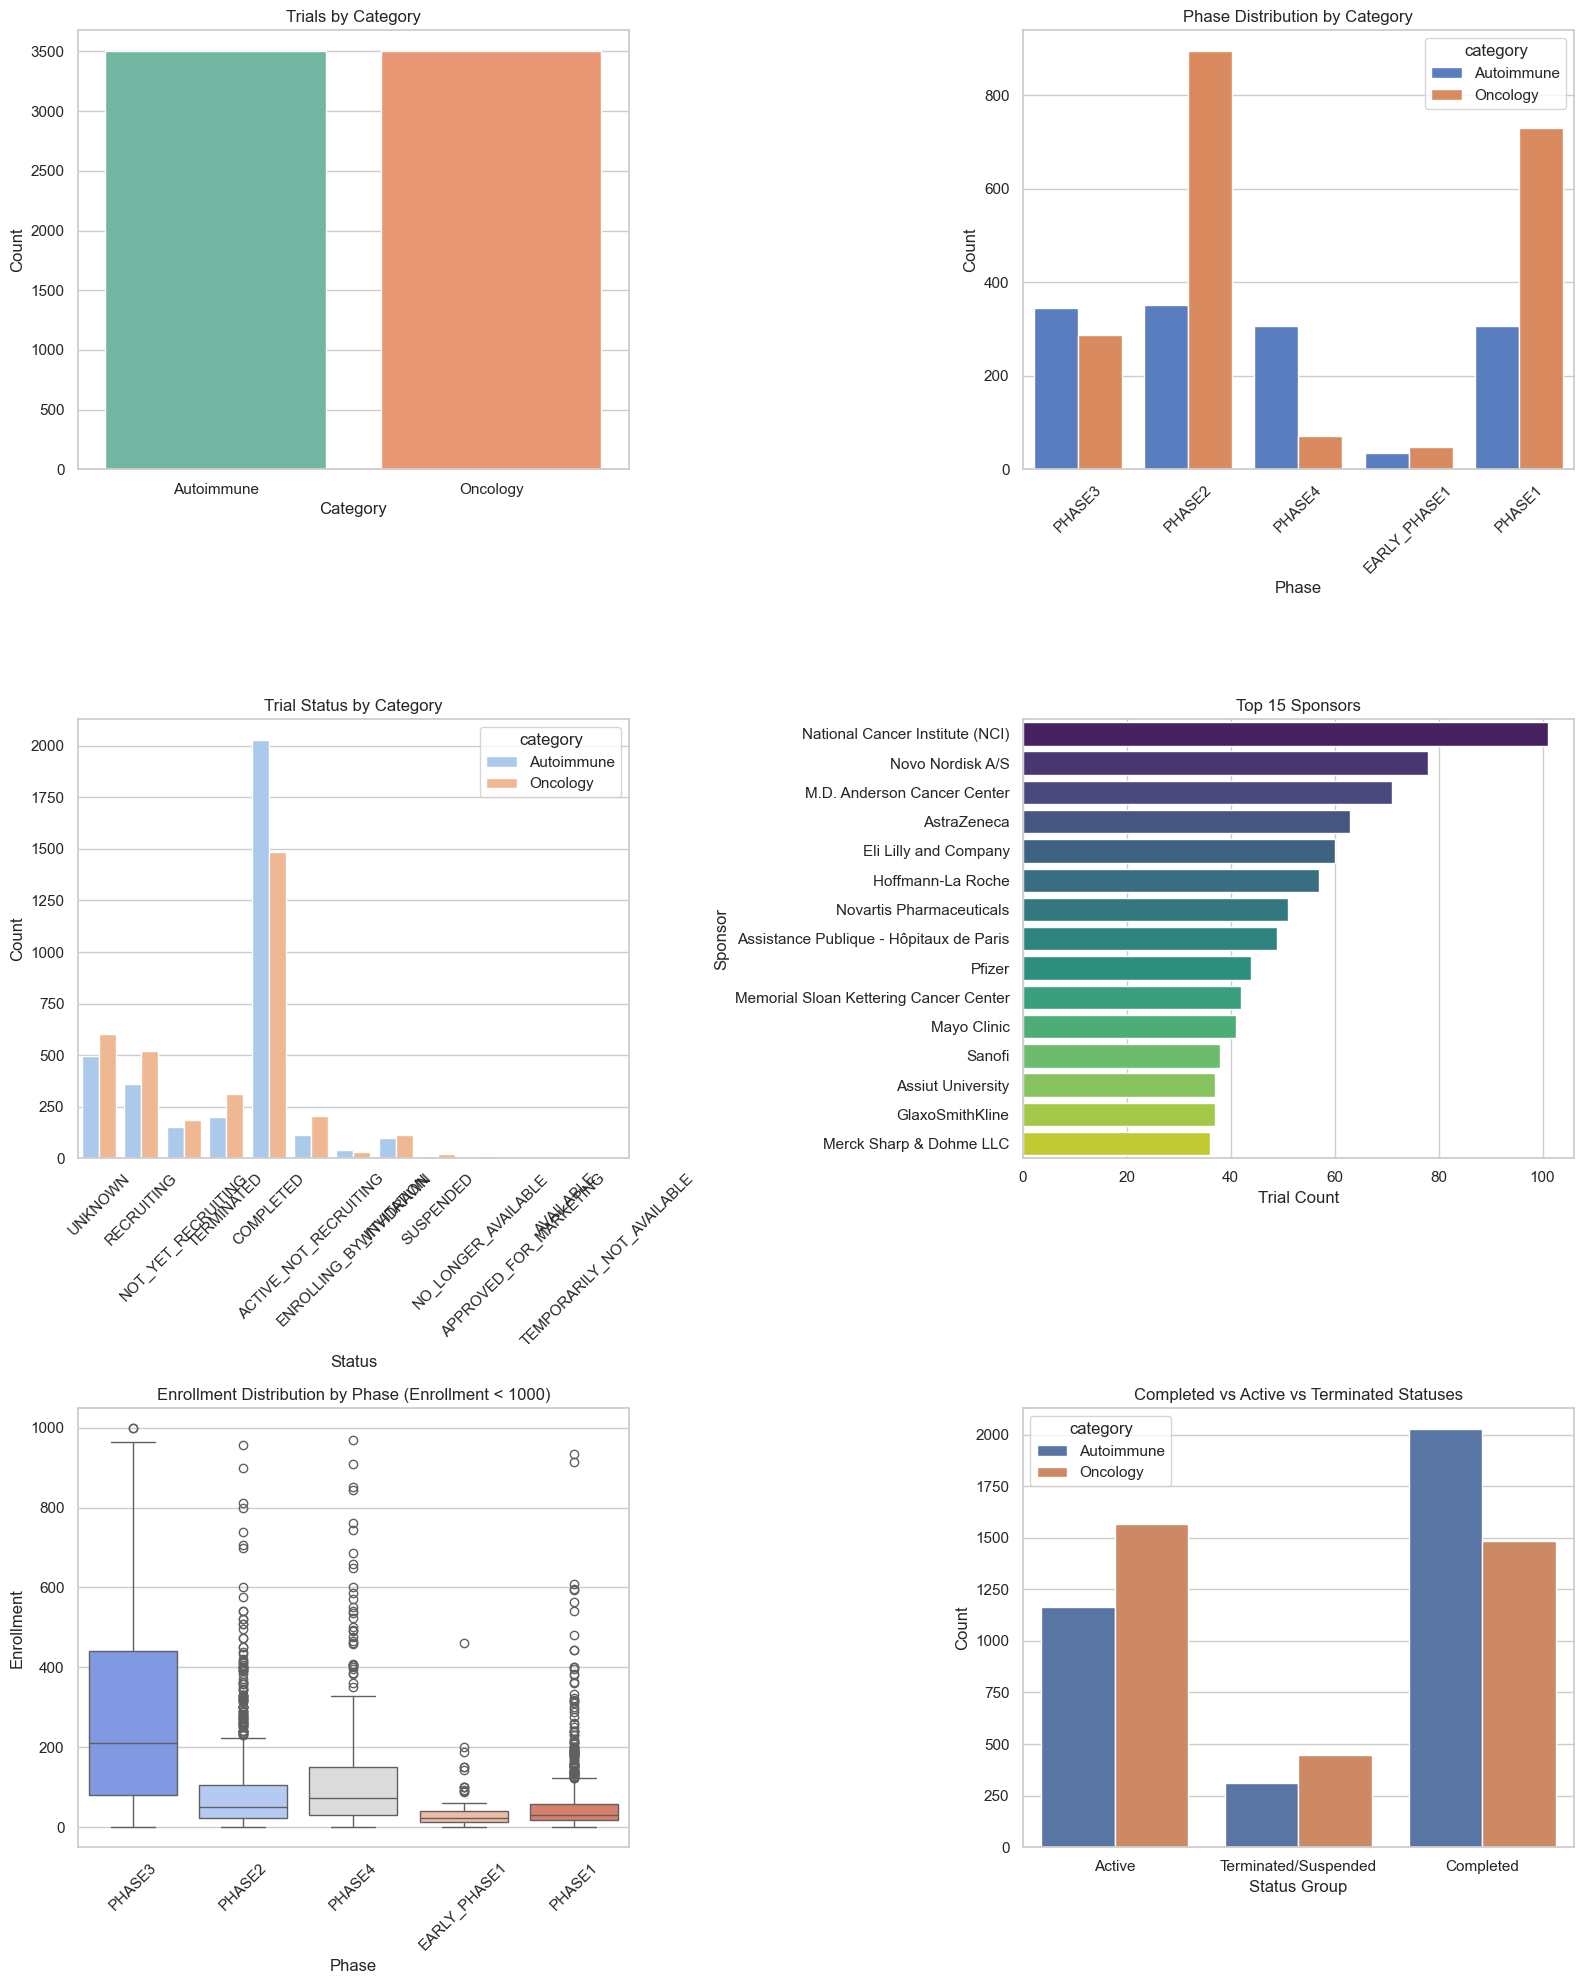

In [44]:
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# 1. Trials by category
sns.countplot(data=df, x='category', ax=axes[0,0], hue='category', legend=False, palette='Set2')
axes[0,0].set_title('Trials by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Count')

# 2. Phase by category
sns.countplot(data=df, x='phase', hue='category', ax=axes[0,1], palette='muted')
axes[0,1].set_title('Phase Distribution by Category')
axes[0,1].set_xlabel('Phase')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Status by category
sns.countplot(data=df, x='status', hue='category', ax=axes[1,0], palette='pastel')
axes[1,0].set_title('Trial Status by Category')
axes[1,0].set_xlabel('Status')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Top 15 sponsors
top_sponsors = df['sponsor'].value_counts().head(15).reset_index()
sns.barplot(data=top_sponsors, y='sponsor', x='count', ax=axes[1,1], hue='sponsor', legend=False, palette='viridis')
axes[1,1].set_title('Top 15 Sponsors')
axes[1,1].set_xlabel('Trial Count')
axes[1,1].set_ylabel('Sponsor')

# 5. Enrollment by phase
df_temp = df.copy()
df_temp['enrollment'] = pd.to_numeric(df_temp['enrollment'], errors='coerce')
df_temp = df_temp[df_temp['enrollment'] < 1000]  # Filter extreme outliers for plotting
sns.boxplot(data=df_temp, x='phase', y='enrollment', ax=axes[2,0], hue='phase', palette='coolwarm', legend=False)
axes[2,0].set_title('Enrollment Distribution by Phase (Enrollment < 1000)')
axes[2,0].set_xlabel('Phase')
axes[2,0].set_ylabel('Enrollment')
axes[2,0].tick_params(axis='x', rotation=45)

# 6. Completed vs active vs terminated
df_status = df.copy()
df_status['status_class'] = 'Active'
df_status.loc[df_status['status'].fillna('').str.lower().str.contains('completed'), 'status_class'] = 'Completed'
df_status.loc[df_status['status'].fillna('').str.lower().str.contains('terminated|withdrawn|suspended'), 'status_class'] = 'Terminated/Suspended'
sns.countplot(data=df_status, x='status_class', hue='category', ax=axes[2,1], palette='deep')
axes[2,1].set_title('Completed vs Active vs Terminated Statuses')
axes[2,1].set_xlabel('Status Group')
axes[2,1].set_ylabel('Count')

plt.tight_layout()
plt.show()



# Why This Dynamic Analysis Layer Matters

The previous scoring layer gives a normalized quantitative comparison.  
The dynamic AI layer adds **explainability**.

Instead of relying only on hardcoded rules, MindReader can ask structured clinical questions for every trial:

- What exactly is being tested?
- Are the endpoints meaningful?
- Can efficacy be interpreted from available results?
- What safety and tolerability evidence exists?
- Is the therapy easy or difficult for patients?
- Is the study design strong or weak?
- What evidence is missing?
- What should users **not** conclude?
- What would change the interpretation?

This makes the system more flexible than a static scoring table while still keeping the AI **grounded in source data**.

---

# MindReader Differentiation

MindReader should not just summarize clinical trials. It should create:

1. **Trial Intelligence Cards**
2. **Dynamic Evidence Gap Reports**
3. **Patient Adoption Burden Analysis**
4. **Endpoint Meaningfulness Review**
5. **Red-Team Risk Review**
6. **Cross-Trial Comparative Interpretation**
7. **Data Confidence-Aware Summaries**
8. **AI-Discovered Dimension Extensions**

> The pipeline graph/tree comes later as the visual layer.  
> For now, the focus is **dynamic trial analysis**.


# Final Approval Summary

This notebook now demonstrates a clinically more defensible MindReader trial-analysis method.

It does not predict clinical success.

It compares selected clinical trials using:
- Deep registry parsing
- Results-section availability
- Adverse-event evidence availability
- Endpoint meaningfulness
- Study design quality
- Safety/tolerability interpretability
- Patient adoption burden
- Benchmark-cohort normalization
- Dynamic weighted scoring
- Data confidence scoring
- Rank-stability analysis
- Missing evidence matrix
- Evidence waterfall explanations
- Estimand-style trial question checks
- Source-grounded AI Trial Intelligence Cards
- Strict AI overclaim audit

This supports the product direction:

MindReader should become an explainable clinical-trial intelligence layer that helps users understand what a trial actually shows, what it does not show, what evidence is missing, and how studies compare under different stakeholder priorities.


In [45]:
import os

os.makedirs("approval_outputs", exist_ok=True)

scored_df.to_csv("approval_outputs/final_scored_trials_with_confidence.csv", index=False)
rank_stability_df.to_csv("approval_outputs/rank_stability_analysis.csv", index=False)
rank_records_df.to_csv("approval_outputs/rank_stability_simulation_records.csv", index=False)
missing_matrix_df.to_csv("approval_outputs/missing_evidence_matrix.csv", index=False)
endpoint_meaningfulness_df.to_csv("approval_outputs/endpoint_meaningfulness_table.csv", index=False)

with open("approval_outputs/final_approval_summary.md", "w", encoding="utf-8") as f:
    f.write("# MindReader Final Approval Trial Analysis Summary\n\n")
    f.write("## Selected Trial Scores\n\n")
    f.write(scored_df[[
        "nct_id",
        "title",
        "sponsor",
        "balanced_view_score",
        "investor_view_score",
        "patient_view_score",
        "clinical_research_view_score",
        "regulatory_view_score",
        "data_confidence_score"
    ]].to_markdown(index=False))
    f.write("\n\n## Rank Stability\n\n")
    f.write(rank_stability_df.to_markdown(index=False))
    f.write("\n\n## Missing Evidence Matrix\n\n")
    f.write(missing_matrix_df.to_markdown(index=False))
    f.write("\n\n## Endpoint Meaningfulness\n\n")
    f.write(endpoint_meaningfulness_df.to_markdown(index=False))

print("Final approval outputs exported.")


Final approval outputs exported.
